# 🌱 AgroShield — Notebook VS Code + CPU

**Projet Learning by Doing — Détection de maladies végétales par IA**

---

## Structure du projet sur votre PC

```
C:\Users\pc\Desktop\AgroShield\          ← dossier racine du projet
├── AgroShield_VSCode_CPU.ipynb          ← CE notebook
├── server.py                            ← serveur Flask (généré à l'étape 12)
├── index.html                           ← application web
├── data/
│   ├── DATA.zip                         ← votre dataset original
│   ├── dataset_raw/PlantVillage/        ← extrait automatiquement
│   └── dataset_balanced/               ← créé à l'étape 2
└── models/
    ├── efficientnet_b0.pth              ← poids entraînés
    ├── efficientnet_b0_rpi.pt           ← TorchScript pour Raspberry Pi
    ├── efficientnet_b0_meta.json        ← métadonnées
    ├── resnet50.pth
    ├── resnet50_rpi.pt
    └── resnet50_meta.json
```

## Plan complet

| # | Étape | Description |
|---|---|---|
| 0 | Installation + Vérification | Installer toutes les bibliothèques, vérifier CPU |
| 1 | Extraction DATA.zip | Extraire et explorer le dataset local |
| 2 | Équilibrage Albumentations | Corriger le déséquilibre des classes |
| 3 | Split 70/15/15 | Diviser train / validation / test |
| 4 | DataLoader + WeightedRandomSampler | Chargement intelligent |
| 5 | Modèles CNN | EfficientNet-B0 et ResNet-50 |
| 6 | Entraînement CPU | Boucle optimisée pour CPU |
| 7 | Courbes d'apprentissage | Visualisation loss / accuracy |
| 8 | Évaluation test set | Accuracy, rapport, matrice de confusion |
| 9 | Export Raspberry Pi | TorchScript .pt + JSON |
| 10 | Test du modèle | Tester sur une image depuis le PC |
| 11 | Génération server.py | Serveur Flask local |
| 12 | Génération index.html | Application web complète |

---

> ⚠️ **CPU seulement** — L'entraînement sera plus lent qu'avec GPU.
> Comptez environ **3 à 5 minutes par epoch** selon votre PC.
> Vous pouvez réduire `NUM_EPOCHS = 5` pour un test rapide.

## Étape 0 — Installation et vérification

In [1]:
# ══════════════════════════════════════════════════════════
# ÉTAPE 0A — Installer toutes les bibliothèques
# Lancez cette cellule UNE SEULE FOIS, puis redémarrez le kernel
# ══════════════════════════════════════════════════════════
import subprocess, sys

packages = [
    'torch', 'torchvision',
    'albumentations',
    'flask', 'flask-cors',
    'scikit-learn',
    'matplotlib', 'seaborn',
    'pillow', 'opencv-python',
    'tqdm',
]

for pkg in packages:
    print(f'Installation : {pkg}...')
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], check=True)

print('\n✅ Toutes les bibliothèques sont installées')
print('→ Redémarrez le kernel VS Code : Ctrl+Shift+P → Restart Kernel')

Installation : torch...
Installation : torchvision...
Installation : albumentations...
Installation : flask...
Installation : flask-cors...
Installation : scikit-learn...
Installation : matplotlib...
Installation : seaborn...
Installation : pillow...
Installation : opencv-python...
Installation : tqdm...

✅ Toutes les bibliothèques sont installées
→ Redémarrez le kernel VS Code : Ctrl+Shift+P → Restart Kernel


In [1]:
# ══════════════════════════════════════════════════════════
# ÉTAPE 0B — Vérification de l'environnement
# ══════════════════════════════════════════════════════════
import torch, torchvision, sklearn, cv2, albumentations
import os, sys
from pathlib import Path

# ── Device : CPU forcé ───────────────────────────────────
device = torch.device('cpu')
print(f'Device       : {device}')
print(f'PyTorch      : {torch.__version__}')
print(f'Torchvision  : {torchvision.__version__}')
print(f'Python       : {sys.version.split()[0]}')
print(f'OpenCV       : {cv2.__version__}')
print(f'Albumentations: {albumentations.__version__}')
print(f'sklearn      : {sklearn.__version__}')

# ── Dossiers du projet ───────────────────────────────────
# Adaptez ce chemin si votre projet est ailleurs
PROJECT_DIR = Path(r'C:\Users\pc\Desktop\AgroShield')
DATA_DIR_RAW      = PROJECT_DIR / 'data' / 'dataset_raw'
DATA_DIR_BALANCED = PROJECT_DIR / 'data' / 'dataset_balanced'
MODELS_DIR        = PROJECT_DIR / 'models'

for d in [DATA_DIR_RAW, DATA_DIR_BALANCED, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f'\nProjet       : {PROJECT_DIR}')
print(f'Data raw     : {DATA_DIR_RAW}')
print(f'Data balanced: {DATA_DIR_BALANCED}')
print(f'Models       : {MODELS_DIR}')
print('\n✅ Environnement prêt')

Device       : cpu
PyTorch      : 2.11.0+cpu
Torchvision  : 0.26.0+cpu
Python       : 3.13.1
OpenCV       : 4.13.0
Albumentations: 2.0.8
sklearn      : 1.8.0

Projet       : C:\Users\pc\Desktop\AgroShield
Data raw     : C:\Users\pc\Desktop\AgroShield\data\dataset_raw
Data balanced: C:\Users\pc\Desktop\AgroShield\data\dataset_balanced
Models       : C:\Users\pc\Desktop\AgroShield\models

✅ Environnement prêt


## Étape 1 — Extraction de DATA.zip

In [7]:
from pathlib import Path

# =====================================================
# CHEMIN DU DATASET
# =====================================================

PLANT_DIR = Path(r'C:\Users\pc\Desktop\PlantVillage')

# Vérification
if not PLANT_DIR.exists():
    raise FileNotFoundError(f'Dataset introuvable : {PLANT_DIR}')

print(f'Dataset trouvé : {PLANT_DIR}\n')

# =====================================================
# AFFICHER LES CLASSES
# =====================================================

print(f'{"Classe":<45} {"Images":>8}')
print('-' * 58)

total = 0

for class_dir in sorted(PLANT_DIR.iterdir()):

    # ignorer fichiers
    if not class_dir.is_dir():
        continue

    # compter rapidement les images
    n = sum(
        1 for f in class_dir.iterdir()
        if f.suffix.lower() in ['.jpg', '.jpeg', '.png']
    )

    total += n

    print(f'{class_dir.name:<45} {n:>8}')

print('-' * 58)
print(f'{"TOTAL":<45} {total:>8}')

Dataset trouvé : C:\Users\pc\Desktop\PlantVillage

Classe                                          Images
----------------------------------------------------------
Pepper__bell___Bacterial_spot                      997
Pepper__bell___healthy                            1478
Potato___Early_blight                             1000
Potato___healthy                                   152
Potato___Late_blight                              1000
Tomato__Target_Spot                               1404
Tomato__Tomato_mosaic_virus                        373
Tomato__Tomato_YellowLeaf__Curl_Virus             3208
Tomato_Bacterial_spot                             2127
Tomato_Early_blight                               1000
Tomato_healthy                                    1591
Tomato_Late_blight                                1909
Tomato_Leaf_Mold                                   952
Tomato_Septoria_leaf_spot                         1771
Tomato_Spider_mites_Two_spotted_spider_mite       1676
----------

## Étape 2 — Équilibrage avec Albumentations

In [13]:
# ══════════════════════════════════════════════════════════
# ÉTAPE 2 — Équilibrage professionnel (1000 images/classe)
# ══════════════════════════════════════════════════════════

from pathlib import Path
import random
import shutil
import cv2

from PIL import Image
import albumentations as A
from tqdm import tqdm

# =====================================================
# CHEMINS
# =====================================================

PLANT_DIR = Path(r'C:\Users\pc\Desktop\PlantVillage')

DATA_DIR_BALANCED = Path(r'C:\Users\pc\Desktop\PlantVillage_balanced')

DATA_DIR_BALANCED.mkdir(parents=True, exist_ok=True)

# =====================================================
# VÉRIFICATION DATASET
# =====================================================

if not PLANT_DIR.exists():
    raise FileNotFoundError(f'Dataset introuvable : {PLANT_DIR}')

print(f'Dataset trouvé : {PLANT_DIR}')

# =====================================================
# PIPELINE D'AUGMENTATION
# =====================================================

aug_pipeline = A.Compose([

    A.HorizontalFlip(p=0.5),

    A.VerticalFlip(p=0.3),

    A.RandomRotate90(p=0.5),

    A.ShiftScaleRotate(
        shift_limit=0.1,
        scale_limit=0.2,
        rotate_limit=30,
        p=0.6
    ),

    A.OneOf([
        A.GaussNoise(p=1),
        A.ISONoise(p=1),
    ], p=0.4),

    A.OneOf([
        A.GaussianBlur(blur_limit=5, p=1),
        A.MedianBlur(blur_limit=5, p=1),
    ], p=0.3),

    A.OneOf([

        A.RandomBrightnessContrast(
            brightness_limit=0.3,
            contrast_limit=0.3,
            p=1
        ),

        A.HueSaturationValue(
            hue_shift_limit=20,
            sat_shift_limit=40,
            p=1
        ),

        A.CLAHE(
            clip_limit=4,
            p=1
        ),

    ], p=0.5),

    A.CoarseDropout(
        max_holes=8,
        max_height=16,
        max_width=16,
        p=0.3
    ),

    A.Resize(224, 224),

])

# =====================================================
# FONCTION D'AUGMENTATION
# =====================================================

def augment_image(src_path):

    img = cv2.imread(str(src_path))

    if img is None:
        raise ValueError(f'Impossible de lire : {src_path}')

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    aug_img = aug_pipeline(image=img)['image']

    return aug_img

# =====================================================
# PARAMÈTRES
# =====================================================

TARGET = 1000

# =====================================================
# DÉBUT ÉQUILIBRAGE
# =====================================================

print(f'\nÉquilibrage vers {TARGET} images/classe...\n')

print(f'{"Classe":<45} {"Avant":>8} {"Après":>8}')

print('-' * 70)

# =====================================================
# TRAITEMENT DES CLASSES
# =====================================================

for class_dir in tqdm(sorted(PLANT_DIR.iterdir()), desc='Classes'):

    # ignorer fichiers
    if not class_dir.is_dir():
        continue

    # récupérer images
    imgs = [

        p for p in class_dir.iterdir()

        if p.suffix.lower() in ['.jpg', '.jpeg', '.png']

    ]

    n = len(imgs)

    if n == 0:
        continue

    # =================================================
    # DOSSIER SORTIE
    # =================================================

    out_dir = DATA_DIR_BALANCED / class_dir.name

    # supprimer ancien dossier
    if out_dir.exists():
        shutil.rmtree(out_dir)

    # recréer dossier vide
    out_dir.mkdir(parents=True, exist_ok=True)

    # =================================================
    # CAS 1 : trop d'images → under-sampling
    # =================================================

    if n >= TARGET:

        selected = random.sample(imgs, TARGET)

        for i, src in enumerate(selected):

            dst = out_dir / f'img_{i:05d}.jpg'

            try:

                Image.open(src)\
                    .convert('RGB')\
                    .resize((224, 224))\
                    .save(dst, quality=92)

            except Exception:

                pass

    # =================================================
    # CAS 2 : pas assez → augmentation
    # =================================================

    else:

        # copier originales
        for i, src in enumerate(imgs):

            dst = out_dir / f'orig_{i:05d}.jpg'

            try:

                Image.open(src)\
                    .convert('RGB')\
                    .resize((224, 224))\
                    .save(dst, quality=92)

            except Exception:

                pass

        needed = TARGET - n

        generated = 0

        attempts = 0

        while generated < needed:

            attempts += 1

            # sécurité anti boucle infinie
            if attempts > needed * 20:

                print(f'⚠️ Trop d’erreurs dans {class_dir.name}')

                break

            src = random.choice(imgs)

            dst = out_dir / f'aug_{generated:05d}.jpg'

            try:

                aug_img = augment_image(src)

                Image.fromarray(aug_img).save(
                    dst,
                    quality=92
                )

                generated += 1

            except Exception:

                pass

    # =================================================
    # VÉRIFICATION
    # =================================================

    actual = len(list(out_dir.glob('*.jpg')))

    print(f'{class_dir.name:<45} {n:>8} {actual:>8}')

# =====================================================
# TOTAL FINAL
# =====================================================

print('\n' + '-' * 70)

total = len(list(DATA_DIR_BALANCED.glob('*/*.jpg')))

print(f'✅ Dataset équilibré créé : {total} images')

print(f'📁 Emplacement : {DATA_DIR_BALANCED}')

# =====================================================
# VÉRIFICATION FINALE
# =====================================================

print('\nVérification finale :\n')

for class_dir in sorted(DATA_DIR_BALANCED.iterdir()):

    if not class_dir.is_dir():
        continue

    n = len(list(class_dir.glob('*.jpg')))

    print(f'{class_dir.name:<45} {n}')

C:\Users\pc\AppData\Local\Temp\ipykernel_5948\796444667.py:83: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(


Dataset trouvé : C:\Users\pc\Desktop\PlantVillage

Équilibrage vers 1000 images/classe...

Classe                                           Avant    Après
----------------------------------------------------------------------


Classes:   0%|          | 0/15 [00:00<?, ?it/s]

Classes:   7%|▋         | 1/15 [00:04<00:58,  4.21s/it]

Pepper__bell___Bacterial_spot                      997     1000


...

Classes:  93%|█████████▎| 14/15 [01:08<00:04,  4.28s/it]

Tomato_Septoria_leaf_spot                         1771     1000


Classes: 100%|██████████| 15/15 [01:12<00:00,  4.83s/it]

Tomato_Spider_mites_Two_spotted_spider_mite       1676     1000

----------------------------------------------------------------------
✅ Dataset équilibré créé : 15000 images
📁 Emplacement : C:\Users\pc\Desktop\PlantVillage_balanced

Vérification finale :

Pepper__bell___Bacterial_spot                 1000
Pepper__bell___healthy                        1000
Potato___Early_blight                         1000
Potato___healthy                              1000
Potato___Late_blight                          1000
Tomato__Target_Spot                           1000
Tomato__Tomato_mosaic_virus                   1000
Tomato__Tomato_YellowLeaf__Curl_Virus         1000
Tomato_Bacterial_spot                         1000
Tomato_Early_blight                           1000
Tomato_healthy                                1000
Tomato_Late_blight                            1000
Tomato_Leaf_Mold                              1000


Tomato_Septoria_leaf_spot                     1000
Tomato_Spider_mites_Two_spotted_spider_mite   1000


## Étape 3 — Split 70 / 15 / 15

In [14]:
# ══════════════════════════════════════════════════════════
# ÉTAPE 3 — Split train / validation / test
# ══════════════════════════════════════════════════════════
import json
from collections import Counter

classes      = sorted([d.name for d in DATA_DIR_BALANCED.iterdir() if d.is_dir()])
class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

print(f'Nombre de classes : {len(classes)}')

all_samples = []
for cls in classes:
    for p in (DATA_DIR_BALANCED / cls).glob('*.jpg'):
        all_samples.append((str(p), class_to_idx[cls]))

random.seed(42)
random.shuffle(all_samples)

n       = len(all_samples)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)

train_samples = all_samples[:n_train]
val_samples   = all_samples[n_train : n_train + n_val]
test_samples  = all_samples[n_train + n_val:]

print(f'Train : {len(train_samples):>6} images  ({len(train_samples)/n*100:.0f}%)')
print(f'Val   : {len(val_samples):>6} images  ({len(val_samples)/n*100:.0f}%)')
print(f'Test  : {len(test_samples):>6} images  ({len(test_samples)/n*100:.0f}%)')
print(f'Total : {n:>6} images')

Nombre de classes : 15
Train :  10500 images  (70%)
Val   :   2250 images  (15%)
Test  :   2250 images  (15%)
Total :  15000 images


## Étape 4 — DataLoader + WeightedRandomSampler

In [15]:
# ══════════════════════════════════════════════════════════
# ÉTAPE 4 — Dataset, transforms, DataLoader
# NOTE CPU : num_workers=0 sur Windows pour éviter les erreurs
# ══════════════════════════════════════════════════════════
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from PIL import Image, UnidentifiedImageError
import numpy as np

data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]),
}

class PlantDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples   = samples
        self.transform = transform
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        try:
            img = Image.open(path).convert('RGB')
        except (IOError, UnidentifiedImageError):
            return self.__getitem__((idx + 1) % len(self.samples))
        if self.transform:
            img = self.transform(img)
        return img, label

train_dataset = PlantDataset(train_samples, transform=data_transforms['train'])
val_dataset   = PlantDataset(val_samples,   transform=data_transforms['val'])
test_dataset  = PlantDataset(test_samples,  transform=data_transforms['val'])

# WeightedRandomSampler
labels          = [lbl for _, lbl in train_samples]
class_counts    = Counter(labels)
weights_per_cls = {cls: 1.0 / count for cls, count in class_counts.items()}
sample_weights  = torch.tensor([weights_per_cls[lbl] for _, lbl in train_samples])
sampler         = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

# Class weights pour CrossEntropyLoss
cw_array  = np.array([1.0 / class_counts[i] for i in range(len(classes))])
cw_array  = cw_array / cw_array.sum() * len(classes)
cw_tensor = torch.tensor(cw_array, dtype=torch.float)

# num_workers=0 sur Windows pour éviter les erreurs de multiprocessing
train_loader = DataLoader(train_dataset, batch_size=16, sampler=sampler,    num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False,      num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False,      num_workers=0)

print(f'Train  : {len(train_loader)} batches  ({len(train_dataset)} images)')
print(f'Val    : {len(val_loader)} batches  ({len(val_dataset)} images)')
print(f'Test   : {len(test_loader)} batches  ({len(test_dataset)} images)')
print(f'Batch  : 16  (réduit pour CPU)')
print(f'✅ DataLoaders prêts')

Train  : 657 batches  (10500 images)
Val    : 141 batches  (2250 images)
Test   : 141 batches  (2250 images)
Batch  : 16  (réduit pour CPU)
✅ DataLoaders prêts


## Étape 5 — Modèles CNN

In [16]:
# ══════════════════════════════════════════════════════════
# ÉTAPE 5 — EfficientNet-B0 et ResNet-50
# ══════════════════════════════════════════════════════════
from torchvision import models

num_classes = len(classes)

def build_efficientnet(n):
    m = models.efficientnet_b0(weights='IMAGENET1K_V1')
    m.classifier[1] = nn.Linear(m.classifier[1].in_features, n)
    return m  # CPU : pas de .to(device) nécessaire

def build_resnet50(n):
    m = models.resnet50(weights='IMAGENET1K_V1')
    m.fc = nn.Linear(m.fc.in_features, n)
    return m

eff_model = build_efficientnet(num_classes)
res_model = build_resnet50(num_classes)

eff_params = sum(p.numel() for p in eff_model.parameters()) / 1e6
res_params = sum(p.numel() for p in res_model.parameters()) / 1e6

print(f'✅ EfficientNet-B0 : {eff_params:.1f}M paramètres')
print(f'✅ ResNet-50       : {res_params:.1f}M paramètres')
print(f'   Classes         : {num_classes}')
print(f'   Device          : CPU')

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\pc/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:17<00:00, 5.75MB/s]


✅ EfficientNet-B0 : 4.0M paramètres
✅ ResNet-50       : 23.5M paramètres
   Classes         : 15
   Device          : CPU


## Étape 6 — Entraînement

> ⏱ **Estimation du temps sur CPU :**  
> - EfficientNet-B0 : ~3-4 min/epoch  
> - ResNet-50 : ~5-6 min/epoch  
> - 20 epochs total : ~2h
>
> Pour tester rapidement : changez `NUM_EPOCHS = 3`

In [17]:
# ══════════════════════════════════════════════════════════
# ÉTAPE 6 — Entraînement optimisé CPU
# ══════════════════════════════════════════════════════════
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm import tqdm
import time

# ── Paramètre clé : réduire pour aller plus vite ─────────
NUM_EPOCHS = 20   # Mettre 3 pour un test rapide, 20 pour un vrai entraînement

def train_model(model, model_name, num_epochs=NUM_EPOCHS):
    criterion = nn.CrossEntropyLoss(weight=cw_tensor)
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs)

    best_val_acc = 0.0
    best_weights = None
    history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': []}
    best_path = MODELS_DIR / f'{model_name.lower().replace("-","_")}_best.pth'

    for epoch in range(1, num_epochs + 1):
        t_start = time.time()

        # ── Train ──────────────────────────────────────────
        model.train()
        run_loss, correct, total = 0.0, 0, 0
        pbar = tqdm(train_loader, desc=f'[{model_name}] Epoch {epoch}/{num_epochs} Train',
                    leave=False, ncols=90)
        for imgs, lbls in pbar:
            optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, lbls)
            loss.backward()
            optimizer.step()
            run_loss += loss.item() * imgs.size(0)
            correct  += (out.argmax(1) == lbls).sum().item()
            total    += imgs.size(0)
            pbar.set_postfix({'loss': f'{loss.item():.3f}'})
        t_loss = run_loss / total
        t_acc  = correct  / total

        # ── Validation ─────────────────────────────────────
        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, lbls in tqdm(val_loader, desc='Val', leave=False, ncols=70):
                out       = model(imgs)
                v_loss   += criterion(out, lbls).item() * imgs.size(0)
                v_correct += (out.argmax(1) == lbls).sum().item()
                v_total  += imgs.size(0)
        v_loss = v_loss / v_total
        v_acc  = v_correct / v_total

        scheduler.step()
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)
        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)

        elapsed = time.time() - t_start
        is_best = v_acc > best_val_acc

        if is_best:
            best_val_acc = v_acc
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}
            # Sauvegarde intermédiaire — protège contre crash ou coupure
            torch.save(best_weights, best_path)

        marker = ' ✅' if is_best else ''
        print(f'[{model_name}] Epoch {epoch:>2}/{num_epochs} | '
              f'Train {t_acc:.3f}/{t_loss:.3f} | '
              f'Val {v_acc:.3f}/{v_loss:.3f} | '
              f'{elapsed:.0f}s{marker}')

    model.load_state_dict(best_weights)
    print(f'\n🏆 {model_name} — Meilleure Val Acc : {best_val_acc:.4f}')
    print(f'   Sauvegarde intermédiaire : {best_path}\n')
    return model, history

# ── Lancer les entraînements ─────────────────────────────
print('=' * 65)
print('ENTRAÎNEMENT EfficientNet-B0')
print('=' * 65)
eff_model, eff_history = train_model(eff_model, 'EfficientNet-B0')

print('=' * 65)
print('ENTRAÎNEMENT ResNet-50')
print('=' * 65)
res_model, res_history = train_model(res_model, 'ResNet-50')

ENTRAÎNEMENT EfficientNet-B0


[EfficientNet-B0] Epoch  1/20 | Train 0.754/0.764 | Val 0.897/0.316 | 1610s ✅


[EfficientNet-B0] Epoch  2/20 | Train 0.862/0.428 | Val 0.950/0.149 | 1526s ✅


[EfficientNet-B0] Epoch  3/20 | Train 0.879/0.370 | Val 0.952/0.141 | 1573s ✅


[EfficientNet-B0] Epoch  4/20 | Train 0.902/0.305 | Val 0.948/0.158 | 1547s


...

[ResNet-50] Epoch 16/20 | Train 0.941/0.186 | Val 0.979/0.068 | 3032s


[ResNet-50] Epoch 17/20 | Train 0.947/0.163 | Val 0.984/0.061 | 2963s ✅


[ResNet-50] Epoch 18/20 | Train 0.947/0.160 | Val 0.984/0.056 | 2929s


[ResNet-50] Epoch 19/20 | Train 0.955/0.139 | Val 0.986/0.055 | 3058s ✅


[ResNet-50] Epoch 20/20 | Train 0.957/0.134 | Val 0.985/0.056 | 3291s

🏆 ResNet-50 — Meilleure Val Acc : 0.9858
   Sauvegarde intermédiaire : C:\Users\pc\Desktop\AgroShield\models\resnet_50_best.pth



## Étape 7 — Courbes d'apprentissage

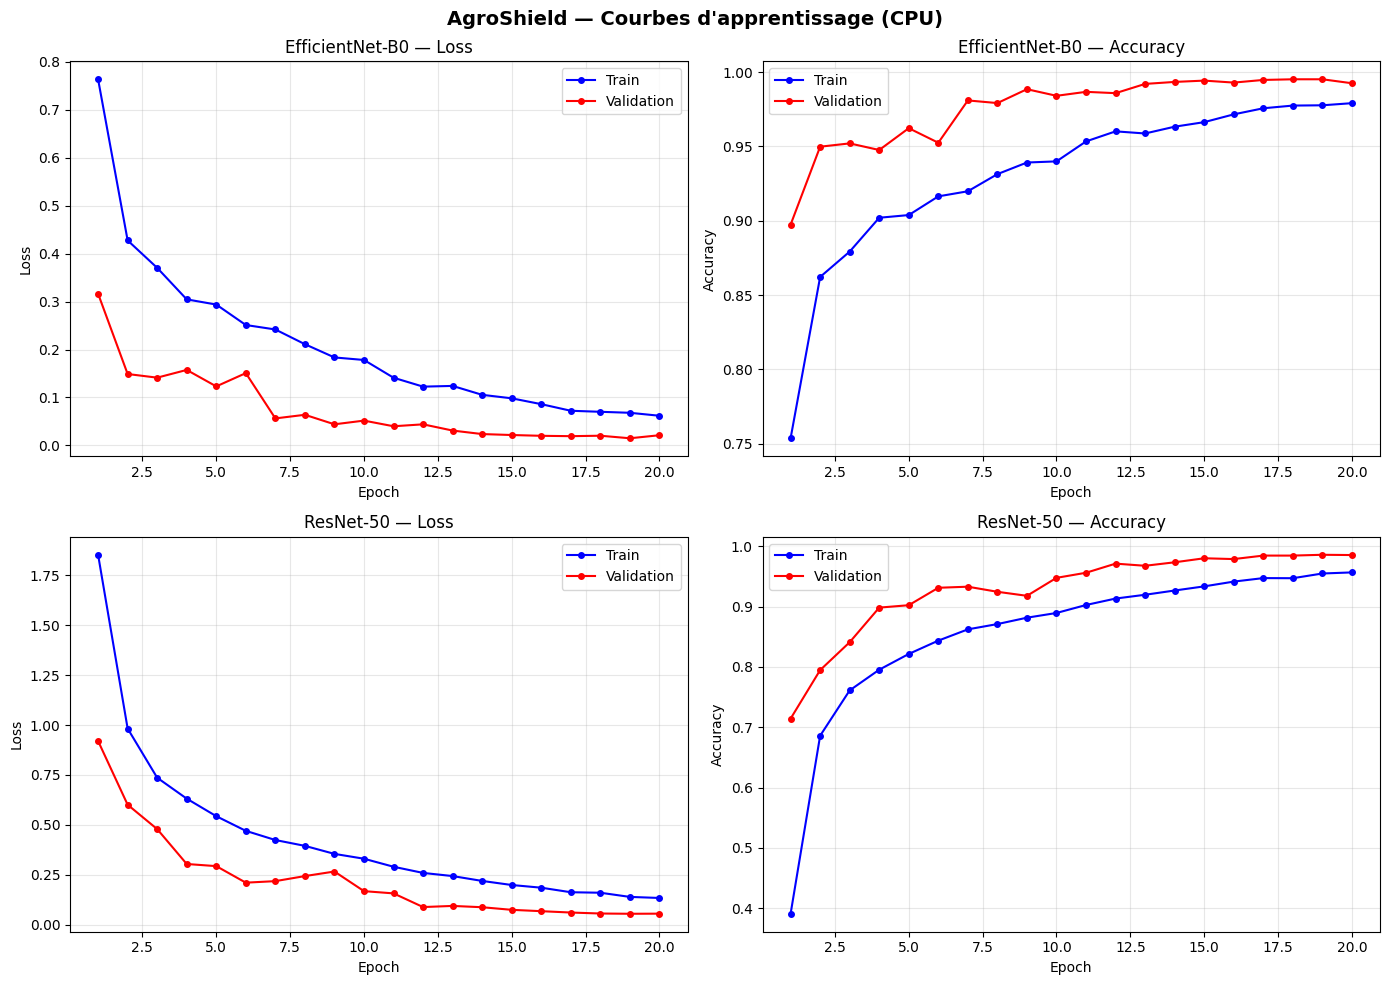

✅ Courbes sauvegardées : C:\Users\pc\Desktop\AgroShield\models\courbes_apprentissage.png


In [18]:
# ══════════════════════════════════════════════════════════
# ÉTAPE 7 — Visualisation des courbes
# ══════════════════════════════════════════════════════════
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('AgroShield — Courbes d\'apprentissage (CPU)', fontsize=14, fontweight='bold')

configs = [
    (eff_history, 'EfficientNet-B0', axes[0]),
    (res_history, 'ResNet-50',       axes[1]),
]

for hist, name, axrow in configs:
    epochs = range(1, len(hist['train_acc']) + 1)

    axrow[0].plot(epochs, hist['train_loss'], 'b-o', markersize=4, label='Train')
    axrow[0].plot(epochs, hist['val_loss'],   'r-o', markersize=4, label='Validation')
    axrow[0].set_title(f'{name} — Loss')
    axrow[0].set_xlabel('Epoch')
    axrow[0].set_ylabel('Loss')
    axrow[0].legend()
    axrow[0].grid(True, alpha=0.3)

    axrow[1].plot(epochs, hist['train_acc'], 'b-o', markersize=4, label='Train')
    axrow[1].plot(epochs, hist['val_acc'],   'r-o', markersize=4, label='Validation')
    axrow[1].set_title(f'{name} — Accuracy')
    axrow[1].set_xlabel('Epoch')
    axrow[1].set_ylabel('Accuracy')
    axrow[1].legend()
    axrow[1].grid(True, alpha=0.3)

plt.tight_layout()
save_path = MODELS_DIR / 'courbes_apprentissage.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Courbes sauvegardées : {save_path}')

## Étape 8 — Évaluation complète sur le test set

In [19]:
# ══════════════════════════════════════════════════════════
# ÉTAPE 8A — Rapport de classification
# ══════════════════════════════════════════════════════════
from sklearn.metrics import classification_report, accuracy_score

def evaluate_model(model, model_name):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, lbls in tqdm(test_loader, desc=f'Test {model_name}', ncols=70):
            preds = model(imgs).argmax(1).tolist()
            all_preds.extend(preds)
            all_labels.extend(lbls.tolist())

    acc = accuracy_score(all_labels, all_preds)
    print(f'\n{"="*60}')
    print(f'{model_name} — Test Accuracy : {acc*100:.2f}%')
    print(f'{"="*60}')
    print(classification_report(all_labels, all_preds, target_names=classes, digits=3))
    return all_labels, all_preds, acc

eff_labels, eff_preds, eff_acc = evaluate_model(eff_model, 'EfficientNet-B0')
res_labels, res_preds, res_acc = evaluate_model(res_model, 'ResNet-50')

print(f'\n📊 Résumé :')
print(f'   EfficientNet-B0 : {eff_acc*100:.2f}%')
print(f'   ResNet-50       : {res_acc*100:.2f}%')
print(f'   Meilleur        : {"EfficientNet-B0" if eff_acc >= res_acc else "ResNet-50"}')

Test EfficientNet-B0: 100%|█████████| 141/141 [01:50<00:00,  1.27it/s]



EfficientNet-B0 — Test Accuracy : 99.42%
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot      1.000     1.000     1.000       137
                     Pepper__bell___healthy      1.000     1.000     1.000       169
                      Potato___Early_blight      1.000     1.000     1.000       142
                       Potato___Late_blight      1.000     1.000     1.000       142
                           Potato___healthy      1.000     0.994     0.997       158
                      Tomato_Bacterial_spot      1.000     0.980     0.990       153
                        Tomato_Early_blight      0.986     0.993     0.989       142
                         Tomato_Late_blight      0.994     0.994     0.994       165
                           Tomato_Leaf_Mold      1.000     0.992     0.996       132
                  Tomato_Septoria_leaf_spot      0.994     1.000     0.997       165
Tomato_Spider_mites_Tw

Test ResNet-50: 100%|███████████████| 141/141 [03:18<00:00,  1.41s/it]


ResNet-50 — Test Accuracy : 98.62%
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot      1.000     0.993     0.996       137
                     Pepper__bell___healthy      0.988     0.994     0.991       169
                      Potato___Early_blight      0.993     1.000     0.996       142
                       Potato___Late_blight      0.979     1.000     0.990       142
                           Potato___healthy      1.000     0.994     0.997       158
                      Tomato_Bacterial_spot      0.981     0.987     0.984       153
                        Tomato_Early_blight      0.986     0.979     0.982       142
                         Tomato_Late_blight      0.994     0.945     0.969       165
                           Tomato_Leaf_Mold      0.992     1.000     0.996       132
                  Tomato_Septoria_leaf_spot      0.988     0.994     0.991       165
Tomato_Spider_mites_Two_spot

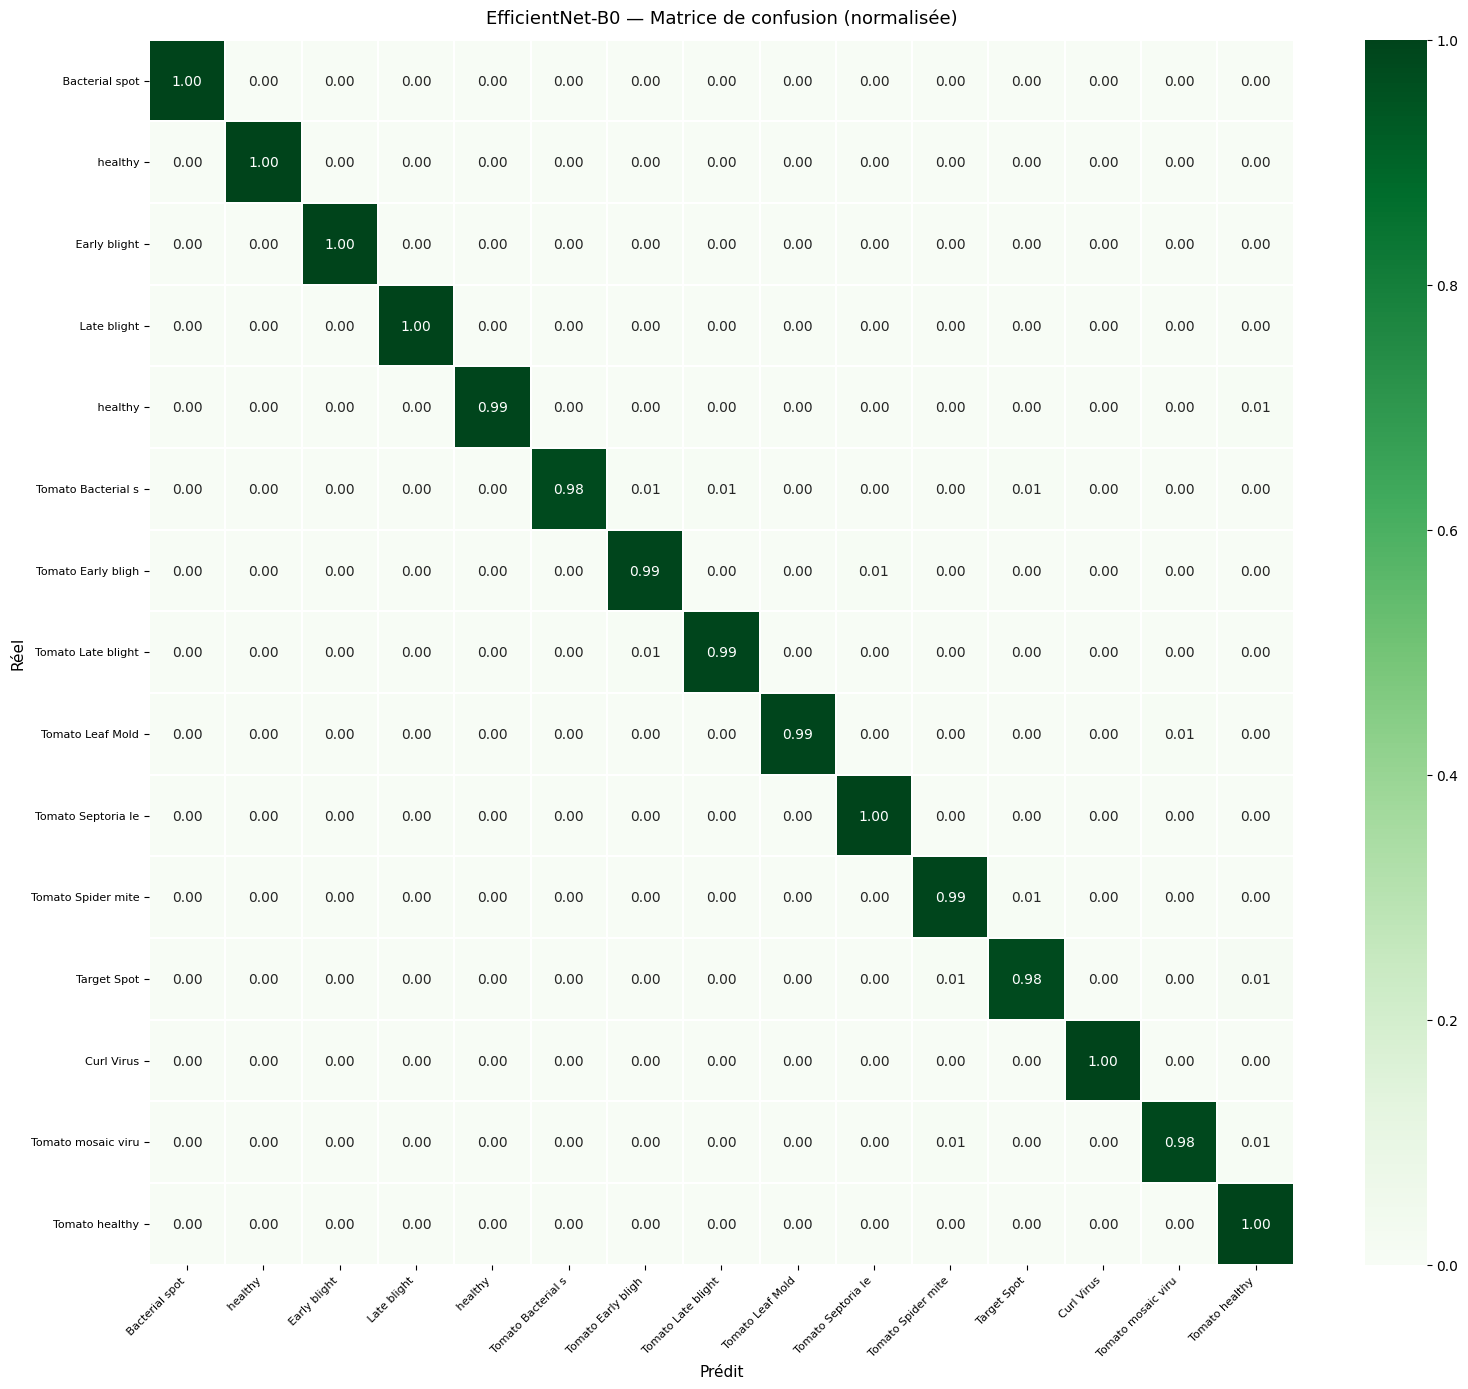

✅ Matrice sauvegardée : C:\Users\pc\Desktop\AgroShield\models\confusion_EfficientNet_B0.png


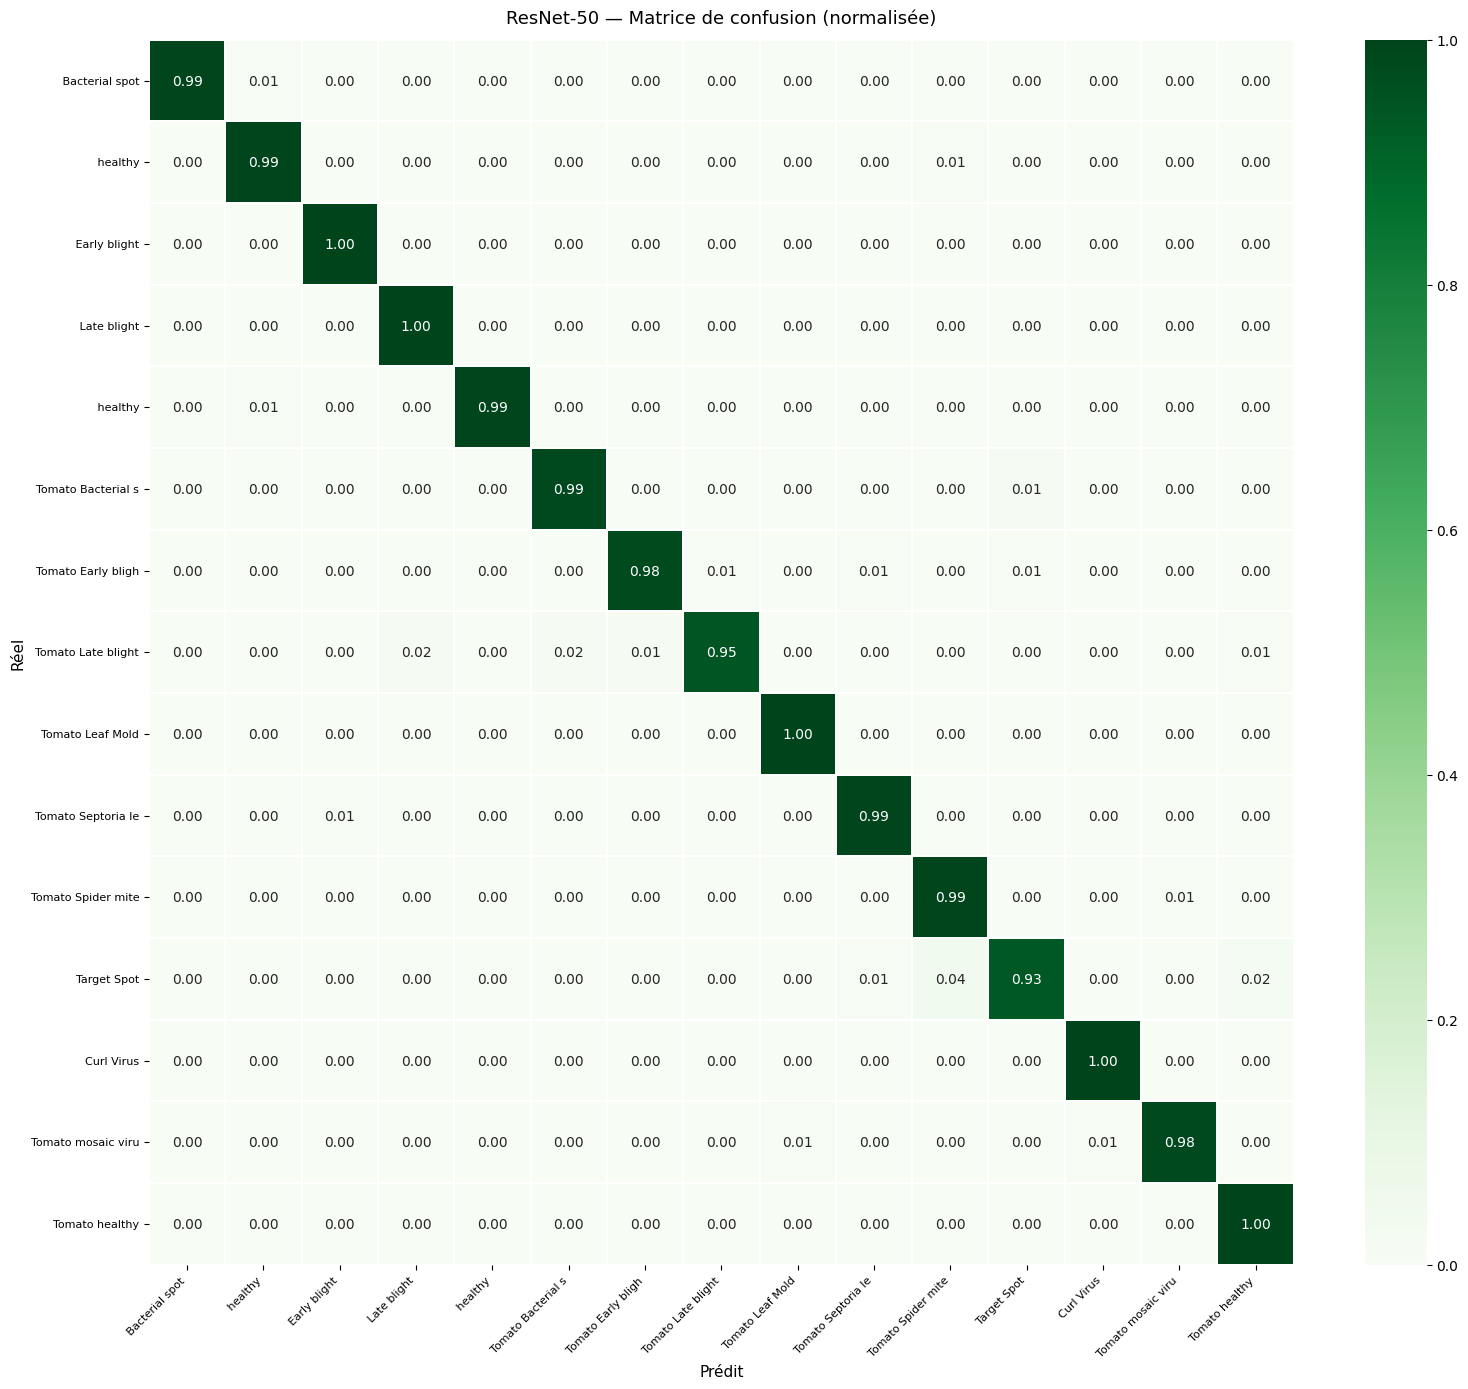

✅ Matrice sauvegardée : C:\Users\pc\Desktop\AgroShield\models\confusion_ResNet_50.png


In [20]:
# ══════════════════════════════════════════════════════════
# ÉTAPE 8B — Matrice de confusion
# ══════════════════════════════════════════════════════════
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion(labels, preds, model_name):
    cm      = confusion_matrix(labels, preds)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    short   = [c.split('__')[-1].replace('_', ' ')[:18] for c in classes]

    fig, ax = plt.subplots(figsize=(16, 14))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
                xticklabels=short, yticklabels=short, ax=ax, linewidths=0.3)
    ax.set_title(f'{model_name} — Matrice de confusion (normalisée)', fontsize=13, pad=12)
    ax.set_xlabel('Prédit', fontsize=11)
    ax.set_ylabel('Réel',   fontsize=11)
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(rotation=0,  fontsize=8)
    plt.tight_layout()
    save_path = MODELS_DIR / f'confusion_{model_name.replace("-","_")}.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Matrice sauvegardée : {save_path}')

plot_confusion(eff_labels, eff_preds, 'EfficientNet-B0')
plot_confusion(res_labels, res_preds, 'ResNet-50')

## Étape 9 — Export pour Raspberry Pi

In [21]:
# ══════════════════════════════════════════════════════════
# ÉTAPE 9 — Export TorchScript + métadonnées JSON
# ══════════════════════════════════════════════════════════
import json

def export_model(model, model_name, classes):
    name_clean = model_name.lower().replace('-', '_')

    # 1) Poids bruts — pour reprendre l'entraînement
    pth_path = MODELS_DIR / f'{name_clean}.pth'
    torch.save(model.state_dict(), pth_path)

    # 2) TorchScript — pour la Raspberry Pi
    model.eval()
    dummy  = torch.randn(1, 3, 224, 224)
    traced = torch.jit.trace(model, dummy)
    pt_path = MODELS_DIR / f'{name_clean}_rpi.pt'
    traced.save(str(pt_path))

    # 3) Métadonnées JSON
    meta = {
        'classes'    : classes,
        'num_classes': len(classes),
        'input_size' : 224,
        'mean'       : [0.485, 0.456, 0.406],
        'std'        : [0.229, 0.224, 0.225],
        'model_name' : model_name,
    }
    meta_path = MODELS_DIR / f'{name_clean}_meta.json'
    with open(meta_path, 'w') as f:
        json.dump(meta, f, indent=2)

    size_pth = pth_path.stat().st_size / 1e6
    size_pt  = pt_path.stat().st_size  / 1e6
    print(f'✅ {model_name}')
    print(f'   .pth (reprise entraînement) : {size_pth:.1f} MB → {pth_path.name}')
    print(f'   .pt  (Raspberry Pi)         : {size_pt:.1f} MB  → {pt_path.name}')
    print(f'   .json (métadonnées)         : {meta_path.name}')

export_model(eff_model, 'EfficientNet-B0', classes)
print()
export_model(res_model, 'ResNet-50', classes)

print(f'\n📁 Contenu de {MODELS_DIR} :')
for f in sorted(MODELS_DIR.iterdir()):
    print(f'   {f.name:<45} {f.stat().st_size/1e6:>6.1f} MB')

✅ EfficientNet-B0
   .pth (reprise entraînement) : 16.4 MB → efficientnet_b0.pth
   .pt  (Raspberry Pi)         : 17.0 MB  → efficientnet_b0_rpi.pt
   .json (métadonnées)         : efficientnet_b0_meta.json

✅ ResNet-50
   .pth (reprise entraînement) : 94.5 MB → resnet_50.pth
   .pt  (Raspberry Pi)         : 94.8 MB  → resnet_50_rpi.pt
   .json (métadonnées)         : resnet_50_meta.json

📁 Contenu de C:\Users\pc\Desktop\AgroShield\models :
   confusion_EfficientNet_B0.png                    0.2 MB
   confusion_ResNet_50.png                          0.2 MB
   courbes_apprentissage.png                        0.2 MB
   efficientnet_b0.pth                             16.4 MB
   efficientnet_b0_best.pth                        29.7 MB
   efficientnet_b0_meta.json                        0.0 MB
   efficientnet_b0_rpi.pt                          17.0 MB
   resnet_50.pth                                   94.5 MB
   resnet_50_best.pth                              94.5 MB
   resnet_50_meta.json  

## Étape 10 — Test du modèle sur une image

Image testée : img_00517.jpg
Classe réelle : Tomato_Bacterial_spot


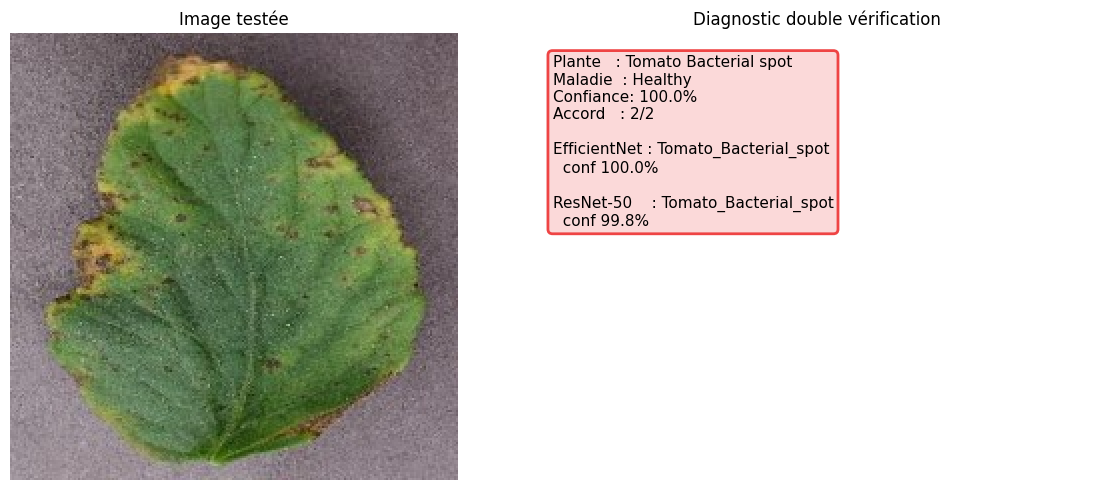


Pour tester une autre image :
  img = Image.open(r"C:\chemin\vers\votre\image.jpg").convert("RGB")
  result = predict_image(img)
  print(result)


In [22]:
# ══════════════════════════════════════════════════════════
# ÉTAPE 10 — Tester le diagnostic sur une image
# Changez IMAGE_PATH pour tester vos propres photos
# ══════════════════════════════════════════════════════════
from torchvision import transforms as T
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

preprocess = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def predict_image(pil_image):
    """Diagnostic complet avec double vérification."""
    tensor = preprocess(pil_image).unsqueeze(0)
    with torch.no_grad():
        eff_out = torch.softmax(eff_model(tensor), dim=1)[0]
        res_out = torch.softmax(res_model(tensor), dim=1)[0]

    eff_top  = eff_out.topk(3)
    res_top  = res_out.topk(3)
    eff_pred = classes[eff_top.indices[0].item()]
    res_pred = classes[res_top.indices[0].item()]
    eff_conf = float(eff_top.values[0])
    res_conf = float(res_top.values[0])

    agree      = (eff_pred == res_pred)
    final_pred = eff_pred if eff_conf >= res_conf else res_pred
    final_conf = max(eff_conf, res_conf)
    parts      = final_pred.split('__')
    plant      = parts[0].replace('_', ' ')
    disease    = parts[1].replace('_', ' ') if len(parts) > 1 else 'Healthy'

    return {
        'efficientnet'   : {'prediction': eff_pred, 'confidence': eff_conf},
        'resnet'         : {'prediction': res_pred, 'confidence': res_conf},
        'agreement'      : agree,
        'agreement_score': '2/2' if agree else '1/2',
        'final_prediction': final_pred,
        'plant'          : plant,
        'disease'        : disease,
        'confidence'     : final_conf,
        'is_healthy'     : 'healthy' in final_pred.lower(),
    }

# ── Tester sur une image du dataset ──────────────────────
# Prenez n'importe quelle image JPG pour tester
test_img_path, test_label = test_samples[0]
print(f'Image testée : {Path(test_img_path).name}')
print(f'Classe réelle : {classes[test_label]}')

img    = Image.open(test_img_path).convert('RGB')
result = predict_image(img)

# Affichage
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(img)
axes[0].axis('off')
axes[0].set_title('Image testée', fontsize=12)

color = '#22c55e' if result['is_healthy'] else '#ef4444'
info  = (
    f"Plante   : {result['plant']}\n"
    f"Maladie  : {result['disease']}\n"
    f"Confiance: {result['confidence']*100:.1f}%\n"
    f"Accord   : {result['agreement_score']}\n\n"
    f"EfficientNet : {result['efficientnet']['prediction'].split('__')[-1][:30]}\n"
    f"  conf {result['efficientnet']['confidence']*100:.1f}%\n\n"
    f"ResNet-50    : {result['resnet']['prediction'].split('__')[-1][:30]}\n"
    f"  conf {result['resnet']['confidence']*100:.1f}%"
)
axes[1].text(0.05, 0.95, info, transform=axes[1].transAxes,
             fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor=color+'33', edgecolor=color, linewidth=2))
axes[1].axis('off')
axes[1].set_title('Diagnostic double vérification', fontsize=12)

plt.tight_layout()
plt.show()
print('\nPour tester une autre image :')
print('  img = Image.open(r"C:\\chemin\\vers\\votre\\image.jpg").convert("RGB")')
print('  result = predict_image(img)')
print('  print(result)')

## Étape 11 — Génération de server.py

In [23]:
# ══════════════════════════════════════════════════════════
# ÉTAPE 11 — Générer server.py final
# ══════════════════════════════════════════════════════════

from pathlib import Path

server_code = '# server.py - AgroShield dashboard\n# Run: python server.py\n# Open from this computer: http://localhost:5000\n# Open from another device on the same network: http://<computer-ip>:5000\n\nfrom flask import Flask, jsonify, request, send_file, send_from_directory\nfrom flask_cors import CORS\nfrom werkzeug.utils import secure_filename\nfrom PIL import Image\nfrom pathlib import Path\nfrom collections import deque\nimport datetime\nimport io\nimport json\nimport random\nimport time\n\ntry:\n    import torch\n    import torch.nn as nn\n    import torchvision.models as models\n    import torchvision.transforms as T\nexcept Exception as exc:\n    torch = None\n    nn = None\n    models = None\n    T = None\n    TORCH_IMPORT_ERROR = str(exc)\nelse:\n    TORCH_IMPORT_ERROR = None\n\napp = Flask(__name__)\nCORS(app)\n\nBASE_DIR = Path(__file__).parent\nRECEIVED_IMAGES_DIR = Path(r"C:\\Users\\pc\\Desktop\\reception des images")\nMODELS_DIR = BASE_DIR / "models"\nEFF_PTH_CANDIDATES = [\n    MODELS_DIR / "efficientnet_b0.pth",\n    MODELS_DIR / "efficientnet_b0_best.pth",\n]\nRES_PTH_CANDIDATES = [\n    MODELS_DIR / "resnet_50.pth",\n    MODELS_DIR / "resnet50.pth",\n    MODELS_DIR / "resnet_50_best.pth",\n]\nMETA_CANDIDATES = [\n    MODELS_DIR / "efficientnet_b0_meta.json",\n    MODELS_DIR / "resnet_50_meta.json",\n]\n\nMODEL_STATUS = {\n    "available": False,\n    "efficientnet": False,\n    "resnet": False,\n    "message": "Mode demonstration: ajoutez le dossier models pour activer l\'IA.",\n}\n\nDEFAULT_META = {\n    "classes": [\n        "Tomato__healthy",\n        "Tomato__Late_blight",\n        "Tomato__Tomato_YellowLeaf__Curl_Virus",\n        "Pepper__bell___healthy",\n        "Pepper__bell___Bacterial_spot",\n        "Potato__Early_blight",\n    ],\n    "mean": [0.485, 0.456, 0.406],\n    "std": [0.229, 0.224, 0.225],\n}\n\nMETA = DEFAULT_META\nCLASSES = META["classes"]\nNUM_CLASSES = len(CLASSES)\neff_model = None\nres_model = None\npreprocess = None\nUSE_RESNET = False\n\n\ndef load_efficientnet(path, n):\n    model = models.efficientnet_b0(weights=None)\n    model.classifier[1] = nn.Linear(model.classifier[1].in_features, n)\n    model.load_state_dict(torch.load(path, map_location="cpu"))\n    return model.eval()\n\n\ndef load_resnet50(path, n):\n    model = models.resnet50(weights=None)\n    model.fc = nn.Linear(model.fc.in_features, n)\n    model.load_state_dict(torch.load(path, map_location="cpu"))\n    return model.eval()\n\n\ndef first_existing(paths):\n    return next((path for path in paths if path.exists()), None)\n\n\ndef initialise_models():\n    global META, CLASSES, NUM_CLASSES, eff_model, res_model, preprocess, USE_RESNET\n\n    if torch is None:\n        MODEL_STATUS["message"] = f"PyTorch indisponible: {TORCH_IMPORT_ERROR}"\n        return\n    meta_path = first_existing(META_CANDIDATES)\n    eff_path = first_existing(EFF_PTH_CANDIDATES)\n    res_path = first_existing(RES_PTH_CANDIDATES)\n    if not meta_path or not eff_path:\n        return\n\n    try:\n        with open(meta_path, encoding="utf-8") as meta_file:\n            META = json.load(meta_file)\n        CLASSES = META["classes"]\n        NUM_CLASSES = len(CLASSES)\n        preprocess = T.Compose(\n            [\n                T.Resize(256),\n                T.CenterCrop(224),\n                T.ToTensor(),\n                T.Normalize(mean=META["mean"], std=META["std"]),\n            ]\n        )\n        eff_model = load_efficientnet(eff_path, NUM_CLASSES)\n        MODEL_STATUS.update(\n            {\n                "available": True,\n                "efficientnet": True,\n                "message": f"{NUM_CLASSES} classes chargees.",\n            }\n        )\n        if res_path:\n            res_model = load_resnet50(res_path, NUM_CLASSES)\n            USE_RESNET = True\n            MODEL_STATUS["resnet"] = True\n            MODEL_STATUS["message"] = "EfficientNet-B0 et ResNet-50 charges."\n    except Exception as exc:\n        MODEL_STATUS["message"] = f"Chargement des modeles impossible: {exc}"\n        eff_model = None\n        res_model = None\n        USE_RESNET = False\n\n\ninitialise_models()\n\nCROP_THRESHOLDS = {\n    "tomato": {\n        "label": "Tomate",\n        "temperature_normal": "21-27 C",\n        "humidity_normal": "60-75 %",\n        "luminosity_normal": "450-700 lx",\n        "precipitation_normal": "0-8 mm/h",\n        "temp_ideal": "21-27 C",\n        "humidity_ideal": "60-75 %",\n        "temp_on": 29.0,\n        "temp_off": 26.0,\n        "humidity_on": 82.0,\n        "humidity_off": 72.0,\n        "rain_on": 18.0,\n        "rain_off": 8.0,\n        "luminosity_on": 720.0,\n        "source_note": "Seuils inspires des recommandations horticoles tomates: stress thermique au-dessus de 29-30 C et risque fongique quand l\'humidite reste elevee.",\n    },\n    "pepper": {\n        "label": "Poivron",\n        "temperature_normal": "21-28 C",\n        "humidity_normal": "60-75 %",\n        "luminosity_normal": "450-680 lx",\n        "precipitation_normal": "0-7 mm/h",\n        "temp_ideal": "21-28 C",\n        "humidity_ideal": "60-75 %",\n        "temp_on": 30.0,\n        "temp_off": 27.0,\n        "humidity_on": 80.0,\n        "humidity_off": 70.0,\n        "rain_on": 16.0,\n        "rain_off": 7.0,\n        "luminosity_on": 700.0,\n        "source_note": "Poivron: culture sensible aux exces de chaleur et aux eclaboussures favorisant les taches bacteriennes.",\n    },\n    "potato": {\n        "label": "Pomme de terre",\n        "temperature_normal": "16-22 C",\n        "humidity_normal": "70-85 %",\n        "luminosity_normal": "350-580 lx",\n        "precipitation_normal": "0-9 mm/h",\n        "temp_ideal": "16-22 C",\n        "humidity_ideal": "70-85 %",\n        "temp_on": 26.0,\n        "temp_off": 23.0,\n        "humidity_on": 85.0,\n        "humidity_off": 75.0,\n        "rain_on": 20.0,\n        "rain_off": 9.0,\n        "luminosity_on": 600.0,\n        "source_note": "Pomme de terre: culture de climat frais; chaleur et humidite prolongee augmentent le risque de maladies.",\n    },\n    "default": {\n        "label": "Culture standard",\n        "temperature_normal": "21-27 C",\n        "humidity_normal": "60-80 %",\n        "luminosity_normal": "350-650 lx",\n        "precipitation_normal": "0-8 mm/h",\n        "temp_ideal": "21-27 C",\n        "humidity_ideal": "60-80 %",\n        "temp_on": 29.0,\n        "temp_off": 26.0,\n        "humidity_on": 80.0,\n        "humidity_off": 70.0,\n        "rain_on": 18.0,\n        "rain_off": 8.0,\n        "luminosity_on": 650.0,\n        "source_note": "Seuil generique utilise si aucune culture precise n\'est selectionnee.",\n    },\n}\n\nCROP_DECISION_MODELS = {\n    "tomato": {\n        "base_temp": 10.0,\n        "sowing_date": "2026-03-15",\n        "gdd_stages": [(350, "Reprise vegetative"), (650, "Floraison"), (1050, "Nouaison"), (1500, "Recolte proche")],\n        "soil_optimum": 68,\n    },\n    "pepper": {\n        "base_temp": 12.0,\n        "sowing_date": "2026-03-20",\n        "gdd_stages": [(320, "Reprise vegetative"), (700, "Floraison"), (1100, "Fructification"), (1600, "Recolte proche")],\n        "soil_optimum": 65,\n    },\n    "potato": {\n        "base_temp": 7.0,\n        "sowing_date": "2026-03-10",\n        "gdd_stages": [(280, "Emergence"), (650, "Tubérisation"), (1000, "Grossissement"), (1350, "Maturite")],\n        "soil_optimum": 72,\n    },\n    "default": {\n        "base_temp": 10.0,\n        "sowing_date": "2026-03-15",\n        "gdd_stages": [(320, "Croissance"), (650, "Floraison"), (1050, "Production"), (1450, "Recolte proche")],\n        "soil_optimum": 68,\n    },\n}\n\nsystem_state = {\n    "current_crop": "default",\n    "mode": "repos",\n    "plate_angle": 0,\n    "servo_angle": 0,\n    "last_change": 0,\n}\nHYSTERESIS_DELAY = 8\nsensor_history = deque(maxlen=30)\ndetections_db = []\nlatest_analysis = None\nprocessed_received_images = set()\nlatest_raspberry_payload = {"timestamp": 0, "data": None}\n\nZONES = {\n    "A": {"label": "Zone A", "x_cm": (0, 20), "actuator": "module_gauche"},\n    "B": {"label": "Zone B", "x_cm": (20, 40), "actuator": "module_central"},\n    "C": {"label": "Zone C", "x_cm": (40, 60), "actuator": "module_droit"},\n}\n\nADJACENT_ZONES = {"A": ["B"], "B": ["A", "C"], "C": ["B"]}\n\nDISEASE_POLICIES = {\n    "late blight": {\n        "risk": 0.95,\n        "spread": "tres elevee",\n        "action": "Traiter A, B et C; isoler les plants tres atteints et limiter la mouillure foliaire.",\n        "scope": "all",\n        "weather": "cool_wet",\n        "mechanical_bias": "pluie",\n        "source": "Late blight is strongly favored by cool, wet and humid weather.",\n    },\n    "bacterial spot": {\n        "risk": 0.86,\n        "spread": "elevee",\n        "action": "Traiter la zone detectee et les zones voisines; reduire les eclaboussures et l\'humidite foliaire.",\n        "scope": "adjacent_high_all",\n        "weather": "warm_wet_splash",\n        "mechanical_bias": "pluie",\n        "source": "Bacterial spot is favored by warm wet weather and rain splash dispersal.",\n    },\n    "yellowleaf": {\n        "risk": 0.82,\n        "spread": "elevee",\n        "action": "Surveiller A, B et C; controler les aleurodes vecteurs et reduire le stress thermique.",\n        "scope": "all",\n        "weather": "warm_vector",\n        "mechanical_bias": "chaleur",\n        "source": "Tomato yellow leaf curl virus is vectored by whiteflies, with pressure increasing in warm crops.",\n    },\n    "yellow leaf": {\n        "risk": 0.82,\n        "spread": "elevee",\n        "action": "Surveiller A, B et C; controler les aleurodes vecteurs et reduire le stress thermique.",\n        "scope": "all",\n        "weather": "warm_vector",\n        "mechanical_bias": "chaleur",\n        "source": "Tomato yellow leaf curl virus is vectored by whiteflies, with pressure increasing in warm crops.",\n    },\n    "mosaic virus": {\n        "risk": 0.78,\n        "spread": "elevee",\n        "action": "Isoler la zone detectee, desinfecter les manipulations et inspecter toute la culture.",\n        "scope": "all_if_confident",\n        "weather": "contact_vector",\n        "mechanical_bias": "repos",\n        "source": "Mosaic viruses spread mainly by contact or vectors; climate is treated as a secondary stress factor.",\n    },\n    "septoria": {\n        "risk": 0.76,\n        "spread": "moyenne a elevee",\n        "action": "Traiter la zone et les demi-zones adjacentes; reduire la mouillure foliaire.",\n        "scope": "adjacent",\n        "weather": "wet_splash",\n        "mechanical_bias": "pluie",\n        "source": "Septoria leaf spot spreads by rain splash and is favored by prolonged leaf wetness.",\n    },\n    "leaf mold": {\n        "risk": 0.74,\n        "spread": "moyenne a elevee",\n        "action": "Traiter la zone et les demi-zones adjacentes; ameliorer l\'aeration et baisser l\'humidite.",\n        "scope": "adjacent",\n        "weather": "humid",\n        "mechanical_bias": "pluie",\n        "source": "Tomato leaf mold is favored by high relative humidity.",\n    },\n    "target spot": {\n        "risk": 0.73,\n        "spread": "moyenne a elevee",\n        "action": "Traiter la zone detectee et la demi-zone voisine la plus exposee.",\n        "scope": "adjacent",\n        "weather": "warm_wet_splash",\n        "mechanical_bias": "pluie",\n        "source": "Foliar spot diseases intensify when foliage remains wet and splash dispersal occurs.",\n    },\n    "early blight": {\n        "risk": 0.70,\n        "spread": "moyenne",\n        "action": "Traiter la zone detectee; ajouter les demi-zones voisines si confiance forte ou climat humide.",\n        "scope": "confidence_adjacent",\n        "weather": "warm_wet_splash",\n        "mechanical_bias": "pluie",\n        "source": "Early blight is favored by warm, wet weather and extended leaf wetness.",\n    },\n    "spider mites": {\n        "risk": 0.64,\n        "spread": "moyenne",\n        "action": "Traiter la zone detectee et inspecter les zones voisines en climat chaud et sec.",\n        "scope": "confidence_adjacent",\n        "weather": "hot_dry",\n        "mechanical_bias": "chaleur",\n        "source": "Spider mite pressure typically rises under hot and dry stress.",\n    },\n}\n\nCLIMATE_IMPACT_BY_CLASS = {\n    "Pepper__bell___Bacterial_spot": {\n        "label": "Poivron - tache bacterienne",\n        "heat": {"level": "modere a eleve", "bonus": 0.10, "trigger": "warm", "action": "Limiter le stress thermique; eviter que le feuillage reste humide sous chaleur."},\n        "rain": {"level": "eleve", "bonus": 0.22, "trigger": "wet", "action": "Incliner les plaques, reduire les eclaboussures et proteger les zones voisines."},\n        "mechanical": {"heat": "chaleur", "rain": "pluie"},\n        "rationale": "Les taches bacteriennes du poivron/tomate sont favorisees par temps chaud et humide et par les eclaboussures de pluie.",\n    },\n    "Pepper__bell___healthy": {\n        "label": "Poivron sain",\n        "heat": {"level": "stress physiologique", "bonus": 0.00, "trigger": "heat", "action": "Proteger seulement si le seuil chaleur du poivron est depasse."},\n        "rain": {"level": "stress hydrique", "bonus": 0.00, "trigger": "rain", "action": "Canaliser l\'exces d\'eau seulement si pluie intense."},\n        "mechanical": {"heat": "chaleur", "rain": "pluie"},\n        "rationale": "Aucune maladie detectee: le climat pilote la protection de culture, pas la propagation.",\n    },\n    "Potato___Early_blight": {\n        "label": "Pomme de terre - alternariose",\n        "heat": {"level": "modere", "bonus": 0.08, "trigger": "warm", "action": "Surveiller si chaleur accompagnee d\'humidite foliaire."},\n        "rain": {"level": "modere a eleve", "bonus": 0.16, "trigger": "wet", "action": "Incliner si pluie/humidite elevee; traiter la zone et demi-zones voisines si risque monte."},\n        "mechanical": {"heat": "chaleur", "rain": "pluie"},\n        "rationale": "L\'alternariose est favorisee par chaleur moderee a elevee, humidite et mouillure foliaire.",\n    },\n    "Potato___Late_blight": {\n        "label": "Pomme de terre - mildiou",\n        "heat": {"level": "faible a modere", "bonus": 0.04, "trigger": "stress", "action": "La chaleur seule n\'est pas le facteur principal; surveiller le stress."},\n        "rain": {"level": "tres eleve", "bonus": 0.28, "trigger": "wet", "action": "Incliner immediatement vers le canal et traiter A, B et C."},\n        "mechanical": {"heat": "repos", "rain": "pluie"},\n        "rationale": "Le mildiou de la pomme de terre progresse fortement en conditions humides, pluvieuses et avec mouillure prolongee.",\n    },\n    "Potato___healthy": {\n        "label": "Pomme de terre saine",\n        "heat": {"level": "stress physiologique", "bonus": 0.00, "trigger": "heat", "action": "Proteger si chaleur superieure au seuil pomme de terre."},\n        "rain": {"level": "stress hydrique", "bonus": 0.00, "trigger": "rain", "action": "Canaliser si pluie intense pour eviter saturation."},\n        "mechanical": {"heat": "chaleur", "rain": "pluie"},\n        "rationale": "Aucune maladie detectee: action climatique classique.",\n    },\n    "Tomato_Bacterial_spot": {\n        "label": "Tomate - tache bacterienne",\n        "heat": {"level": "modere a eleve", "bonus": 0.10, "trigger": "warm", "action": "Reduire stress thermique et surveiller humidite."},\n        "rain": {"level": "eleve", "bonus": 0.22, "trigger": "wet", "action": "Incliner les plaques pour limiter eclaboussures et extension aux zones voisines."},\n        "mechanical": {"heat": "chaleur", "rain": "pluie"},\n        "rationale": "La tache bacterienne est favorisee par temps chaud et humide et se disperse par eau/eclaboussures.",\n    },\n    "Tomato_Early_blight": {\n        "label": "Tomate - alternariose",\n        "heat": {"level": "modere", "bonus": 0.08, "trigger": "warm", "action": "Surveiller chaleur + humidite; reduire stress."},\n        "rain": {"level": "modere a eleve", "bonus": 0.16, "trigger": "wet", "action": "Incliner en pluie/humidite; etendre surveillance aux demi-zones voisines."},\n        "mechanical": {"heat": "chaleur", "rain": "pluie"},\n        "rationale": "L\'alternariose de la tomate augmente avec chaleur, humidite et mouillure foliaire.",\n    },\n    "Tomato_Late_blight": {\n        "label": "Tomate - mildiou",\n        "heat": {"level": "faible a modere", "bonus": 0.04, "trigger": "stress", "action": "La chaleur seule n\'est pas le facteur principal; conserver la surveillance."},\n        "rain": {"level": "tres eleve", "bonus": 0.28, "trigger": "wet", "action": "Incliner immediatement et traiter A, B et C."},\n        "mechanical": {"heat": "repos", "rain": "pluie"},\n        "rationale": "Le mildiou tomate/pomme de terre est surtout favorise par humidite, pluie et mouillure prolongee.",\n    },\n    "Tomato_Leaf_Mold": {\n        "label": "Tomate - leaf mold",\n        "heat": {"level": "modere si serre chaude et humide", "bonus": 0.06, "trigger": "warm_humid", "action": "Eviter de fermer si cela augmente l\'humidite; favoriser aeration."},\n        "rain": {"level": "eleve par humidite", "bonus": 0.20, "trigger": "humid", "action": "Reduire humidite foliaire; incliner si pluie/humidite depasse le seuil."},\n        "mechanical": {"heat": "repos", "rain": "pluie"},\n        "rationale": "La moisissure foliaire est fortement liee a l\'humidite relative elevee.",\n    },\n    "Tomato_Septoria_leaf_spot": {\n        "label": "Tomate - septoriose",\n        "heat": {"level": "faible a modere", "bonus": 0.05, "trigger": "stress", "action": "La chaleur seule n\'est pas prioritaire; surveiller si humidite simultanee."},\n        "rain": {"level": "eleve", "bonus": 0.24, "trigger": "wet", "action": "Incliner vers le canal; limiter eclaboussures; traiter zone + demi-zone voisine."},\n        "mechanical": {"heat": "repos", "rain": "pluie"},\n        "rationale": "La septoriose se propage par eclaboussures et mouillure prolongee des feuilles.",\n    },\n    "Tomato_Spider_mites_Two_spotted_spider_mite": {\n        "label": "Tomate - acariens tetranyques",\n        "heat": {"level": "eleve", "bonus": 0.20, "trigger": "hot_dry", "action": "Couvrir en forte chaleur pour reduire stress; inspecter zones voisines."},\n        "rain": {"level": "faible", "bonus": -0.04, "trigger": "rain", "action": "La pluie n\'augmente pas directement la propagation; eviter humidite excessive."},\n        "mechanical": {"heat": "chaleur", "rain": "repos"},\n        "rationale": "Les acariens sont generalement favorises par conditions chaudes et seches.",\n    },\n    "Tomato__Target_Spot": {\n        "label": "Tomate - target spot",\n        "heat": {"level": "modere", "bonus": 0.08, "trigger": "warm", "action": "Surveiller si chaleur accompagnee d\'humidite."},\n        "rain": {"level": "eleve", "bonus": 0.20, "trigger": "wet", "action": "Incliner en pluie; traiter zone et demi-zone voisine."},\n        "mechanical": {"heat": "chaleur", "rain": "pluie"},\n        "rationale": "Les taches foliaires sont aggravees par humidite, pluie et mouillure des feuilles.",\n    },\n    "Tomato__Tomato_YellowLeaf__Curl_Virus": {\n        "label": "Tomate - Yellow Leaf Curl Virus",\n        "heat": {"level": "eleve via vecteurs/stress", "bonus": 0.16, "trigger": "warm", "action": "Reduire stress thermique; renforcer surveillance A, B et C et controle aleurodes."},\n        "rain": {"level": "faible a modere", "bonus": 0.04, "trigger": "stress", "action": "La pluie n\'est pas le vecteur principal; maintenir surveillance globale."},\n        "mechanical": {"heat": "chaleur", "rain": "repos"},\n        "rationale": "Le virus est transmis par aleurodes; la chaleur et le stress de culture renforcent le risque operationnel.",\n    },\n    "Tomato__Tomato_mosaic_virus": {\n        "label": "Tomate - virus mosaïque",\n        "heat": {"level": "faible indirect", "bonus": 0.03, "trigger": "stress", "action": "Action mecanique seulement si stress climatique depasse les seuils."},\n        "rain": {"level": "faible indirect", "bonus": 0.03, "trigger": "stress", "action": "La pluie n\'est pas le vecteur principal; privilegier hygiene et isolation."},\n        "mechanical": {"heat": "repos", "rain": "repos"},\n        "rationale": "La mosaïque se transmet surtout mecaniquement/contact; le climat agit surtout comme stress secondaire.",\n    },\n    "Tomato_healthy": {\n        "label": "Tomate saine",\n        "heat": {"level": "stress physiologique", "bonus": 0.00, "trigger": "heat", "action": "Couvrir si temperature/luminosite depasse le seuil tomate."},\n        "rain": {"level": "stress hydrique", "bonus": 0.00, "trigger": "rain", "action": "Incliner si pluie intense pour canaliser l\'eau."},\n        "mechanical": {"heat": "chaleur", "rain": "pluie"},\n        "rationale": "Aucune maladie detectee: seule la protection climatique normale est active.",\n    },\n}\n\n\n\ndef classify_mechanical_mode(sensors, crop="default"):\n    th = CROP_THRESHOLDS.get(crop, CROP_THRESHOLDS["default"])\n    current = system_state["mode"]\n\n    rain_alert = sensors["precipitation"] >= th["rain_on"] or sensors["humidity"] >= th["humidity_on"]\n    heat_alert = sensors["temperature"] >= th["temp_on"] or sensors["luminosity"] >= th["luminosity_on"]\n    clear_rain = sensors["precipitation"] <= th["rain_off"] and sensors["humidity"] <= th["humidity_off"]\n    clear_heat = sensors["temperature"] <= th["temp_off"] and sensors["luminosity"] < th["luminosity_on"] - 80\n\n    if current == "pluie" and not clear_rain:\n        return "pluie"\n    if rain_alert:\n        return "pluie"\n    if current == "chaleur" and not clear_heat:\n        return "chaleur"\n    if heat_alert:\n        return "chaleur"\n    return "repos"\n\n\ndef latest_active_disease(max_age_seconds=1800):\n    now = datetime.datetime.now()\n    for detection in reversed(detections_db):\n        if detection.get("is_healthy") or detection.get("out_of_domain") or detection.get("is_valid_leaf") is False:\n            continue\n        try:\n            detected_at = datetime.datetime.fromisoformat(detection["timestamp"])\n        except (KeyError, ValueError):\n            return detection\n        if (now - detected_at).total_seconds() <= max_age_seconds:\n            return detection\n    return None\n\n\ndef environmental_modifier(policy, sensors, crop="default"):\n    th = CROP_THRESHOLDS.get(crop, CROP_THRESHOLDS["default"])\n    weather = policy.get("weather", "")\n    warm = sensors["temperature"] >= th["temp_on"] - 1\n    hot = sensors["temperature"] >= th["temp_on"]\n    humid = sensors["humidity"] >= th["humidity_on"]\n    wet = sensors["precipitation"] >= th["rain_off"] or humid\n    heavy_rain = sensors["precipitation"] >= th["rain_on"]\n    dry = sensors["humidity"] <= 45 and sensors["precipitation"] <= 2\n\n    score = 0.0\n    reasons = []\n    if weather == "cool_wet":\n        score += 0.18 if wet else 0\n        score += 0.08 if sensors["temperature"] <= th["temp_on"] else 0\n        if wet:\n            reasons.append("mouillure foliaire favorable")\n    elif weather == "warm_wet_splash":\n        score += 0.14 if warm else 0\n        score += 0.18 if wet else 0\n        score += 0.10 if heavy_rain else 0\n        if wet:\n            reasons.append("eclaboussures/pluie favorables")\n    elif weather == "wet_splash":\n        score += 0.18 if wet else 0\n        score += 0.12 if heavy_rain else 0\n        if wet:\n            reasons.append("dispersion par gouttes d\'eau")\n    elif weather == "humid":\n        score += 0.22 if humid else 0\n        if humid:\n            reasons.append("humidite relative elevee")\n    elif weather == "warm_vector":\n        score += 0.16 if warm else 0\n        if warm:\n            reasons.append("stress thermique et pression vecteurs")\n    elif weather == "hot_dry":\n        score += 0.18 if hot and dry else 0\n        if hot and dry:\n            reasons.append("climat chaud et sec")\n    elif weather == "contact_vector":\n        score += 0.06 if warm or humid else 0\n\n    return min(0.30, score), reasons\n\n\ndef climate_state(sensors, crop="default"):\n    th = CROP_THRESHOLDS.get(crop, CROP_THRESHOLDS["default"])\n    heat = sensors["temperature"] >= th["temp_on"] or sensors["luminosity"] >= th["luminosity_on"]\n    rain = sensors["precipitation"] >= th["rain_on"] or sensors["humidity"] >= th["humidity_on"]\n    warm = sensors["temperature"] >= th["temp_on"] - 1\n    wet = sensors["precipitation"] >= th["rain_off"] or sensors["humidity"] >= th["humidity_off"]\n    hot_dry = sensors["temperature"] >= th["temp_on"] and sensors["humidity"] <= 45 and sensors["precipitation"] <= 2\n    return {\n        "heat": heat,\n        "rain": rain,\n        "warm": warm,\n        "wet": wet,\n        "hot_dry": hot_dry,\n        "thresholds": th,\n    }\n\n\ndef trigger_active(trigger, state):\n    return {\n        "heat": state["heat"],\n        "rain": state["rain"],\n        "warm": state["warm"],\n        "wet": state["wet"],\n        "humid": state["wet"],\n        "warm_humid": state["warm"] and state["wet"],\n        "hot_dry": state["hot_dry"],\n        "stress": state["heat"] or state["rain"],\n    }.get(trigger, False)\n\n\ndef climate_diagnosis_for_result(result, sensors, crop="default"):\n    if result.get("out_of_domain") or result.get("is_valid_leaf") is False:\n        return {\n            "class_label": "Image hors dataset",\n            "current_weather": {\n                "temperature": sensors["temperature"],\n                "humidity": sensors["humidity"],\n                "precipitation": sensors["precipitation"],\n                "luminosity": sensors["luminosity"],\n                "heat_alert": False,\n                "rain_alert": False,\n            },\n            "heat": {\n                "active": False,\n                "level": "non applicable",\n                "risk_delta": 0,\n                "action": "Aucune action maladie: image non reconnue comme feuille de tomate, poivron ou pomme de terre.",\n            },\n            "rain": {\n                "active": False,\n                "level": "non applicable",\n                "risk_delta": 0,\n                "action": "Aucune action maladie: verifier la prise de vue et recapturer une feuille.",\n            },\n            "base_risk": 0,\n            "climate_delta": 0,\n            "instant_risk": 0,\n            "recommended_mechanism": "repos",\n            "rationale": "L\'image est rejetee par le controle hors domaine; elle ne pilote pas les plaques.",\n        }\n    profile = CLIMATE_IMPACT_BY_CLASS.get(result["predicted_class"])\n    if profile is None:\n        profile = {\n            "label": result["predicted_class"],\n            "heat": {"level": "non specialise", "bonus": 0.03, "trigger": "stress", "action": "Surveiller le stress climatique."},\n            "rain": {"level": "non specialise", "bonus": 0.03, "trigger": "stress", "action": "Surveiller humidite et precipitation."},\n            "mechanical": {"heat": "repos", "rain": "repos"},\n            "rationale": "Classe non mappee explicitement: regle prudente.",\n        }\n    state = climate_state(sensors, crop)\n    heat_active = trigger_active(profile["heat"]["trigger"], state)\n    rain_active = trigger_active(profile["rain"]["trigger"], state)\n    heat_bonus = profile["heat"]["bonus"] if heat_active else 0\n    rain_bonus = profile["rain"]["bonus"] if rain_active else 0\n    climate_bonus = max(-0.05, min(0.32, heat_bonus + rain_bonus))\n    base_policy = disease_policy(result["disease"])\n    base_risk = 0.0 if result["is_healthy"] else base_policy["risk"]\n    instant_risk = round(max(0, min(0.98, base_risk + climate_bonus)), 2)\n\n    recommended_mode = "repos"\n    if rain_active and profile["mechanical"].get("rain") != "repos":\n        recommended_mode = profile["mechanical"]["rain"]\n    elif heat_active and profile["mechanical"].get("heat") != "repos":\n        recommended_mode = profile["mechanical"]["heat"]\n    elif state["rain"]:\n        recommended_mode = "pluie"\n    elif state["heat"]:\n        recommended_mode = "chaleur"\n\n    return {\n        "class_label": profile["label"],\n        "current_weather": {\n            "temperature": sensors["temperature"],\n            "humidity": sensors["humidity"],\n            "precipitation": sensors["precipitation"],\n            "luminosity": sensors["luminosity"],\n            "heat_alert": state["heat"],\n            "rain_alert": state["rain"],\n        },\n        "heat": {\n            "active": heat_active,\n            "level": profile["heat"]["level"],\n            "risk_delta": round(heat_bonus, 2),\n            "action": profile["heat"]["action"],\n        },\n        "rain": {\n            "active": rain_active,\n            "level": profile["rain"]["level"],\n            "risk_delta": round(rain_bonus, 2),\n            "action": profile["rain"]["action"],\n        },\n        "base_risk": round(base_risk, 2),\n        "climate_delta": round(climate_bonus, 2),\n        "instant_risk": instant_risk,\n        "recommended_mechanism": recommended_mode,\n        "rationale": profile["rationale"],\n    }\n\n\ndef disease_informed_mechanical_mode(sensors, crop="default"):\n    base_mode = classify_mechanical_mode(sensors, crop)\n    detection = latest_active_disease()\n    if not detection:\n        return base_mode, []\n\n    result_like = {\n        "predicted_class": detection.get("predicted_class", ""),\n        "disease": detection.get("disease", ""),\n        "is_healthy": detection.get("is_healthy", False),\n    }\n    diagnosis = climate_diagnosis_for_result(result_like, sensors, crop)\n    if diagnosis["climate_delta"] < 0.12:\n        return base_mode, [diagnosis["rationale"]]\n    mode = diagnosis["recommended_mechanism"]\n    if mode in {"pluie", "chaleur"}:\n        return mode, [diagnosis["rationale"]]\n    if base_mode != "repos":\n        return base_mode, [diagnosis["rationale"]]\n    return base_mode, [diagnosis["rationale"]]\n\n\ndef apply_mechanical_state(mode):\n    target = {\n        "repos": {"plate_angle": 0, "servo_angle": 0},\n        "chaleur": {"plate_angle": 90, "servo_angle": 90},\n        "pluie": {"plate_angle": 45, "servo_angle": 55},\n    }[mode]\n    system_state.update({"mode": mode, **target, "last_change": time.time()})\n\n\ndef evaluate_actuator(sensors, crop="default"):\n    next_mode, _ = disease_informed_mechanical_mode(sensors, crop)\n    elapsed = time.time() - system_state["last_change"]\n    th = CROP_THRESHOLDS.get(crop, CROP_THRESHOLDS["default"])\n    urgent_rain = next_mode == "pluie" and (\n        sensors["precipitation"] >= th["rain_on"] or latest_active_disease() is not None\n    )\n    urgent_heat = next_mode == "chaleur" and (\n        sensors["temperature"] >= th["temp_on"] and latest_active_disease() is not None\n    )\n    if next_mode != system_state["mode"] and (elapsed >= HYSTERESIS_DELAY or urgent_rain or urgent_heat):\n        apply_mechanical_state(next_mode)\n\n\ndef mechanism_description(mode):\n    return {\n        "repos": "Plaques abaissees a 0 degre: la culture reste ouverte.",\n        "chaleur": "Plaques horizontales a 90 degres: elles couvrent la culture contre la forte chaleur.",\n        "pluie": "Plaques inclinees vers le canal central: l\'eau est conduite vers le reservoir.",\n    }[mode]\n\n\ndef risk_level(score):\n    if score >= 75:\n        return "critique"\n    if score >= 55:\n        return "attention"\n    return "normal"\n\n\ndef zone_adjustment(zone):\n    return {"A": -4, "B": 0, "C": 5}.get(zone, 0)\n\n\ndef compute_zone_swi(data, crop="default"):\n    model = CROP_DECISION_MODELS.get(crop, CROP_DECISION_MODELS["default"])\n    soil = float(data.get("soil_moisture", model["soil_optimum"]))\n    temp = float(data["temperature"])\n    humidity = float(data["humidity"])\n    rain = float(data["precipitation"])\n    light = float(data["luminosity"])\n    opt = model["soil_optimum"]\n    thermal = max(0, temp - CROP_THRESHOLDS.get(crop, CROP_THRESHOLDS["default"])["temp_off"]) * 2.1\n    dry_air = max(0, 58 - humidity) * 0.55\n    light_load = max(0, light - 650) * 0.035\n    rain_relief = min(18, rain * 0.7)\n    base = max(0, opt - soil) * 1.35 + thermal + dry_air + light_load - rain_relief\n    zones = {}\n    for zone in ("A", "B", "C"):\n        score = round(max(0, min(100, base + zone_adjustment(zone))))\n        zones[zone] = {\n            "score": score,\n            "level": risk_level(score),\n            "recommendation": "Irrigation automatique recommandee" if score >= 65 else ("Surveillance irrigation" if score >= 45 else "Hydratation correcte"),\n        }\n    return zones\n\n\ndef compute_gdd(data, crop="default"):\n    model = CROP_DECISION_MODELS.get(crop, CROP_DECISION_MODELS["default"])\n    try:\n        sowing = datetime.date.fromisoformat(model["sowing_date"])\n    except ValueError:\n        sowing = datetime.date(datetime.datetime.now().year, 3, 15)\n    today = datetime.datetime.now().date()\n    days = max(1, (today - sowing).days)\n    history = list(sensor_history)[-24:]\n    mean_temp = sum(item["temperature"] for item in history) / len(history) if history else float(data["temperature"])\n    daily_gdd = max(0, mean_temp - model["base_temp"])\n    cumulative = round(daily_gdd * days, 1)\n    stages = model["gdd_stages"]\n    stage = stages[0][1]\n    next_stage = stages[-1]\n    for threshold, label in stages:\n        if cumulative >= threshold:\n            stage = label\n        else:\n            next_stage = (threshold, label)\n            break\n    remaining = max(0, next_stage[0] - cumulative)\n    days_to_next = round(remaining / max(0.1, daily_gdd))\n    return {\n        "cumulative": cumulative,\n        "daily": round(daily_gdd, 1),\n        "stage": stage,\n        "next_stage": next_stage[1],\n        "days_to_next": days_to_next,\n        "base_temp": model["base_temp"],\n        "sowing_date": model["sowing_date"],\n    }\n\n\ndef compute_ndvi_proxy(data):\n    green = max(0, min(255, 80 + data.get("soil_moisture", 62) * 1.5 - data["temperature"] * 0.7))\n    red = max(0, min(255, 70 + data["temperature"] * 1.4 + data["precipitation"] * 0.25))\n    blue = max(0, min(255, 45 + data["humidity"] * 0.35))\n    gcc = green / max(1, red + green + blue)\n    ndvi_proxy = round(max(0, min(0.95, (gcc - 0.28) / 0.34)), 2)\n    trend = "stable"\n    if data["temperature"] >= CROP_THRESHOLDS.get(data.get("crop", "default"), CROP_THRESHOLDS["default"])["temp_on"] or data["humidity"] >= 88:\n        trend = "baisse probable"\n    elif data.get("soil_moisture", 65) >= 65 and data["temperature"] < 29:\n        trend = "hausse legere"\n    return {"value": ndvi_proxy, "gcc": round(gcc, 3), "trend": trend, "method": "proxy RGB Green Chromatic Coordinate"}\n\n\ndef compute_risk_forecast(data, crop="default", disease_context=None):\n    th = CROP_THRESHOLDS.get(crop, CROP_THRESHOLDS["default"])\n    base = 24\n    if data["humidity"] >= th["humidity_on"]:\n        base += 18\n    if data["precipitation"] >= th["rain_on"]:\n        base += 22\n    if data["temperature"] >= th["temp_on"]:\n        base += 14\n    if disease_context:\n        base += round(disease_context.get("combined_risk", 0) * 28)\n    days = []\n    for idx in range(1, 8):\n        drift = (idx - 1) * 3\n        rain_wave = 7 if idx in {2, 3, 4} and data["precipitation"] > th["rain_off"] else 0\n        score = max(5, min(98, base + drift + rain_wave - idx))\n        days.append({"day": idx, "risk": score, "level": risk_level(score)})\n    peak = max(days, key=lambda item: item["risk"])\n    action = "Traitement preventif conseille" if peak["risk"] >= 75 else ("Surveillance rapprochee" if peak["risk"] >= 55 else "Risque controle")\n    return {"days": days, "peak_day": peak["day"], "peak_risk": peak["risk"], "action": action}\n\n\ndef build_alerts(data, analytics, disease_context=None):\n    alerts = []\n    for zone, info in analytics["swi"]["zones"].items():\n        if info["score"] >= 75:\n            alerts.append({"level": "critique", "zone": zone, "message": f"Stress hydrique zone {zone}: {info[\'score\']}/100", "action": "Irrigation automatique recommandee"})\n        elif info["score"] >= 55:\n            alerts.append({"level": "attention", "zone": zone, "message": f"Stress hydrique modere zone {zone}", "action": "Verifier humidite du sol"})\n    if analytics["forecast"]["peak_risk"] >= 75:\n        alerts.append({"level": "critique", "zone": disease_context.get("zone", "A") if disease_context else "A/B/C", "message": f"Risque maladie J+{analytics[\'forecast\'][\'peak_day\']}: {analytics[\'forecast\'][\'peak_risk\']}%", "action": analytics["forecast"]["action"]})\n    if data["mechanism"]["mode"] != "repos":\n        alerts.append({"level": "info", "zone": "systeme", "message": f"Plaques en mode {data[\'mechanism\'][\'mode\']}", "action": data["actuator_command"]["reason"]})\n    return alerts[:6]\n\n\ndef compute_decision_analytics(data, crop="default", disease_context=None):\n    analytics = {\n        "swi": {"zones": compute_zone_swi(data, crop), "method": "Indice operationnel derive humidite sol, temperature, humidite air, pluie et luminosite"},\n        "gdd": compute_gdd(data, crop),\n        "ndvi": compute_ndvi_proxy(data),\n    }\n    analytics["forecast"] = compute_risk_forecast(data, crop, disease_context)\n    return analytics\n\n\ndef decorate_sensor_payload(data, crop="default"):\n    crop = crop if crop in CROP_THRESHOLDS else "default"\n    data["crop"] = crop\n    evaluate_actuator(data, crop)\n    th = CROP_THRESHOLDS.get(crop, CROP_THRESHOLDS["default"])\n    active_detection = latest_active_disease()\n    disease_context = None\n    if active_detection:\n        result_like = {\n            "predicted_class": active_detection.get("predicted_class", ""),\n            "disease": active_detection.get("disease", ""),\n            "is_healthy": active_detection.get("is_healthy", False),\n        }\n        diagnosis = climate_diagnosis_for_result(result_like, data, crop)\n        disease_context = {\n            "disease": active_detection.get("disease"),\n            "zone": active_detection.get("zone_id"),\n            "base_risk": diagnosis["base_risk"],\n            "weather_modifier": diagnosis["climate_delta"],\n            "combined_risk": diagnosis["instant_risk"],\n            "weather_reasons": [diagnosis["rationale"]],\n            "mechanical_bias": diagnosis["recommended_mechanism"],\n        }\n    data["thresholds"] = th\n    data["mechanism"] = {\n        "mode": system_state["mode"],\n        "plate_angle": system_state["plate_angle"],\n        "servo_angle": system_state["servo_angle"],\n        "description": mechanism_description(system_state["mode"]),\n    }\n    data["plates"] = {\n        "angle": system_state["plate_angle"],\n        "left": system_state["mode"] != "repos",\n        "right": system_state["mode"] != "repos",\n    }\n    data["alerts"] = {\n        "temperature": data["temperature"] >= th["temp_on"],\n        "humidity": data["humidity"] >= th["humidity_on"],\n        "precipitation": data["precipitation"] >= th["rain_on"],\n        "luminosity": data["luminosity"] >= th["luminosity_on"],\n    }\n    data["disease_context"] = disease_context\n    command_reason = "Seuils climatiques de la culture"\n    command_source = "crop_thresholds"\n    if disease_context and disease_context["combined_risk"] >= 0.70:\n        command_reason = (\n            f"Maladie detectee en zone {disease_context[\'zone\']}: "\n            f"risque maladie-climat {round(disease_context[\'combined_risk\'] * 100)}%"\n        )\n        command_source = "disease_climate_loop"\n    data["actuator_command"] = {\n        "mode": system_state["mode"],\n        "plate_angle": system_state["plate_angle"],\n        "servo_angle": system_state["servo_angle"],\n        "source": command_source,\n        "reason": command_reason,\n        "apply_on_raspberry": True,\n    }\n    data["analytics"] = compute_decision_analytics(data, crop, disease_context)\n    data["alerts_center"] = build_alerts(data, data["analytics"], disease_context)\n    sensor_history.append(data.copy())\n    return data\n\n\ndef get_sensors():\n    raspberry = latest_raspberry_payload.get("data")\n    if raspberry and time.time() - latest_raspberry_payload.get("timestamp", 0) < 25:\n        data = dict(raspberry)\n        data["mode"] = "raspberry"\n        data["last_update"] = latest_raspberry_payload["timestamp"]\n        return decorate_sensor_payload(data, data.get("crop", system_state["current_crop"]))\n\n    # The simulation deliberately creates occasional heat and rain peaks so the\n    # interface visibly demonstrates all mechanical positions during a defense.\n    event = random.choices(["normal", "heat", "rain"], weights=[0.58, 0.22, 0.20], k=1)[0]\n    if event == "heat":\n        temperature = random.uniform(29, 37)\n        humidity = random.uniform(42, 68)\n        precipitation = random.uniform(0, 5)\n        luminosity = random.uniform(680, 920)\n    elif event == "rain":\n        temperature = random.uniform(20, 28)\n        humidity = random.uniform(82, 96)\n        precipitation = random.uniform(20, 48)\n        luminosity = random.uniform(120, 430)\n    else:\n        temperature = random.uniform(22, 27)\n        humidity = random.uniform(48, 72)\n        precipitation = random.uniform(0, 7)\n        luminosity = random.uniform(280, 620)\n\n    data = {\n        "temperature": round(temperature, 1),\n        "humidity": round(humidity, 1),\n        "precipitation": round(precipitation, 1),\n        "luminosity": round(luminosity, 1),\n        "soil_moisture": round(random.uniform(48, 78), 1),\n        "reservoir_level": round(random.uniform(42, 92), 1),\n        "mode": "simulation",\n        "last_update": time.time(),\n        "crop": system_state["current_crop"],\n    }\n    return decorate_sensor_payload(data, system_state["current_crop"])\n\n\ndef mock_predict():\n    choices = [\n        ("Tomato", "healthy", 0.93, True),\n        ("Tomato", "Late blight", 0.88, False),\n        ("Tomato", "Yellow Leaf Curl Virus", 0.84, False),\n        ("Pepper bell", "Bacterial spot", 0.81, False),\n        ("Potato", "Early blight", 0.79, False),\n    ]\n    plant, disease, confidence, healthy = random.choice(choices)\n    return {\n        "predicted_class": f"{plant}___{disease}",\n        "efficientnet": {"prediction": f"{plant}__{disease}", "confidence": confidence, "top3": []},\n        "resnet": {"prediction": f"{plant}__{disease}", "confidence": confidence - 0.03, "top3": []},\n        "agreement": True,\n        "agreement_score": "demo",\n        "plant": plant,\n        "disease": disease,\n        "confidence": confidence,\n        "is_healthy": healthy,\n        "is_valid_leaf": True,\n        "out_of_domain": False,\n        "domain_status": {"accepted": True, "label": "mode demonstration", "reasons": []},\n        "demo": True,\n    }\n\n\ndef parse_class_name(class_name):\n    if "___" in class_name:\n        plant, disease = class_name.split("___", 1)\n    elif "__" in class_name:\n        plant, disease = class_name.split("__", 1)\n    else:\n        parts = class_name.split("_", 1)\n        if len(parts) == 2 and parts[0].lower() in {"tomato", "potato", "pepper"}:\n            plant, disease = parts\n        else:\n            plant, disease = class_name, "Healthy"\n    return plant.replace("__", " ").replace("_", " "), disease.replace("__", " ").replace("_", " ")\n\n\ndef probability_margin(probs):\n    values = probs.topk(2).values.tolist()\n    if len(values) < 2:\n        return float(values[0]) if values else 0.0\n    return float(values[0] - values[1])\n\n\ndef plant_pixel_evidence(pil_image):\n    sample = pil_image.convert("RGB").resize((160, 160))\n    hsv = sample.convert("HSV")\n    pixels = list(hsv.getdata())\n    total = max(1, len(pixels))\n    plant_like = 0\n    saturated = 0\n    low_saturation = 0\n    very_bright = 0\n    for h, s, v in pixels:\n        hue = h * 360 / 255\n        if s >= 38 and v >= 30:\n            saturated += 1\n        if s <= 28:\n            low_saturation += 1\n        if v >= 230:\n            very_bright += 1\n        green_leaf = 45 <= hue <= 175 and s >= 35 and v >= 35\n        yellow_or_brown_leaf = 18 <= hue < 55 and s >= 38 and 35 <= v <= 230\n        reddish_brown_spot = (hue < 18 or hue >= 330) and s >= 45 and 35 <= v <= 210\n        if green_leaf or yellow_or_brown_leaf or reddish_brown_spot:\n            plant_like += 1\n    return {\n        "plant_pixel_ratio": round(plant_like / total, 4),\n        "saturation_ratio": round(saturated / total, 4),\n        "low_saturation_ratio": round(low_saturation / total, 4),\n        "very_bright_ratio": round(very_bright / total, 4),\n    }\n\n\ndef domain_status_for_image(pil_image, eff_conf, res_conf, eff_margin, res_margin, agree):\n    visual = plant_pixel_evidence(pil_image)\n    final_conf = max(eff_conf, res_conf)\n    avg_margin = (eff_margin + res_margin) / 2\n    plant_ratio = visual["plant_pixel_ratio"]\n    saturation_ratio = visual["saturation_ratio"]\n    reasons = []\n\n    if plant_ratio < 0.035:\n        reasons.append("l\'image contient trop peu de pixels compatibles avec une feuille ou une culture")\n    if plant_ratio < 0.08 and saturation_ratio < 0.16:\n        reasons.append("l\'image ressemble davantage a un objet/ecran/document qu\'a une feuille")\n    if not agree and final_conf < 0.78:\n        reasons.append("EfficientNet-B0 et ResNet-50 ne sont pas assez coherents pour valider la classe")\n    if avg_margin < 0.08 and final_conf < 0.88:\n        reasons.append("la marge entre la meilleure classe et les classes voisines est insuffisante")\n\n    accepted = not reasons\n    if plant_ratio >= 0.12 and final_conf >= 0.82 and avg_margin >= 0.12:\n        accepted = True\n        reasons = []\n    elif agree and plant_ratio >= 0.08 and final_conf >= 0.70 and avg_margin >= 0.10:\n        accepted = True\n        reasons = []\n\n    return {\n        "accepted": accepted,\n        "label": "image foliaire valide" if accepted else "image hors dataset / non vegetale",\n        "reasons": reasons,\n        "plant_probability": round(min(1.0, plant_ratio / 0.18), 2),\n        "model_confidence": round(final_conf, 4),\n        "ensemble_agreement": agree,\n        "average_margin": round(avg_margin, 4),\n        **visual,\n    }\n\n\ndef out_of_domain_prediction(domain_status, eff_pred, eff_conf, res_pred, res_conf, top3_eff, top3_res, agree):\n    return {\n        "predicted_class": "Hors_dataset_non_vegetal",\n        "efficientnet": {"prediction": eff_pred, "confidence": eff_conf, "top3": top3_eff},\n        "resnet": {"prediction": res_pred, "confidence": res_conf, "top3": top3_res},\n        "agreement": agree,\n        "agreement_score": "rejete",\n        "plant": "Hors domaine",\n        "disease": "Image non reconnue",\n        "confidence": 0.0,\n        "is_healthy": True,\n        "is_valid_leaf": False,\n        "out_of_domain": True,\n        "domain_status": domain_status,\n        "demo": False,\n    }\n\n\ndef predict(pil_image):\n    if not MODEL_STATUS["available"] or eff_model is None or preprocess is None:\n        return mock_predict()\n\n    tensor = preprocess(pil_image).unsqueeze(0)\n    with torch.no_grad():\n        eff_probs = torch.softmax(eff_model(tensor), dim=1)[0]\n    eff_top = eff_probs.topk(3)\n    eff_pred = CLASSES[eff_top.indices[0].item()]\n    eff_conf = float(eff_top.values[0])\n    eff_margin = probability_margin(eff_probs)\n    top3_eff = [\n        {"class": CLASSES[i].replace("__", " - ").replace("_", " "), "confidence": float(eff_probs[i])}\n        for i in eff_top.indices.tolist()\n    ]\n\n    if USE_RESNET and res_model is not None:\n        with torch.no_grad():\n            res_probs = torch.softmax(res_model(tensor), dim=1)[0]\n        res_top = res_probs.topk(3)\n        res_pred = CLASSES[res_top.indices[0].item()]\n        res_conf = float(res_top.values[0])\n        res_margin = probability_margin(res_probs)\n        top3_res = [\n            {"class": CLASSES[i].replace("__", " - ").replace("_", " "), "confidence": float(res_probs[i])}\n            for i in res_top.indices.tolist()\n        ]\n        agree = eff_pred == res_pred\n        final_pred = eff_pred if eff_conf >= res_conf else res_pred\n        final_conf = max(eff_conf, res_conf)\n        agree_score = "2/2" if agree else "1/2"\n    else:\n        res_pred = eff_pred\n        res_conf = eff_conf\n        res_margin = eff_margin\n        top3_res = top3_eff\n        agree = True\n        final_pred = eff_pred\n        final_conf = eff_conf\n        agree_score = "1/1"\n\n    domain_status = domain_status_for_image(pil_image, eff_conf, res_conf, eff_margin, res_margin, agree)\n    if not domain_status["accepted"]:\n        return out_of_domain_prediction(domain_status, eff_pred, eff_conf, res_pred, res_conf, top3_eff, top3_res, agree)\n\n    plant, disease = parse_class_name(final_pred)\n    return {\n        "predicted_class": final_pred,\n        "efficientnet": {"prediction": eff_pred, "confidence": eff_conf, "top3": top3_eff},\n        "resnet": {"prediction": res_pred, "confidence": res_conf, "top3": top3_res},\n        "agreement": agree,\n        "agreement_score": agree_score,\n        "plant": plant,\n        "disease": disease,\n        "confidence": final_conf,\n        "is_healthy": "healthy" in final_pred.lower(),\n        "is_valid_leaf": True,\n        "out_of_domain": False,\n        "domain_status": domain_status,\n        "demo": False,\n    }\n\n\ndef disease_policy(disease):\n    disease_key = disease.lower().replace("_", " ")\n    for key, policy in DISEASE_POLICIES.items():\n        if key in disease_key:\n            return policy\n    return {\n        "risk": 0.55,\n        "spread": "moderee",\n        "action": "Traiter la zone detectee et maintenir la surveillance.",\n        "scope": "local",\n        "weather": "contact_vector",\n        "mechanical_bias": "repos",\n        "source": "Regle conservatrice appliquee aux classes non specialisees.",\n    }\n\n\ndef zones_for_policy(zone, confidence, policy):\n    if policy["scope"] == "all":\n        return ["A", "B", "C"]\n    if policy["scope"] == "all_if_confident" and confidence >= 0.75:\n        return ["A", "B", "C"]\n    if policy["scope"] == "adjacent_high_all" and confidence >= 0.90:\n        return ["A", "B", "C"]\n    if policy["scope"] in {"adjacent", "adjacent_high_all"}:\n        return sorted({zone, *ADJACENT_ZONES.get(zone, [])})\n    if policy["scope"] == "confidence_adjacent" and confidence >= 0.80:\n        return sorted({zone, *ADJACENT_ZONES.get(zone, [])})\n    return [zone]\n\n\ndef treatment_segments(zone, confidence, policy):\n    scope = policy["scope"]\n    if scope == "all" or (scope == "all_if_confident" and confidence >= 0.75):\n        return [\n            {"zone": "A", "portion": "complete", "label": "Zone A complète"},\n            {"zone": "B", "portion": "complete", "label": "Zone B complète"},\n            {"zone": "C", "portion": "complete", "label": "Zone C complète"},\n        ]\n    if scope == "adjacent_high_all" and confidence >= 0.90:\n        return [\n            {"zone": "A", "portion": "complete", "label": "Zone A complète"},\n            {"zone": "B", "portion": "complete", "label": "Zone B complète"},\n            {"zone": "C", "portion": "complete", "label": "Zone C complète"},\n        ]\n\n    segments = [{"zone": zone, "portion": "complete", "label": f"Zone {zone} complète"}]\n    adjacent = ADJACENT_ZONES.get(zone, [])\n    if scope in {"adjacent", "adjacent_high_all"}:\n        for adj in adjacent:\n            side = "gauche" if adj > zone else "droite"\n            segments.append({"zone": adj, "portion": "half", "label": f"moitié {side} de la zone {adj}"})\n    elif scope == "confidence_adjacent" and confidence >= 0.80:\n        for adj in adjacent:\n            side = "gauche" if adj > zone else "droite"\n            segments.append({"zone": adj, "portion": "half", "label": f"moitié {side} de la zone {adj}"})\n    return segments\n\n\ndef get_treatment_zones(zone_id, confidence, is_healthy, disease=""):\n    if is_healthy or confidence < 0.6:\n        return {\n            "zones": [],\n            "actuators": [],\n            "priority": "surveillance",\n            "propagation_probability": 0,\n            "spread_level": "faible",\n            "recommendation": "Aucun traitement immédiat; continuer la surveillance.",\n            "segments": [],\n            "treatment_summary": "Surveillance uniquement.",\n        }\n    zone = zone_id.upper() if zone_id.upper() in ZONES else "A"\n    policy = disease_policy(disease)\n    segments = treatment_segments(zone, confidence, policy)\n    zones_to_treat = sorted({segment["zone"] for segment in segments})\n    actuators = sorted({ZONES[z]["actuator"] for z in zones_to_treat if z in ZONES})\n    propagation = round(min(0.98, policy["risk"] * (0.75 + 0.25 * confidence)), 2)\n    summary = " + ".join(segment["label"] for segment in segments)\n    return {\n        "zones": zones_to_treat,\n        "actuators": actuators,\n        "priority": "intervention",\n        "propagation_probability": propagation,\n        "spread_level": policy["spread"],\n        "recommendation": policy["action"],\n        "segments": segments,\n        "treatment_summary": summary,\n    }\n\n\ndef analyze_image_object(img, zone_id="A", lat=33.5731, lng=-7.5898, source="manual", image_url=None, filename=None):\n    global latest_analysis\n    result = predict(img)\n    sensors_now = sensor_history[-1] if sensor_history else get_sensors()\n    policy = disease_policy(result["disease"])\n    climate_diagnosis = climate_diagnosis_for_result(result, sensors_now, system_state["current_crop"])\n    treatment = get_treatment_zones(zone_id, result["confidence"], result["is_healthy"], result["disease"])\n    if result.get("out_of_domain") or result.get("is_valid_leaf") is False:\n        treatment.update(\n            {\n                "priority": "rejet",\n                "recommendation": "Image hors dataset: recapturer une feuille de tomate, poivron ou pomme de terre avant diagnostic.",\n                "treatment_summary": "Aucune zone a traiter.",\n            }\n        )\n    elif not result["is_healthy"]:\n        boosted = round(min(0.98, treatment["propagation_probability"] + climate_diagnosis["climate_delta"]), 2)\n        treatment["propagation_probability"] = boosted\n        treatment["weather_modifier"] = climate_diagnosis["climate_delta"]\n        treatment["weather_reasons"] = [\n            f"Chaleur: {climate_diagnosis[\'heat\'][\'level\']}",\n            f"Pluie/humidite: {climate_diagnosis[\'rain\'][\'level\']}",\n        ]\n        treatment["policy_source"] = policy.get("source", "")\n        if boosted >= 0.84 and treatment["zones"] != ["A", "B", "C"]:\n            treatment["recommendation"] += " Conditions actuelles favorables: etendre la surveillance a toute la culture."\n    det = {\n        "zone_id": zone_id.upper(),\n        "lat": lat,\n        "lng": lng,\n        "timestamp": datetime.datetime.now().isoformat(timespec="seconds"),\n        "plant": result["plant"],\n        "disease": result["disease"],\n        "predicted_class": result["predicted_class"],\n        "confidence": result["confidence"],\n        "is_healthy": result["is_healthy"],\n        "is_valid_leaf": result.get("is_valid_leaf", True),\n        "out_of_domain": result.get("out_of_domain", False),\n        "domain_status": result.get("domain_status", {}),\n        "agreement_score": result["agreement_score"],\n        "treatment": treatment,\n        "source": source,\n        "image_url": image_url,\n        "filename": filename,\n    }\n    detections_db.append(det)\n    latest_analysis = {**result, "zone": det, "treatment": treatment, "climate_diagnosis": climate_diagnosis}\n    return latest_analysis\n\n\ndef analyze_received_image_path(path, zone_id="A", source="raspberry_usb_upload"):\n    img = Image.open(path).convert("RGB")\n    return analyze_image_object(\n        img,\n        zone_id=zone_id,\n        source=source,\n        image_url=f"/received_images/{path.name}",\n        filename=path.name,\n    )\n\n\ndef scan_received_images_once(zone_id="A"):\n    RECEIVED_IMAGES_DIR.mkdir(parents=True, exist_ok=True)\n    candidates = [\n        path for path in RECEIVED_IMAGES_DIR.iterdir()\n        if path.is_file() and path.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}\n    ]\n    candidates.sort(key=lambda path: path.stat().st_mtime, reverse=True)\n    if not candidates:\n        return None\n    path = candidates[0]\n    signature = f"{path.name}:{path.stat().st_mtime_ns}:{path.stat().st_size}"\n    if signature in processed_received_images:\n        return None\n    result = analyze_received_image_path(path, zone_id=zone_id)\n    processed_received_images.add(signature)\n    return result\n\n\ndef mark_received_image_processed(path):\n    try:\n        signature = f"{path.name}:{path.stat().st_mtime_ns}:{path.stat().st_size}"\n        processed_received_images.add(signature)\n    except OSError:\n        pass\n\n\n@app.route("/")\ndef index():\n    return send_file(str(BASE_DIR / "index.html"))\n\n\n@app.route("/assets/<path:filename>")\ndef assets(filename):\n    return send_from_directory(str(BASE_DIR / "assets"), filename)\n\n\n@app.route("/received_images/<path:filename>")\ndef received_images(filename):\n    return send_from_directory(str(RECEIVED_IMAGES_DIR), filename)\n\n\n@app.route("/api/health")\ndef health():\n    return jsonify(\n        {\n            "status": "ok",\n            "model_status": MODEL_STATUS,\n            "resnet": USE_RESNET,\n            "timestamp": time.time(),\n            "access": "0.0.0.0:5000",\n        }\n    )\n\n\n@app.route("/api/sensors")\ndef sensors():\n    return jsonify(get_sensors())\n\n\n@app.route("/api/raspberry/sensors", methods=["POST"])\ndef raspberry_sensors():\n    payload = request.get_json(silent=True) or {}\n    required = ("temperature", "humidity", "precipitation", "luminosity")\n    missing = [key for key in required if key not in payload]\n    if missing:\n        return jsonify({"error": f"Champs manquants: {\', \'.join(missing)}"}), 400\n    crop = payload.get("crop", system_state["current_crop"])\n    if crop in CROP_THRESHOLDS:\n        system_state["current_crop"] = crop\n    data = {\n        "temperature": round(float(payload["temperature"]), 1),\n        "humidity": round(float(payload["humidity"]), 1),\n        "precipitation": round(float(payload["precipitation"]), 1),\n        "luminosity": round(float(payload["luminosity"]), 1),\n        "soil_moisture": round(float(payload.get("soil_moisture", 0)), 1),\n        "reservoir_level": round(float(payload.get("reservoir_level", 0)), 1),\n        "crop": system_state["current_crop"],\n        "pi_id": payload.get("pi_id", "raspberry-pi"),\n    }\n    latest_raspberry_payload.update({"timestamp": time.time(), "data": data})\n    return jsonify({"received": True, **decorate_sensor_payload(data, system_state["current_crop"])})\n\n\n@app.route("/api/history")\ndef history():\n    return jsonify({"history": list(sensor_history)})\n\n\ndef build_report_payload():\n    latest = sensor_history[-1] if sensor_history else get_sensors()\n    detections = list(detections_db)[-10:]\n    return {\n        "generated_at": datetime.datetime.now().isoformat(timespec="seconds"),\n        "project": "AgroShield - Centrale Casablanca - Groupe PLBD 3",\n        "summary": {\n            "crop": latest.get("crop", system_state["current_crop"]),\n            "mechanism": latest.get("mechanism", {}),\n            "alerts": latest.get("alerts_center", []),\n            "analytics": latest.get("analytics", {}),\n            "last_detection": latest_analysis,\n            "sensors": {\n                "temperature": latest.get("temperature"),\n                "humidity": latest.get("humidity"),\n                "precipitation": latest.get("precipitation"),\n                "luminosity": latest.get("luminosity"),\n                "soil_moisture": latest.get("soil_moisture"),\n                "reservoir_level": latest.get("reservoir_level"),\n            },\n        },\n        "detections": detections,\n        "recommendation": "Rapport PDF genere automatiquement pour suivi agronomique terrain.",\n    }\n\n\ndef pdf_escape(text):\n    return str(text).replace("\\\\", "\\\\\\\\").replace("(", "\\\\(").replace(")", "\\\\)")\n\n\ndef report_lines(payload):\n    summary = payload["summary"]\n    analytics = summary.get("analytics", {})\n    mechanism = summary.get("mechanism", {})\n    sensors_now = summary.get("sensors", {})\n    lines = [\n        "AgroShield - Rapport agronomique automatise",\n        f"Centrale Casablanca - Groupe PLBD 3",\n        f"Generation: {payload[\'generated_at\']}",\n        "",\n        "1. Etat global",\n        f"Culture suivie: {summary.get(\'crop\', \'--\')}",\n        f"Mode plaques: {mechanism.get(\'mode\', \'--\')} | angle plaques {mechanism.get(\'plate_angle\', \'--\')} deg | servo {mechanism.get(\'servo_angle\', \'--\')} deg",\n        f"Description: {mechanism.get(\'description\', \'--\')}",\n        "",\n        "2. Capteurs instantanes",\n        f"Temperature: {sensors_now.get(\'temperature\', \'--\')} C",\n        f"Humidite air: {sensors_now.get(\'humidity\', \'--\')} %",\n        f"Precipitation: {sensors_now.get(\'precipitation\', \'--\')} mm/h",\n        f"Luminosite: {sensors_now.get(\'luminosity\', \'--\')} lx",\n        f"Humidite sol: {sensors_now.get(\'soil_moisture\', \'--\')} %",\n        f"Reservoir: {sensors_now.get(\'reservoir_level\', \'--\')} %",\n        "",\n        "3. Indicateurs agronomiques",\n    ]\n    for zone, info in (analytics.get("swi", {}).get("zones", {}) or {}).items():\n        lines.append(f"SWI Zone {zone}: {info.get(\'score\', \'--\')}/100 - {info.get(\'level\', \'--\')} - {info.get(\'recommendation\', \'--\')}")\n    gdd = analytics.get("gdd", {})\n    lines.append(f"GDD cumule: {gdd.get(\'cumulative\', \'--\')} degC.j | stade: {gdd.get(\'stage\', \'--\')} | prochaine etape: {gdd.get(\'next_stage\', \'--\')} (~{gdd.get(\'days_to_next\', \'--\')} j)")\n    ndvi = analytics.get("ndvi", {})\n    lines.append(f"NDVI proxy RGB/GCC: {ndvi.get(\'value\', \'--\')} | GCC {ndvi.get(\'gcc\', \'--\')} | tendance: {ndvi.get(\'trend\', \'--\')}")\n    forecast = analytics.get("forecast", {})\n    lines.append(f"Risque maladie 7 jours: pic J+{forecast.get(\'peak_day\', \'--\')} a {forecast.get(\'peak_risk\', \'--\')}% | {forecast.get(\'action\', \'--\')}")\n    lines.extend(["", "4. Alertes et actions recommandees"])\n    alerts = summary.get("alerts", [])\n    if alerts:\n        for alert in alerts:\n            lines.append(f"{alert.get(\'level\', \'--\').upper()} - {alert.get(\'zone\', \'--\')}: {alert.get(\'message\', \'--\')} | Action: {alert.get(\'action\', \'--\')}")\n    else:\n        lines.append("Aucune alerte critique.")\n    lines.extend(["", "5. Dernieres detections IA"])\n    if payload.get("detections"):\n        for det in payload["detections"]:\n            lines.append(f"{det.get(\'timestamp\', \'--\')} | Zone {det.get(\'zone_id\', \'--\')} | {det.get(\'predicted_class\', \'--\')} | confiance {round(det.get(\'confidence\', 0) * 100)}% | {det.get(\'treatment\', {}).get(\'treatment_summary\', \'--\')}")\n    else:\n        lines.append("Aucune detection IA enregistree dans cette session.")\n    lines.extend(["", "6. Note methodologique", "SWI: indice operationnel derive des capteurs disponibles, distinct d\'une mesure CWSI complete.", "NDVI: proxy RGB base sur Green Chromatic Coordinate, non multispectral.", "Toute intervention terrain doit etre validee par observation agronomique."])\n    return lines\n\n\ndef make_pdf(lines):\n    wrapped = []\n    for line in lines:\n        text = str(line)\n        if not text:\n            wrapped.append("")\n            continue\n        while len(text) > 104:\n            wrapped.append(text[:104])\n            text = "  " + text[104:]\n        wrapped.append(text)\n    pages = [wrapped[i:i + 44] for i in range(0, len(wrapped), 44)] or [["Rapport vide"]]\n    objects = []\n    objects.append("<< /Type /Catalog /Pages 2 0 R >>")\n    kids = " ".join(f"{5 + i * 2} 0 R" for i in range(len(pages)))\n    objects.append(f"<< /Type /Pages /Kids [{kids}] /Count {len(pages)} >>")\n    objects.append("<< /Type /Font /Subtype /Type1 /BaseFont /Helvetica >>")\n    objects.append("<< /Type /Font /Subtype /Type1 /BaseFont /Helvetica-Bold >>")\n    for page_index, page_lines in enumerate(pages):\n        content_id = 6 + page_index * 2\n        objects.append(f"<< /Type /Page /Parent 2 0 R /MediaBox [0 0 595 842] /Resources << /Font << /F1 3 0 R /F2 4 0 R >> >> /Contents {content_id} 0 R >>")\n        commands = []\n        y = 792\n        for idx, line in enumerate(page_lines):\n            font = "F2" if (page_index == 0 and idx == 0) or line[:2].endswith(".") else "F1"\n            size = 15 if page_index == 0 and idx == 0 else 10\n            commands.append(f"BT /{font} {size} Tf 48 {y} Td ({pdf_escape(line)}) Tj ET")\n            y -= 17\n        stream = "\\n".join(commands)\n        stream_bytes = stream.encode("latin-1", "replace")\n        objects.append(f"<< /Length {len(stream_bytes)} >>\\nstream\\n{stream}\\nendstream")\n    pdf = bytearray(b"%PDF-1.4\\n")\n    offsets = []\n    for number, obj in enumerate(objects, start=1):\n        offsets.append(len(pdf))\n        pdf.extend(f"{number} 0 obj\\n".encode("ascii"))\n        pdf.extend(obj.encode("latin-1", "replace"))\n        pdf.extend(b"\\nendobj\\n")\n    xref = len(pdf)\n    pdf.extend(f"xref\\n0 {len(objects) + 1}\\n0000000000 65535 f \\n".encode("ascii"))\n    for offset in offsets:\n        pdf.extend(f"{offset:010d} 00000 n \\n".encode("ascii"))\n    pdf.extend(f"trailer << /Size {len(objects) + 1} /Root 1 0 R >>\\nstartxref\\n{xref}\\n%%EOF\\n".encode("ascii"))\n    return bytes(pdf)\n\n\n@app.route("/api/report")\ndef report():\n    return jsonify(build_report_payload())\n\n\n@app.route("/api/report.pdf")\ndef report_pdf():\n    payload = build_report_payload()\n    pdf = make_pdf(report_lines(payload))\n    filename = f"agroshield-rapport-{datetime.datetime.now().strftime(\'%Y%m%d_%H%M\')}.pdf"\n    return send_file(io.BytesIO(pdf), mimetype="application/pdf", as_attachment=True, download_name=filename)\n\n\n@app.route("/api/latest_analysis")\ndef latest_analysis_api():\n    return jsonify({"analysis": latest_analysis})\n\n\n@app.route("/api/scan_received_images")\ndef scan_received_images_api():\n    try:\n        analysis = scan_received_images_once(request.args.get("zone_id", "A"))\n    except Exception as exc:\n        return jsonify({"error": str(exc)}), 500\n    return jsonify({"analysis": analysis or latest_analysis, "new_image": analysis is not None})\n\n\n@app.route("/api/thresholds")\ndef thresholds():\n    return jsonify({"thresholds": CROP_THRESHOLDS})\n\n\n@app.route("/api/project")\ndef project():\n    raw_dir = BASE_DIR / "data" / "raw" / "PlantVillage"\n    balanced_dir = BASE_DIR / "data" / "balanced"\n    pipeline_dir = BASE_DIR / "src" / "pipeline"\n    raw_classes = [p.name for p in raw_dir.iterdir() if p.is_dir()] if raw_dir.exists() else []\n    balanced_classes = [p.name for p in balanced_dir.iterdir() if p.is_dir()] if balanced_dir.exists() else []\n    pipeline_files = [p.name for p in sorted(pipeline_dir.glob("*.py"))] if pipeline_dir.exists() else []\n    return jsonify(\n        {\n            "raw_classes": len(raw_classes),\n            "balanced_classes": len(balanced_classes),\n            "pipeline_files": pipeline_files,\n            "models": MODEL_STATUS,\n            "notebook": "notebooks/AgroShield_VSCode_CPU.ipynb",\n        }\n    )\n\n\n@app.route("/api/crop", methods=["POST"])\ndef set_crop():\n    data = request.get_json(silent=True) or {}\n    crop = data.get("crop", "default")\n    if crop in CROP_THRESHOLDS:\n        system_state["current_crop"] = crop\n    return jsonify({"crop": system_state["current_crop"], "thresholds": CROP_THRESHOLDS[system_state["current_crop"]]})\n\n\n@app.route("/api/mechanism", methods=["POST"])\ndef force_mechanism():\n    data = request.get_json(silent=True) or {}\n    mode = data.get("mode", "repos")\n    if mode not in {"repos", "chaleur", "pluie"}:\n        return jsonify({"error": "Mode invalide"}), 400\n    apply_mechanical_state(mode)\n    return jsonify({"mechanism": system_state})\n\n\n@app.route("/api/analyze", methods=["POST"])\ndef analyze():\n    if "image" not in request.files:\n        return jsonify({"error": "Aucune image recue."}), 400\n    file = request.files["image"]\n    zone_id = request.form.get("zone_id", "A")\n    lat = float(request.form.get("lat", 33.5731))\n    lng = float(request.form.get("lng", -7.5898))\n    try:\n        img = Image.open(io.BytesIO(file.read())).convert("RGB")\n    except Exception as exc:\n        return jsonify({"error": str(exc)}), 500\n\n    return jsonify(analyze_image_object(img, zone_id, lat, lng))\n\n\n@app.route("/upload", methods=["POST"])\ndef upload_from_raspberry_folder_flow():\n    if "image" not in request.files:\n        return jsonify({"error": "Pas d\'image"}), 400\n    RECEIVED_IMAGES_DIR.mkdir(parents=True, exist_ok=True)\n    file = request.files["image"]\n    original_name = secure_filename(file.filename or "capture.jpg")\n    stamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")\n    saved_name = f"{stamp}_{original_name}"\n    save_path = RECEIVED_IMAGES_DIR / saved_name\n    raw = file.read()\n    save_path.write_bytes(raw)\n    mark_received_image_processed(save_path)\n    try:\n        img = Image.open(io.BytesIO(raw)).convert("RGB")\n        result = analyze_image_object(\n            img,\n            zone_id=request.form.get("zone_id", "A"),\n            source="raspberry_usb_upload",\n            image_url=f"/received_images/{saved_name}",\n            filename=saved_name,\n        )\n    except Exception as exc:\n        return jsonify({"error": str(exc), "saved_path": str(save_path)}), 500\n    return jsonify(\n        {\n            "message": "Image recue, sauvegardee et analysee avec succes",\n            "saved_path": str(save_path),\n            "analysis": result,\n        }\n    )\n\n\n@app.route("/api/raspberry/photo", methods=["POST"])\ndef raspberry_photo():\n    if "image" not in request.files:\n        return jsonify({"error": "Aucune image recue depuis la Raspberry Pi."}), 400\n    file = request.files["image"]\n    zone_id = request.form.get("zone_id", "A")\n    RECEIVED_IMAGES_DIR.mkdir(parents=True, exist_ok=True)\n    original_name = secure_filename(file.filename or "raspberry_photo.jpg")\n    stamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")\n    saved_name = f"{stamp}_{original_name}"\n    save_path = RECEIVED_IMAGES_DIR / saved_name\n    raw = file.read()\n    save_path.write_bytes(raw)\n    mark_received_image_processed(save_path)\n    try:\n        img = Image.open(io.BytesIO(raw)).convert("RGB")\n        return jsonify(\n            analyze_image_object(\n                img,\n                zone_id=zone_id,\n                source="raspberry_api_photo",\n                image_url=f"/received_images/{saved_name}",\n                filename=saved_name,\n            )\n        )\n    except Exception as exc:\n        return jsonify({"error": str(exc), "saved_path": str(save_path)}), 500\n\n\n@app.route("/api/disease_map")\ndef disease_map():\n    return jsonify(\n        {\n            "detections": detections_db,\n            "total_scanned": len(detections_db),\n            "infected_zones": sum(\n                1 for d in detections_db\n                if not d["is_healthy"] and not d.get("out_of_domain") and d.get("is_valid_leaf", True)\n            ),\n            "sensors": get_sensors(),\n            "zones_info": ZONES,\n        }\n    )\n\n\n@app.route("/api/detections/clear", methods=["POST"])\ndef clear():\n    detections_db.clear()\n    return jsonify({"success": True})\n\n\nif __name__ == "__main__":\n    print("=" * 62)\n    print("  AgroShield - interface professionnelle")\n    print("  Local:   http://localhost:5000")\n    print("  Reseau:  http://<adresse-ip-du-pc>:5000")\n    print(f"  IA:      {MODEL_STATUS[\'message\']}")\n    print("=" * 62)\n    app.run(host="0.0.0.0", port=5000, debug=False)\n'

Path('server.py').write_text(server_code, encoding='utf-8')
print('✅ server.py synchronisé avec la version finale')


✅ server.py généré : C:\Users\pc\Desktop\AgroShield\server.py

Pour lancer le serveur :
  cd C:\Users\pc\Desktop\AgroShield
  python server.py


## Étape 12 — Génération de index.html

In [24]:
# ══════════════════════════════════════════════════════════
# ÉTAPE 12 — Générer index.html final
# ══════════════════════════════════════════════════════════

from pathlib import Path

index_code = '<!doctype html>\n<html lang="fr">\n<head>\n  <meta charset="utf-8">\n  <meta name="viewport" content="width=device-width, initial-scale=1">\n  <title>AgroShield | Centrale Casablanca</title>\n  <link rel="icon" href="/assets/favicon.svg" type="image/svg+xml">\n  <style>\n    :root {\n      --bg: #f4f7f3;\n      --panel: #ffffff;\n      --panel-soft: #eef5ef;\n      --ink: #14251b;\n      --muted: #64716a;\n      --line: #d9e3dc;\n      --green: #2f7d45;\n      --green-deep: #165a30;\n      --mint: #8bd66f;\n      --blue: #2f80ed;\n      --amber: #e7a93b;\n      --red: #d74d45;\n      --shadow: 0 22px 60px rgba(24, 48, 34, .14);\n      --angle: 0deg;\n      --water: 0;\n      font-family: Inter, ui-sans-serif, system-ui, -apple-system, BlinkMacSystemFont, "Segoe UI", sans-serif;\n      color: var(--ink);\n      background: var(--bg);\n    }\n\n    * { box-sizing: border-box; }\n    body {\n      margin: 0;\n      min-height: 100vh;\n      background:\n        linear-gradient(180deg, rgba(247,250,245,.68), rgba(232,241,234,.78)),\n        url("/assets/agriculture-background.png") center top / cover fixed,\n        repeating-linear-gradient(90deg, rgba(47,125,69,.08) 0 1px, transparent 1px 92px),\n        repeating-linear-gradient(0deg, rgba(47,125,69,.06) 0 1px, transparent 1px 78px);\n    }\n    body.dark {\n      --bg: #101813;\n      --panel: #17231b;\n      --panel-soft: #1c2c22;\n      --ink: #edf7ef;\n      --muted: #adc0b3;\n      --line: #304236;\n      background:\n        linear-gradient(180deg, rgba(13,23,17,.72), rgba(23,37,28,.86)),\n        url("/assets/agriculture-background.png") center top / cover fixed,\n        repeating-linear-gradient(90deg, rgba(139,214,111,.10) 0 1px, transparent 1px 92px),\n        repeating-linear-gradient(0deg, rgba(139,214,111,.08) 0 1px, transparent 1px 78px);\n    }\n    button, input, select { font: inherit; }\n    button { cursor: pointer; }\n\n    .login {\n      position: fixed;\n      inset: 0;\n      z-index: 50;\n      display: grid;\n      place-items: center;\n      padding: 24px;\n      background:\n        radial-gradient(circle at 15% 15%, rgba(139, 214, 111, .30), transparent 28%),\n        radial-gradient(circle at 85% 20%, rgba(47, 128, 237, .16), transparent 30%),\n        url("/assets/agriculture-background.png") center / cover,\n        #f6faf5;\n    }\n    .login.hidden { display: none; }\n    .login-card {\n      width: min(980px, 100%);\n      display: grid;\n      grid-template-columns: 1.05fr .95fr;\n      overflow: hidden;\n      background: var(--panel);\n      border: 1px solid var(--line);\n      border-radius: 8px;\n      box-shadow: var(--shadow);\n    }\n    .login-visual {\n      position: relative;\n      min-height: 520px;\n      padding: 40px;\n      background: linear-gradient(140deg, #123f26, #2f7d45 58%, #9be17a);\n      color: white;\n    }\n    .login-visual h1 { margin: 28px 0 12px; font-size: clamp(38px, 5vw, 68px); line-height: .9; letter-spacing: 0; }\n    .login-visual p { width: min(460px, 100%); color: rgba(255,255,255,.82); line-height: 1.65; }\n    .school-mark {\n      display: inline-grid;\n      grid-template-columns: 44px auto;\n      gap: 12px;\n      align-items: center;\n      font-weight: 800;\n      letter-spacing: 0;\n    }\n    .school-mark .crest {\n      width: 44px;\n      height: 44px;\n      border-radius: 6px;\n      object-fit: contain;\n      background: #063349;\n    }\n    .login-model {\n      position: absolute;\n      left: 36px;\n      right: 36px;\n      bottom: 34px;\n      height: 185px;\n      perspective: 900px;\n    }\n    .login-model .mini-frame {\n      position: absolute;\n      inset: 45px 16px 16px;\n      border: 8px solid rgba(18, 37, 27, .82);\n      transform: rotateX(58deg);\n      background: linear-gradient(90deg, rgba(12, 66, 33, .45), rgba(255,255,255,.15));\n    }\n    .login-model .mini-plate {\n      position: absolute;\n      top: 30px;\n      width: 34%;\n      height: 82px;\n      background: rgba(245, 249, 245, .88);\n      border: 3px solid rgba(18, 37, 27, .8);\n      transform-origin: top center;\n      transform: rotateX(58deg) rotateZ(-18deg);\n      box-shadow: 0 18px 32px rgba(0,0,0,.2);\n      animation: plate-demo 4s ease-in-out infinite;\n    }\n    .login-model .mini-plate.right { right: 10%; animation-delay: .35s; }\n    .login-model .mini-plate.left { left: 10%; }\n    @keyframes plate-demo {\n      0%, 24% { transform: rotateX(58deg) rotateZ(0deg); }\n      42%, 58% { transform: rotateX(58deg) rotateZ(-34deg); }\n      75%, 88% { transform: rotateX(82deg) rotateZ(0deg); }\n      100% { transform: rotateX(58deg) rotateZ(0deg); }\n    }\n    .login-form { padding: 42px; align-self: center; }\n    .login-form h2 { margin: 0 0 10px; font-size: 28px; }\n    .login-form p { margin: 0 0 26px; color: var(--muted); line-height: 1.55; }\n    .field { display: grid; gap: 8px; margin-bottom: 16px; }\n    .field label { font-size: 13px; font-weight: 750; color: #31443a; }\n    .field input, .field select {\n      width: 100%;\n      min-height: 46px;\n      border: 1px solid var(--line);\n      border-radius: 6px;\n      padding: 0 14px;\n      background: var(--panel);\n      color: var(--ink);\n      outline: none;\n    }\n    .field input:focus, .field select:focus { border-color: var(--green); box-shadow: 0 0 0 4px rgba(47, 125, 69, .12); }\n    .error { min-height: 22px; color: var(--red); font-weight: 700; font-size: 13px; }\n    .primary {\n      width: 100%;\n      min-height: 48px;\n      border: 0;\n      border-radius: 6px;\n      background: var(--green);\n      color: white;\n      font-weight: 800;\n      box-shadow: 0 10px 26px rgba(47, 125, 69, .22);\n    }\n\n    .app { min-height: 100vh; display: none; }\n    .app.visible { display: block; }\n    .topbar {\n      position: sticky;\n      top: 0;\n      z-index: 20;\n      display: flex;\n      justify-content: space-between;\n      gap: 16px;\n      align-items: center;\n      padding: 14px clamp(18px, 4vw, 42px);\n      border-bottom: 1px solid var(--line);\n      background: color-mix(in srgb, var(--panel) 88%, transparent);\n      backdrop-filter: blur(16px);\n    }\n    .brand { display: flex; gap: 12px; align-items: center; min-width: 0; }\n    .brand-logo {\n      width: 46px;\n      height: 46px;\n      border-radius: 6px;\n      background: #063349;\n      object-fit: contain;\n      box-shadow: 0 8px 22px rgba(25, 93, 49, .12);\n    }\n    .brand h1 { margin: 0; font-size: 18px; letter-spacing: 0; }\n    .brand span { display: block; margin-top: 2px; color: var(--muted); font-size: 12px; }\n    .top-actions { display: flex; gap: 10px; align-items: center; flex-wrap: wrap; justify-content: flex-end; }\n    .nav-tabs { display: flex; gap: 6px; flex-wrap: wrap; align-items: center; }\n    .nav-tab {\n      min-height: 34px;\n      padding: 0 11px;\n      border: 1px solid var(--line);\n      border-radius: 6px;\n      background: color-mix(in srgb, var(--panel) 86%, transparent);\n      backdrop-filter: blur(10px);\n      color: #31443a;\n      font-size: 13px;\n      font-weight: 800;\n    }\n    body.dark .nav-tab, body.dark .chip, body.dark .ghost, body.dark .icon-btn { background: #17231b; color: var(--ink); }\n    .nav-tab.active { color: #fff; border-color: var(--green); background: var(--green); }\n    .chip {\n      display: inline-flex;\n      align-items: center;\n      gap: 8px;\n      min-height: 34px;\n      padding: 0 12px;\n      border: 1px solid var(--line);\n      border-radius: 999px;\n      background: #fff;\n      color: var(--muted);\n      font-size: 13px;\n      font-weight: 750;\n    }\n    .dot { width: 8px; height: 8px; border-radius: 50%; background: var(--green); box-shadow: 0 0 0 5px rgba(47,125,69,.12); }\n\n    main { padding: 18px clamp(18px, 4vw, 42px) 36px; }\n    .view-hidden { display: none !important; }\n    .hero {\n      display: grid;\n      grid-template-columns: minmax(0, .9fr) minmax(340px, 1.1fr);\n      gap: 16px;\n      align-items: stretch;\n      margin-bottom: 16px;\n    }\n    .headline {\n      padding: clamp(20px, 3vw, 30px);\n      border: 1px solid var(--line);\n      border-radius: 8px;\n      background: #fff;\n      box-shadow: var(--shadow);\n    }\n    .headline h2 { margin: 0; font-size: clamp(26px, 3.2vw, 44px); line-height: 1.02; letter-spacing: 0; }\n    .headline p { max-width: 780px; margin: 14px 0 0; color: var(--muted); line-height: 1.55; font-size: 15px; }\n    .headline strong { color: var(--green-deep); }\n    .status-panel {\n      padding: 20px;\n      border: 1px solid var(--line);\n      border-radius: 8px;\n      background: #10281b;\n      color: white;\n      box-shadow: var(--shadow);\n    }\n    .status-panel h3 { margin: 0 0 16px; font-size: 18px; }\n    .mode-pill {\n      display: inline-flex;\n      min-height: 38px;\n      align-items: center;\n      padding: 0 14px;\n      border-radius: 999px;\n      background: rgba(139, 214, 111, .18);\n      color: #d9ffd0;\n      font-weight: 900;\n      text-transform: uppercase;\n      letter-spacing: .08em;\n      font-size: 12px;\n    }\n    .status-panel p { color: rgba(255,255,255,.78); line-height: 1.5; margin: 12px 0; }\n    .gauge-row { display: grid; grid-template-columns: 1fr 1fr; gap: 12px; margin-top: 16px; }\n    .gauge {\n      padding: 14px;\n      border-radius: 8px;\n      background: rgba(255,255,255,.08);\n      border: 1px solid rgba(255,255,255,.12);\n    }\n    .gauge small { display: block; color: rgba(255,255,255,.65); }\n    .gauge b { display: block; margin-top: 7px; font-size: 24px; }\n\n    .grid { display: grid; grid-template-columns: minmax(0, 1.3fr) minmax(320px, .7fr); gap: 16px; }\n    .panel {\n      border: 1px solid var(--line);\n      border-radius: 8px;\n      background: color-mix(in srgb, var(--panel) 88%, transparent);\n      backdrop-filter: blur(10px);\n      box-shadow: 0 14px 36px rgba(24, 48, 34, .08);\n      overflow: hidden;\n    }\n    .panel-head {\n      display: flex;\n      justify-content: space-between;\n      gap: 14px;\n      align-items: center;\n      padding: 18px 20px;\n      border-bottom: 1px solid var(--line);\n    }\n    .panel-head h3 { margin: 0; font-size: 18px; }\n    .panel-head p { margin: 4px 0 0; color: var(--muted); font-size: 13px; }\n    .panel-body { padding: 20px; }\n\n    .sensor-grid { display: grid; grid-template-columns: repeat(4, minmax(120px, 1fr)); gap: 12px; }\n    .metric {\n      padding: 16px;\n      border: 1px solid var(--line);\n      border-radius: 8px;\n      background: linear-gradient(180deg, rgba(255,255,255,.96), rgba(246,251,247,.92));\n      box-shadow: 0 12px 28px rgba(24,48,34,.06);\n    }\n    body.dark .metric { background: linear-gradient(180deg, rgba(35,51,40,.94), rgba(22,35,27,.95)); }\n    .metric span { color: var(--muted); font-size: 12px; font-weight: 800; text-transform: uppercase; letter-spacing: .06em; }\n    .metric strong { display: block; margin-top: 10px; font-size: 28px; }\n    .metric.alert { border-color: rgba(215,77,69,.35); background: #fff6f5; }\n    .metric-head { display:flex; align-items:center; justify-content:space-between; gap:10px; }\n    .metric-icon { display:grid; place-items:center; width:34px; height:34px; border-radius:8px; background:rgba(47,125,69,.10); font-size:18px; }\n    .sparkline { width:100%; height:34px; margin-top:8px; }\n    .sparkline polyline { fill:none; stroke:var(--green); stroke-width:3; stroke-linecap:round; stroke-linejoin:round; }\n    .metric.alert .sparkline polyline { stroke:var(--red); }\n\n    .sim-controls { display: flex; gap: 8px; flex-wrap: wrap; }\n    .icon-btn, .ghost {\n      min-height: 38px;\n      border: 1px solid var(--line);\n      border-radius: 6px;\n      background: #fff;\n      color: var(--ink);\n      font-weight: 800;\n      padding: 0 12px;\n    }\n    .ghost.active { border-color: var(--green); color: var(--green-deep); background: #edf8ef; }\n\n    .mechanical-stage {\n      display: block !important;\n      position: relative;\n      width: 100% !important;\n      height: 420px;\n      min-height: 420px;\n      border-radius: 8px;\n      overflow: hidden;\n      background:\n        linear-gradient(180deg, #dce8e9 0%, #eef4ef 56%, #d5ead0 57%, #6fa85d 100%);\n      perspective: 1100px;\n      border: 1px solid var(--line);\n    }\n    .mechanism-svg {\n      position: relative;\n      display: block;\n      width: 100% !important;\n      height: 100% !important;\n      min-height: 420px;\n    }\n    .svg-arm {\n      transition: transform 900ms cubic-bezier(.2,.8,.2,1);\n      transform-box: view-box;\n    }\n    .svg-arm.left { transform-origin: 155px 138px; transform: rotate(var(--left-angle, 72deg)); }\n    .svg-arm.right { transform-origin: 645px 138px; transform: rotate(var(--right-angle, -72deg)); }\n    .svg-water, .svg-rain { opacity: var(--water); transition: opacity 400ms ease; }\n    .svg-water { animation: pulse-water 900ms ease-in-out infinite; }\n    .svg-heat { opacity: 0; transition: opacity 400ms ease; }\n    .mechanical-stage.heat .svg-heat { opacity: 1; }\n    .rain-drop { animation: svg-drop 800ms linear infinite; }\n    .rain-drop:nth-child(2n) { animation-delay: .18s; }\n    @keyframes svg-drop { from { transform: translateY(-24px); opacity: .1; } 50% { opacity: 1; } to { transform: translateY(82px); opacity: .15; } }\n    .bench {\n      position: absolute;\n      left: 8%;\n      right: 8%;\n      bottom: 62px;\n      height: 250px;\n      transform: rotateX(58deg) rotateZ(0deg);\n      transform-style: preserve-3d;\n    }\n    .base {\n      position: absolute;\n      inset: 58px 0 0;\n      background:\n        repeating-linear-gradient(100deg, rgba(28,98,44,.28) 0 10px, rgba(54,134,62,.35) 10px 22px),\n        linear-gradient(90deg, #2e7a42, #66a956);\n      border: 7px solid #2c3330;\n      box-shadow: 0 18px 34px rgba(15,40,26,.28);\n    }\n    .rail {\n      position: absolute;\n      left: -2%;\n      right: -2%;\n      height: 16px;\n      background: #26312d;\n      border-radius: 5px;\n      box-shadow: 0 8px 14px rgba(0,0,0,.2);\n    }\n    .rail.top { top: 28px; }\n    .rail.front { bottom: 18px; }\n    .post {\n      position: absolute;\n      width: 18px;\n      height: 178px;\n      background: #26312d;\n      border-radius: 4px;\n      box-shadow: 0 12px 18px rgba(0,0,0,.18);\n    }\n    .post.p1 { left: -2%; top: 28px; }\n    .post.p2 { right: -2%; top: 28px; }\n    .post.p3 { left: 34%; top: 30px; }\n    .post.p4 { right: 34%; top: 30px; }\n    .axis {\n      position: absolute;\n      left: 3%;\n      right: 3%;\n      top: 31px;\n      height: 12px;\n      border-radius: 999px;\n      background: #151b19;\n      box-shadow: 0 5px 10px rgba(0,0,0,.25);\n    }\n    .servo {\n      position: absolute;\n      top: 12px;\n      width: 42px;\n      height: 36px;\n      background: #161918;\n      border-radius: 6px;\n      box-shadow: 0 8px 14px rgba(0,0,0,.24);\n    }\n    .servo.left { left: 2%; }\n    .servo.right { right: 2%; }\n    .servo::after {\n      content: "";\n      position: absolute;\n      width: 34px;\n      height: 3px;\n      left: 26px;\n      top: 18px;\n      background: #e58d36;\n      transform-origin: left center;\n      transform: rotate(calc(var(--angle) * .62));\n    }\n    .plate {\n      position: absolute;\n      top: 42px;\n      width: 30%;\n      height: 96px;\n      transform-origin: 50% 0;\n      transform: rotateX(var(--angle));\n      transition: transform 900ms cubic-bezier(.2, .8, .2, 1), filter 500ms ease;\n      background: linear-gradient(145deg, #f7f8f4, #cfd8cf);\n      border: 4px solid #303b36;\n      box-shadow: 0 16px 26px rgba(0,0,0,.23);\n    }\n    .plate.left { left: 13%; }\n    .plate.right { right: 13%; }\n    .plate::after {\n      content: "";\n      position: absolute;\n      inset: 10px;\n      border: 1px solid rgba(30, 46, 38, .18);\n    }\n    .channel {\n      position: absolute;\n      left: 20%;\n      right: 20%;\n      top: 142px;\n      height: 34px;\n      transform: translateZ(10px);\n      background: linear-gradient(90deg, #2d3b3d, #748d93, #2d3b3d);\n      border-radius: 4px;\n      box-shadow: inset 0 8px 12px rgba(255,255,255,.18);\n    }\n    .water-flow {\n      position: absolute;\n      left: 22%;\n      right: 18%;\n      top: 150px;\n      height: 12px;\n      opacity: var(--water);\n      background: repeating-linear-gradient(90deg, rgba(117, 204, 255, .85) 0 24px, rgba(39, 139, 215, .92) 24px 48px);\n      border-radius: 999px;\n      animation: water 800ms linear infinite;\n      transition: opacity 400ms ease;\n    }\n    @keyframes water { from { background-position: 0 0; } to { background-position: 48px 0; } }\n    .pipe {\n      position: absolute;\n      right: 6%;\n      top: 150px;\n      width: 110px;\n      height: 18px;\n      background: #8ca1a6;\n      border: 3px solid #59686b;\n      border-radius: 999px;\n    }\n    .reservoir {\n      position: absolute;\n      right: 4%;\n      bottom: 22px;\n      width: 76px;\n      height: 118px;\n      border: 5px solid #6b7f84;\n      border-top: 10px solid #8fa3a8;\n      background: linear-gradient(180deg, rgba(255,255,255,.6), rgba(65, 151, 199, .55));\n      border-radius: 8px 8px 18px 18px;\n    }\n    .reservoir::after {\n      content: "Réservoir";\n      position: absolute;\n      bottom: -30px;\n      left: 50%;\n      transform: translateX(-50%);\n      font-size: 12px;\n      font-weight: 800;\n      color: #31443a;\n      white-space: nowrap;\n    }\n    .sun, .rain {\n      position: absolute;\n      top: 24px;\n      opacity: 0;\n      transition: opacity 450ms ease;\n    }\n    .sun {\n      right: 24px;\n      width: 76px;\n      height: 76px;\n      border-radius: 50%;\n      background: #ffd35a;\n      box-shadow: 0 0 34px rgba(255, 185, 54, .5);\n    }\n    .rain {\n      left: 26px;\n      display: grid;\n      grid-template-columns: repeat(5, 10px);\n      gap: 10px;\n    }\n    .drop {\n      width: 6px;\n      height: 28px;\n      border-radius: 999px;\n      background: #2f80ed;\n      animation: drop 680ms linear infinite;\n    }\n    .drop:nth-child(2n) { animation-delay: .18s; }\n    @keyframes drop { from { transform: translateY(-20px); opacity: .15; } 50% { opacity: 1; } to { transform: translateY(88px); opacity: .05; } }\n    .mechanical-stage.heat .sun { opacity: 1; }\n    .mechanical-stage.rain-mode .rain { opacity: 1; }\n\n    .prototype-view {\n      position: absolute;\n      inset: 26px 28px 24px;\n      border: 1px solid rgba(55, 71, 62, .18);\n      border-radius: 8px;\n      background:\n        linear-gradient(180deg, rgba(255,255,255,.72), rgba(229,238,231,.52) 46%, rgba(112, 163, 86, .18) 47%),\n        #eef4ef;\n      overflow: hidden;\n    }\n    .crop-bed {\n      position: absolute;\n      left: 9%;\n      right: 9%;\n      bottom: 42px;\n      height: 86px;\n      display: grid;\n      grid-template-columns: repeat(3, 1fr);\n      border: 4px solid #26312d;\n      background: repeating-linear-gradient(100deg, #3e8c45 0 14px, #5ba95b 14px 28px);\n      box-shadow: 0 18px 28px rgba(22, 61, 36, .20);\n    }\n    .crop-zone {\n      display: grid;\n      place-items: end center;\n      padding-bottom: 8px;\n      color: rgba(255,255,255,.9);\n      font-weight: 900;\n      border-right: 2px solid rgba(26,44,34,.45);\n      text-shadow: 0 1px 2px rgba(0,0,0,.3);\n    }\n    .crop-zone:last-child { border-right: 0; }\n    .fixed-post {\n      position: absolute;\n      bottom: 118px;\n      width: 12px;\n      height: 158px;\n      background: #2d3633;\n      border-radius: 6px;\n      box-shadow: 0 6px 10px rgba(0,0,0,.22);\n    }\n    .fixed-post.left { left: 11%; }\n    .fixed-post.right { right: 11%; }\n    .fixed-bar {\n      position: absolute;\n      height: 12px;\n      bottom: 118px;\n      background: #26312d;\n      border-radius: 999px;\n    }\n    .fixed-bar.left { left: 11%; width: 25%; }\n    .fixed-bar.right { right: 11%; width: 25%; }\n    .hinge {\n      position: absolute;\n      top: 72px;\n      width: 46px;\n      height: 46px;\n      border-radius: 50%;\n      border: 8px solid #464f52;\n      background: #b7c0c3;\n      z-index: 6;\n      box-shadow: inset 0 0 0 6px #707b7f, 0 8px 16px rgba(0,0,0,.22);\n    }\n    .hinge.left { left: calc(11% - 18px); }\n    .hinge.right { right: calc(11% - 18px); }\n    .mechanism-arm {\n      position: absolute;\n      top: 92px;\n      width: 34%;\n      height: 36px;\n      z-index: 5;\n      border: 4px solid #3d484c;\n      background: linear-gradient(180deg, #cbd2d5, #8e989d);\n      box-shadow: 0 12px 18px rgba(0,0,0,.18);\n      transition: transform 850ms cubic-bezier(.2,.8,.2,1);\n    }\n    .mechanism-arm.left {\n      left: 11%;\n      transform-origin: 0 50%;\n      transform: rotate(var(--left-angle, 72deg));\n    }\n    .mechanism-arm.right {\n      right: 11%;\n      transform-origin: 100% 50%;\n      transform: rotate(var(--right-angle, -72deg));\n    }\n    .central-canal {\n      position: absolute;\n      left: 44%;\n      right: 44%;\n      top: 145px;\n      height: 50px;\n      z-index: 4;\n      background: #454c52;\n      border-radius: 8px 8px 3px 3px;\n      box-shadow: inset 0 8px 0 rgba(255,255,255,.18);\n    }\n    .central-canal::before {\n      content: "";\n      position: absolute;\n      left: -35px;\n      right: -35px;\n      top: -18px;\n      height: 24px;\n      border-radius: 0 0 50% 50%;\n      border-bottom: 10px solid #454c52;\n    }\n    .water-path {\n      position: absolute;\n      left: 49%;\n      top: 188px;\n      width: 210px;\n      height: 84px;\n      border-left: 10px solid #2f80ed;\n      border-bottom: 10px solid #2f80ed;\n      opacity: var(--water);\n      transition: opacity 350ms ease;\n      animation: pulse-water 850ms ease-in-out infinite;\n    }\n    @keyframes pulse-water { 50% { filter: brightness(1.35); } }\n    .camera-unit {\n      position: absolute;\n      left: 36%;\n      top: 210px;\n      z-index: 7;\n      width: 54px;\n      height: 34px;\n      border-radius: 6px;\n      background: #eef2f1;\n      border: 3px solid #2f3936;\n      transform: rotate(-10deg);\n    }\n    .camera-unit::after {\n      content: "";\n      position: absolute;\n      right: 5px;\n      top: 7px;\n      width: 15px;\n      height: 15px;\n      border-radius: 50%;\n      background: #111;\n      border: 4px solid #6e7c82;\n    }\n    .camera-unit::before {\n      content: "Caméra";\n      position: absolute;\n      left: -10px;\n      top: 36px;\n      color: #31443a;\n      font-size: 12px;\n      font-weight: 800;\n      transform: rotate(10deg);\n    }\n\n    .mechanical-stage.heat .mechanism-arm.left,\n    .mechanical-stage.heat .mechanism-arm.right {\n      filter: saturate(1.1) brightness(1.04);\n    }\n\n    .legend-row { display: grid; grid-template-columns: repeat(3, 1fr); gap: 10px; margin-top: 14px; }\n    .legend-item { padding: 12px; border: 1px solid var(--line); border-radius: 8px; background: #fff; }\n    .legend-item b { display: block; font-size: 14px; }\n    .legend-item span { display: block; margin-top: 4px; color: var(--muted); font-size: 12px; line-height: 1.4; }\n\n    .detect-form { display: grid; gap: 12px; }\n    .upload {\n      display: grid;\n      place-items: center;\n      min-height: 132px;\n      border: 1px dashed #9fb2a7;\n      border-radius: 8px;\n      background: #f7fbf7;\n      color: var(--muted);\n      text-align: center;\n      padding: 14px;\n    }\n    .upload input { width: 100%; }\n    .preview {\n      display:none;\n      width:100%;\n      max-height:220px;\n      object-fit:contain;\n      border-radius:8px;\n      border:1px solid var(--line);\n      background:var(--panel);\n      margin-top:10px;\n    }\n    .result {\n      min-height: 126px;\n      padding: 16px;\n      border: 1px solid var(--line);\n      border-radius: 8px;\n      background: #fbfdfb;\n    }\n    body.dark .upload, body.dark .result, body.dark .zone-map, body.dark .legend-item { background:#17231b; }\n    .result h4 { margin: 0 0 10px; font-size: 16px; }\n    .result p { margin: 5px 0; color: var(--muted); line-height: 1.45; }\n    .result-image {\n      width: 100%;\n      max-height: 220px;\n      object-fit: contain;\n      border-radius: 8px;\n      border: 1px solid var(--line);\n      margin: 0 0 12px;\n      background: var(--panel);\n    }\n    .climate-diagnosis {\n      display:grid;\n      grid-template-columns:1fr 1fr;\n      gap:10px;\n      margin-top:12px;\n    }\n    .climate-box {\n      padding:12px;\n      border:1px solid var(--line);\n      border-radius:8px;\n      background:rgba(255,255,255,.62);\n    }\n    body.dark .climate-box { background:rgba(20,32,25,.72); }\n    .climate-box b { display:block; margin-bottom:5px; }\n    .risk-line { margin-top:12px; font-weight:900; color:var(--green-deep); }\n    .table { width: 100%; border-collapse: collapse; font-size: 13px; }\n    .table th, .table td { text-align: left; padding: 10px 8px; border-bottom: 1px solid var(--line); }\n    .table th { color: var(--muted); font-size: 12px; text-transform: uppercase; letter-spacing: .05em; }\n    .decision-grid {\n      display:grid;\n      grid-template-columns: repeat(4, minmax(0, 1fr));\n      gap: 14px;\n    }\n    .decision-card {\n      border: 1px solid var(--line);\n      border-radius: 8px;\n      background: rgba(255,255,255,.88);\n      padding: 16px;\n      min-height: 188px;\n      box-shadow: var(--shadow);\n    }\n    body.dark .decision-card { background:#17231b; }\n    .decision-card h4 { margin: 0 0 10px; font-size: 15px; }\n    .decision-value { font-size: 28px; font-weight: 950; letter-spacing: 0; margin: 8px 0; color: var(--green-deep); }\n    .mini-code {\n      border: 1px solid var(--line);\n      background: #f4f2ec;\n      border-radius: 8px;\n      padding: 10px;\n      font-family: ui-monospace, SFMono-Regular, Consolas, monospace;\n      font-size: 12px;\n      color: #2e342f;\n      margin-top: 10px;\n    }\n    body.dark .mini-code { background:#111a14; color:#dce8dc; }\n    .zone-health {\n      display:grid;\n      grid-template-columns: 1fr;\n      gap: 8px;\n      margin-top: 10px;\n    }\n    .zone-chip {\n      border: 1px solid var(--line);\n      border-radius: 8px;\n      background: #f8fbf8;\n      padding: 10px;\n      text-align:left;\n    }\n    .zone-chip b { display:block; font-size: 15px; }\n    .zone-chip.normal { border-color: rgba(46,125,50,.35); }\n    .zone-chip.attention { border-color: rgba(249,168,37,.55); background:#fff9e8; }\n    .zone-chip.critique { border-color: rgba(211,47,47,.55); background:#fff1ef; }\n    [data-zone-detail] { cursor: pointer; transition: opacity .18s ease, transform .18s ease; transform-origin:center; }\n    [data-zone-detail]:hover { opacity: .86; }\n    .farmer-only { display:none; }\n    body.farmer-mode .farmer-only { display:block; }\n    body.farmer-mode .tech-only { display:none !important; }\n    body.farmer-mode .decision-grid { grid-template-columns: repeat(2, minmax(0, 1fr)); }\n    body.farmer-mode .headline h2 { font-size: clamp(28px, 4vw, 46px); }\n    body.farmer-mode .decision-card h4 { font-size: 17px; }\n    .farmer-action-grid { display:grid; grid-template-columns: repeat(3, 1fr); gap:14px; }\n    .farmer-action {\n      border: 1px solid var(--line);\n      border-radius: 8px;\n      background: rgba(255,255,255,.9);\n      padding: 16px;\n      min-height: 148px;\n    }\n    body.dark .farmer-action { background:#17231b; }\n    .farmer-action b { display:block; font-size: 18px; margin-bottom: 8px; }\n    .alert-list { display:grid; gap: 10px; }\n    .alert-item {\n      border: 1px solid var(--line);\n      border-left: 5px solid var(--green);\n      border-radius: 8px;\n      padding: 12px;\n      background:#fff;\n    }\n    .alert-item.attention { border-left-color: var(--amber); }\n    .alert-item.critique { border-left-color: var(--red); }\n    body.dark .alert-item { background:#17231b; }\n    .history-chart {\n      width: 100%;\n      min-height: 260px;\n      border: 1px solid var(--line);\n      border-radius: 8px;\n      background: linear-gradient(180deg, rgba(255,255,255,.9), rgba(244,247,244,.9));\n      padding: 12px;\n    }\n    .history-chart svg { width:100%; height:260px; display:block; }\n    .report-actions { display:flex; gap:10px; flex-wrap:wrap; }\n    .assistant-box { display:grid; grid-template-columns: 1fr auto; gap:10px; }\n    .assistant-answer { margin-top:12px; }\n    .zone-map {\n      width: 100%;\n      min-height: 150px;\n      border: 1px solid var(--line);\n      border-radius: 8px;\n      background: #f7fbf7;\n      margin-bottom: 14px;\n    }\n    .zone-map svg { width: 100%; height: 150px; display: block; }\n    .footer {\n      display: flex;\n      justify-content: space-between;\n      gap: 14px;\n      flex-wrap: wrap;\n      margin-top: 22px;\n      color: var(--muted);\n      font-size: 13px;\n    }\n\n    @media (max-width: 980px) {\n      .login-card, .hero, .grid { grid-template-columns: 1fr; }\n      .decision-grid { grid-template-columns: repeat(2, minmax(0, 1fr)); }\n      .farmer-action-grid { grid-template-columns: 1fr; }\n      .login-visual { min-height: 420px; }\n      .sensor-grid { grid-template-columns: repeat(2, 1fr); }\n    }\n    @media (max-width: 620px) {\n      .topbar { align-items: flex-start; flex-direction: column; }\n      .decision-grid, .zone-health { grid-template-columns: 1fr; }\n      .login-form, .login-visual { padding: 26px; }\n      .sensor-grid, .legend-row, .gauge-row { grid-template-columns: 1fr; }\n      .mechanical-stage { height: 340px; min-height: 340px; }\n      .mechanism-svg { min-height: 340px; }\n      .bench { left: 3%; right: 3%; transform: rotateX(58deg) scale(.82); }\n    }\n  </style>\n</head>\n<body>\n  <section class="login" id="login">\n    <div class="login-card">\n      <div class="login-visual">\n        <div class="school-mark">\n          <img class="crest" src="/assets/centrale-casablanca-logo.svg" alt="Centrale Casablanca">\n          <div>Centrale Casablanca<br><span style="font-weight:600;opacity:.8">Projet PLBD 3</span></div>\n        </div>\n        <h1>AgroShield</h1>\n        <p>Interface de pilotage intelligent pour protéger les cultures contre le stress thermique, l\'excès de précipitation et les maladies foliaires.</p>\n        <div class="login-model" aria-hidden="true">\n          <div class="mini-frame"></div>\n          <div class="mini-plate left"></div>\n          <div class="mini-plate right"></div>\n        </div>\n      </div>\n      <form class="login-form" id="loginForm">\n        <h2>Accès sécurisé</h2>\n        <p>Entrez votre email institutionnel Centrale Casablanca et le code du projet.</p>\n        <div class="field">\n          <label for="email">Email institutionnel</label>\n          <input id="email" name="email" type="email" placeholder="prenom.nom@centrale-casablanca.ma" autocomplete="email" required>\n        </div>\n        <div class="field">\n          <label for="code">Code d\'accès</label>\n          <input id="code" name="code" type="password" inputmode="numeric" placeholder="10101010" required>\n        </div>\n        <div class="error" id="loginError"></div>\n        <button class="primary" type="submit">Entrer dans l\'interface</button>\n      </form>\n    </div>\n  </section>\n\n  <div class="app" id="app">\n    <header class="topbar">\n      <div class="brand">\n        <img class="brand-logo" src="/assets/centrale-casablanca-logo.svg" alt="Centrale Casablanca">\n        <div>\n          <h1>AgroShield</h1>\n          <span>Centrale Casablanca - réalisé par Groupe PLBD 3</span>\n        </div>\n      </div>\n      <nav class="nav-tabs" aria-label="Navigation AgroShield">\n        <button class="nav-tab active" data-view-target="dashboard" type="button">Dashboard</button>\n        <button class="nav-tab" data-view-target="mechanism" type="button">Mécanisme</button>\n        <button class="nav-tab" data-view-target="diagnostic" type="button">Diagnostic</button>\n        <button class="nav-tab tech-only" data-view-target="history" type="button">Historique</button>\n        <button class="nav-tab" data-view-target="report" type="button">Rapport</button>\n        <button class="nav-tab tech-only" data-view-target="thresholds" type="button">Seuils</button>\n      </nav>\n      <div class="top-actions">\n        <button class="icon-btn" id="uxModeToggle" type="button" title="Basculer vue fermier/technicien">Mode: Technicien</button>\n        <button class="icon-btn" id="themeToggle" type="button" title="Basculer theme clair/sombre">Theme</button>\n        <span class="chip"><span class="dot"></span><span id="apiStatus">Connexion...</span></span>\n        <span class="chip" id="userChip">Session active</span>\n      </div>\n    </header>\n\n    <main>\n      <section class="hero view-item" data-view="dashboard">\n        <div class="headline">\n          <p style="margin:0 0 10px;color:var(--green-deep);font-weight:900" id="greeting">Bonjour</p>\n          <h2>Protection climatique et diagnostic intelligent des cultures.</h2>\n          <p><strong>AgroShield</strong> adapte instantanément l\'orientation des plaques: repos à 0°, ouverture à 90° pendant la forte chaleur, inclinaison contrôlée pendant la pluie pour guider l\'eau vers le canal et le réservoir.</p>\n        </div>\n        <aside class="status-panel">\n          <h3>État mécanique instantané</h3>\n          <span class="mode-pill" id="modeLabel">Repos</span>\n          <p id="modeDescription">Plaques stables à 0 degré.</p>\n          <div class="gauge-row">\n            <div class="gauge"><small>Angle plaques</small><b id="plateAngle">0°</b></div>\n            <div class="gauge"><small>Servo moteur</small><b id="servoAngle">0°</b></div>\n          </div>\n        </aside>\n      </section>\n\n      <section class="panel view-item farmer-only" data-view="dashboard" style="margin-top:22px">\n        <div class="panel-head">\n          <div>\n            <h3>Actions prioritaires pour le fermier</h3>\n            <p>Vue simple: action immédiate, zone concernée et raison principale.</p>\n          </div>\n        </div>\n        <div class="panel-body">\n          <div class="farmer-action-grid">\n            <div class="farmer-action">\n              <b id="farmerMainAction">Surveillance</b>\n              <p id="farmerMainReason">Le système attend les capteurs.</p>\n            </div>\n            <div class="farmer-action">\n              <b id="farmerWaterAction">Irrigation</b>\n              <p id="farmerWaterReason">Aucune recommandation pour le moment.</p>\n            </div>\n            <div class="farmer-action">\n              <b id="farmerDiseaseAction">Maladies</b>\n              <p id="farmerDiseaseReason">Aucune maladie active validée.</p>\n            </div>\n          </div>\n        </div>\n      </section>\n\n      <section class="panel view-item" data-view="dashboard" style="margin-top:22px">\n        <div class="panel-head">\n          <div>\n            <h3>Tableau de décision agronomique</h3>\n            <p>Indicateurs calculés à partir des capteurs, de la caméra et du diagnostic maladie-climat.</p>\n          </div>\n        </div>\n        <div class="panel-body">\n          <div class="decision-grid">\n            <div class="decision-card">\n              <h4>Indice de stress hydrique</h4>\n              <div class="decision-value" id="swiMain">--/100</div>\n              <p id="swiText">En attente capteurs.</p>\n              <div class="zone-health" id="zoneHealth"></div>\n            </div>\n            <div class="decision-card tech-only">\n              <h4>GDD - degrés-jours</h4>\n              <div class="decision-value" id="gddMain">--</div>\n              <p id="gddText">Stade phénologique estimé.</p>\n              <div class="mini-code" id="gddCode">Base thermique: --</div>\n            </div>\n            <div class="decision-card">\n              <h4>Risque maladie à 7 jours</h4>\n              <div class="decision-value" id="forecastMain">--%</div>\n              <p id="forecastText">Prévision locale basée sur les conditions instantanées.</p>\n              <svg class="sparkline" data-spark="forecast" viewBox="0 0 100 34"><polyline points=""></polyline></svg>\n            </div>\n            <div class="decision-card tech-only">\n              <h4>NDVI estimé caméra</h4>\n              <div class="decision-value" id="ndviMain">--</div>\n              <p id="ndviText">Proxy RGB calculé via Green Chromatic Coordinate.</p>\n              <div class="mini-code" id="ndviCode">GCC: --</div>\n            </div>\n          </div>\n        </div>\n      </section>\n\n      <section class="grid view-item" data-view="dashboard" style="margin-top:22px">\n        <div class="panel">\n          <div class="panel-head">\n            <div>\n              <h3>Carte de santé zonale</h3>\n              <p>Chaque zone combine stress hydrique, maladie active et action recommandée.</p>\n            </div>\n          </div>\n          <div class="panel-body">\n            <div class="zone-map" id="interactiveZoneMap" aria-label="Carte interactive des zones">\n              <svg viewBox="0 0 760 250">\n                <defs>\n                  <linearGradient id="mapFrame" x1="0" x2="1">\n                    <stop offset="0" stop-color="#30413a"/>\n                    <stop offset="1" stop-color="#66726a"/>\n                  </linearGradient>\n                </defs>\n                <rect x="24" y="28" width="712" height="184" rx="10" fill="#edf4ef" stroke="url(#mapFrame)" stroke-width="8"/>\n                <path d="M50 50H710M50 190H710M50 50V190M710 50V190M50 50l70-34H640l70 34" fill="none" stroke="#4f5f57" stroke-width="5"/>\n                <path d="M380 50v140" stroke="#56635c" stroke-width="16" stroke-linecap="round"/>\n                <path d="M380 68c-24 18-24 38 0 56c24-18 24-38 0-56z" fill="#c9d5d0" stroke="#56635c" stroke-width="4"/>\n                <g data-zone-detail="A" tabindex="0" aria-label="Zone A">\n                  <rect id="zoneMapA" x="58" y="62" width="204" height="116" rx="8" fill="#5ba95b"/>\n                  <path d="M78 82h164M78 112h164M78 142h164" stroke="#e8f4e8" stroke-width="2" opacity=".65"/>\n                  <text x="160" y="130" text-anchor="middle" fill="#fff" font-size="42" font-weight="900">A</text>\n                </g>\n                <g data-zone-detail="B" tabindex="0" aria-label="Zone B">\n                  <rect id="zoneMapB" x="278" y="62" width="204" height="116" rx="8" fill="#7dbb6b"/>\n                  <path d="M298 82h164M298 112h164M298 142h164" stroke="#eef8e9" stroke-width="2" opacity=".65"/>\n                  <text x="380" y="130" text-anchor="middle" fill="#fff" font-size="42" font-weight="900">B</text>\n                </g>\n                <g data-zone-detail="C" tabindex="0" aria-label="Zone C">\n                  <rect id="zoneMapC" x="498" y="62" width="204" height="116" rx="8" fill="#9ccc7a"/>\n                  <path d="M518 82h164M518 112h164M518 142h164" stroke="#f5fbe9" stroke-width="2" opacity=".65"/>\n                  <text x="600" y="130" text-anchor="middle" fill="#fff" font-size="42" font-weight="900">C</text>\n                </g>\n                <path d="M380 190v34h220" fill="none" stroke="#2f80ed" stroke-width="8" stroke-linecap="round"/>\n                <rect x="612" y="200" width="52" height="34" rx="6" fill="#75b8e9" stroke="#51626a" stroke-width="4"/>\n                <text x="638" y="246" text-anchor="middle" fill="#31443a" font-size="13" font-weight="800">Réservoir</text>\n                <g transform="translate(336 206)">\n                  <rect width="46" height="26" rx="5" fill="#f7faf8" stroke="#2f3936" stroke-width="3"/>\n                  <circle cx="34" cy="13" r="8" fill="#111"/>\n                  <text x="-8" y="44" fill="#31443a" font-size="13" font-weight="800">Caméra</text>\n                </g>\n                <text x="380" y="24" text-anchor="middle" fill="#31443a" font-size="15" font-weight="900">Plan serre/champ - cliquez directement sur une zone</text>\n              </svg>\n            </div>\n            <div class="result" id="zoneDetail">\n              <h4>Détail zone</h4>\n              <p>Cliquez sur une zone pour afficher son état opérationnel.</p>\n            </div>\n          </div>\n        </div>\n        <aside class="panel">\n          <div class="panel-head">\n            <div>\n              <h3>Centre d\'alertes</h3>\n              <p>Info, attention et critique selon capteurs, IA et action plaques.</p>\n            </div>\n          </div>\n          <div class="panel-body">\n            <div class="alert-list" id="alertList"></div>\n          </div>\n        </aside>\n      </section>\n\n      <section class="grid">\n        <div class="panel view-item" data-view="mechanism">\n          <div class="panel-head">\n            <div>\n              <h3>Modèle mécanique animé</h3>\n              <p>Comportement automatique selon les conditions météo instantanées.</p>\n            </div>\n            <div class="sim-controls">\n              <button class="ghost active" data-mode="auto" type="button">Auto</button>\n              <button class="ghost" data-mode="repos" type="button">0°</button>\n              <button class="ghost" data-mode="chaleur" type="button">90°</button>\n              <button class="ghost" data-mode="pluie" type="button">Pluie</button>\n            </div>\n          </div>\n          <div class="panel-body">\n            <div class="mechanical-stage" id="stage">\n              <svg class="mechanism-svg" viewBox="0 0 800 420" aria-label="Animation du prototype AgroShield">\n                <defs>\n                  <linearGradient id="soil" x1="0" x2="1">\n                    <stop offset="0" stop-color="#37783e"/>\n                    <stop offset="1" stop-color="#74ad5b"/>\n                  </linearGradient>\n                  <linearGradient id="metal" x1="0" x2="0" y1="0" y2="1">\n                    <stop offset="0" stop-color="#d7dde0"/>\n                    <stop offset="1" stop-color="#8c969b"/>\n                  </linearGradient>\n                </defs>\n                <rect width="800" height="420" rx="8" fill="#eaf1ee"/>\n                <g class="svg-heat">\n                  <circle cx="710" cy="66" r="28" fill="#ffd45b"/>\n                  <g stroke="#ffd45b" stroke-width="5" stroke-linecap="round">\n                    <path d="M710 20v-18M710 130v-18M664 66h-18M774 66h-18M676 32l-13-13M744 100l13 13M744 32l13-13M676 100l-13 13"/>\n                  </g>\n                </g>\n                <g class="svg-rain" fill="#2f80ed">\n                  <rect class="rain-drop" x="84" y="28" width="8" height="34" rx="4"/>\n                  <rect class="rain-drop" x="128" y="12" width="8" height="34" rx="4"/>\n                  <rect class="rain-drop" x="172" y="34" width="8" height="34" rx="4"/>\n                  <rect class="rain-drop" x="216" y="18" width="8" height="34" rx="4"/>\n                  <rect class="rain-drop" x="260" y="30" width="8" height="34" rx="4"/>\n                </g>\n                <rect x="90" y="260" width="620" height="92" fill="url(#soil)" stroke="#26312d" stroke-width="8"/>\n                <path d="M296 260v92M504 260v92" stroke="#26312d" stroke-width="3" opacity=".65"/>\n                <text x="190" y="334" text-anchor="middle" fill="#fff" font-size="34" font-weight="900">A</text>\n                <text x="400" y="334" text-anchor="middle" fill="#fff" font-size="34" font-weight="900">B</text>\n                <text x="610" y="334" text-anchor="middle" fill="#fff" font-size="34" font-weight="900">C</text>\n                <path d="M155 140v120M645 140v120" stroke="#2d3633" stroke-width="12" stroke-linecap="round"/>\n                <path d="M155 260h190M455 260h190" stroke="#26312d" stroke-width="12" stroke-linecap="round"/>\n                <g class="svg-arm left">\n                  <rect x="155" y="121" width="245" height="34" rx="3" fill="url(#metal)" stroke="#3d484c" stroke-width="5"/>\n                </g>\n                <g class="svg-arm right">\n                  <rect x="400" y="121" width="245" height="34" rx="3" fill="url(#metal)" stroke="#3d484c" stroke-width="5"/>\n                </g>\n                <circle cx="155" cy="138" r="28" fill="#b7c0c3" stroke="#464f52" stroke-width="8"/>\n                <circle cx="645" cy="138" r="28" fill="#b7c0c3" stroke="#464f52" stroke-width="8"/>\n                <circle cx="155" cy="138" r="8" fill="#596267"/>\n                <circle cx="645" cy="138" r="8" fill="#596267"/>\n                <path d="M358 186q42 28 84 0" fill="none" stroke="#454c52" stroke-width="16" stroke-linecap="round"/>\n                <rect x="378" y="190" width="44" height="88" rx="5" fill="#454c52"/>\n                <path class="svg-water" d="M400 198v74q0 34 42 34h152" fill="none" stroke="#2f80ed" stroke-width="10" stroke-linecap="round"/>\n                <g class="svg-water">\n                  <circle cx="416" cy="232" r="5" fill="#78c9ff"/>\n                  <circle cx="442" cy="306" r="5" fill="#78c9ff"/>\n                  <circle cx="526" cy="306" r="5" fill="#78c9ff"/>\n                </g>\n                <rect x="596" y="272" width="72" height="106" rx="8" fill="#dbe8ed" stroke="#607078" stroke-width="6"/>\n                <rect x="604" y="326" width="56" height="44" fill="#65aee1" opacity=".8"/>\n                <text x="632" y="400" text-anchor="middle" fill="#31443a" font-size="16" font-weight="800">Réservoir</text>\n                <g transform="translate(318 234) rotate(-12)">\n                  <rect width="56" height="34" rx="6" fill="#f3f6f4" stroke="#2f3936" stroke-width="4"/>\n                  <circle cx="42" cy="17" r="10" fill="#111" stroke="#75858a" stroke-width="5"/>\n                  <path d="M0 34l-22 28" stroke="#2f3936" stroke-width="4"/>\n                  <text x="-10" y="78" fill="#31443a" font-size="16" font-weight="800">Caméra</text>\n                </g>\n                <text x="400" y="32" text-anchor="middle" fill="#31443a" font-size="18" font-weight="900">Canal central dirigé vers le réservoir</text>\n              </svg>\n            </div>\n            <div class="legend-row">\n              <div class="legend-item"><b>Repos</b><span>Plaques abaissées à 0°: aucune couverture de la culture.</span></div>\n              <div class="legend-item"><b>Forte chaleur</b><span>Plaques horizontales à 90°: couverture du sol cultivé.</span></div>\n              <div class="legend-item"><b>Forte pluie</b><span>Inclinaison vers le canal central, puis évacuation vers le réservoir.</span></div>\n            </div>\n          </div>\n        </div>\n\n        <aside class="panel view-item" data-view="dashboard">\n          <div class="panel-head">\n            <div>\n              <h3>Capteurs</h3>\n              <p>Simulation temps réel prête à connecter au Raspberry Pi.</p>\n            </div>\n          </div>\n          <div class="panel-body">\n            <div class="field">\n              <label for="crop">Culture suivie</label>\n              <select id="crop">\n                <option value="default">Culture standard</option>\n                <option value="tomato">Tomate</option>\n                <option value="pepper">Poivron</option>\n                <option value="potato">Pomme de terre</option>\n              </select>\n            </div>\n            <div class="sensor-grid" style="grid-template-columns:1fr 1fr">\n              <div class="metric" id="mTemp"><div class="metric-head"><span>Température</span><b class="metric-icon">T</b></div><strong id="temperature">--</strong><svg class="sparkline" data-spark="temperature" viewBox="0 0 100 34"><polyline points=""></polyline></svg></div>\n              <div class="metric" id="mHum"><div class="metric-head"><span>Humidité</span><b class="metric-icon">H</b></div><strong id="humidity">--</strong><svg class="sparkline" data-spark="humidity" viewBox="0 0 100 34"><polyline points=""></polyline></svg></div>\n              <div class="metric" id="mRain"><div class="metric-head"><span>Précipitation</span><b class="metric-icon">P</b></div><strong id="precipitation">--</strong><svg class="sparkline" data-spark="precipitation" viewBox="0 0 100 34"><polyline points=""></polyline></svg></div>\n              <div class="metric" id="mLight"><div class="metric-head"><span>Luminosité</span><b class="metric-icon">L</b></div><strong id="luminosity">--</strong><svg class="sparkline" data-spark="luminosity" viewBox="0 0 100 34"><polyline points=""></polyline></svg></div>\n            </div>\n          </div>\n        </aside>\n      </section>\n\n      <section class="grid view-item" data-view="diagnostic" style="margin-top:22px">\n        <div class="panel">\n          <div class="panel-head">\n            <div>\n              <h3>Détection foliaire</h3>\n              <p>Analyse par image, zone de culture et niveau de confiance.</p>\n            </div>\n          </div>\n          <div class="panel-body">\n            <div class="zone-map" aria-label="Carte des zones A B C">\n              <svg viewBox="0 0 640 150">\n                <rect x="20" y="28" width="600" height="94" rx="8" fill="#dfeee0" stroke="#2f7d45" stroke-width="4"/>\n                <rect x="20" y="28" width="200" height="94" rx="8" fill="#5ba95b"/>\n                <rect x="220" y="28" width="200" height="94" fill="#7dbb6b"/>\n                <rect x="420" y="28" width="200" height="94" rx="8" fill="#9ccc7a"/>\n                <path d="M220 28v94M420 28v94" stroke="#244b31" stroke-width="4"/>\n                <text x="120" y="86" text-anchor="middle" fill="#fff" font-size="34" font-weight="900">Zone A</text>\n                <text x="320" y="86" text-anchor="middle" fill="#fff" font-size="34" font-weight="900">Zone B</text>\n                <text x="520" y="86" text-anchor="middle" fill="#fff" font-size="34" font-weight="900">Zone C</text>\n              </svg>\n            </div>\n            <form class="detect-form" id="detectForm">\n              <div class="field">\n                <label for="zone">Zone observée</label>\n                <select id="zone" name="zone_id">\n                  <option value="A">Zone A - gauche</option>\n                  <option value="B">Zone B - centre</option>\n                  <option value="C">Zone C - droite</option>\n                </select>\n              </div>\n              <label class="upload">\n                <input id="image" name="image" type="file" accept="image/*" required>\n                <span>Choisir une image de feuille a analyser</span>\n                <img id="imagePreview" class="preview" alt="Apercu de la feuille">\n              </label>\n              <button class="primary" type="submit">Analyser la feuille</button>\n            </form>\n          </div>\n        </div>\n\n        <aside class="panel">\n          <div class="panel-head">\n            <div>\n              <h3>Résultat</h3>\n              <p>Diagnostic et zones d\'intervention.</p>\n            </div>\n          </div>\n          <div class="panel-body">\n            <div class="result" id="resultBox">\n              <h4>En attente d\'analyse</h4>\n              <p>Ajoutez une image pour afficher le diagnostic.</p>\n            </div>\n          </div>\n        </aside>\n      </section>\n\n      <section class="panel view-item" data-view="diagnostic" style="margin-top:22px">\n        <div class="panel-head">\n          <div>\n            <h3>Historique des détections</h3>\n            <p>Suivi des zones infectées et des interventions proposées.</p>\n          </div>\n          <button class="icon-btn" id="clearDetections" type="button">Effacer</button>\n        </div>\n        <div class="panel-body" style="overflow:auto">\n          <table class="table">\n            <thead>\n              <tr><th>Date / heure</th><th>Zone</th><th>Classe prédite</th><th>Confiance</th><th>Action</th></tr>\n            </thead>\n            <tbody id="historyRows">\n              <tr><td colspan="5">Aucune détection pour le moment.</td></tr>\n            </tbody>\n          </table>\n        </div>\n      </section>\n\n      <section class="panel view-item view-hidden" data-view="history" style="margin-top:22px">\n        <div class="panel-head">\n          <div>\n            <h3>Historique graphique complet</h3>\n            <p>Température, humidité, précipitation et luminosité sur les derniers points capteurs.</p>\n          </div>\n        </div>\n        <div class="panel-body">\n          <div class="history-chart">\n            <svg id="historyChart" viewBox="0 0 900 260" aria-label="Graphique historique 30 points">\n              <g stroke="#d8e2d8" stroke-width="1">\n                <path d="M50 35H870M50 90H870M50 145H870M50 200H870"/>\n              </g>\n              <g id="historyLines"></g>\n              <g id="historyLabels"></g>\n            </svg>\n          </div>\n          <div class="legend-row" style="margin-top:12px">\n            <div class="legend-item"><b style="color:#d32f2f">Température</b><span>Courbe rouge</span></div>\n            <div class="legend-item"><b style="color:#2e7d32">Humidité</b><span>Courbe verte</span></div>\n            <div class="legend-item"><b style="color:#2f80ed">Précipitation</b><span>Courbe bleue</span></div>\n            <div class="legend-item"><b style="color:#f9a825">Luminosité</b><span>Courbe jaune</span></div>\n          </div>\n        </div>\n      </section>\n\n      <section class="grid view-item view-hidden" data-view="report" style="margin-top:22px">\n        <div class="panel">\n          <div class="panel-head">\n            <div>\n              <h3>Rapport agronomique automatisé</h3>\n              <p>Synthèse météo, capteurs, maladies, plaques et recommandations.</p>\n            </div>\n            <div class="report-actions">\n              <button class="ghost" id="refreshReport" type="button">Actualiser</button>\n              <button class="primary" id="downloadReport" type="button">Télécharger</button>\n            </div>\n          </div>\n          <div class="panel-body">\n            <div class="result" id="reportBox">\n              <h4>Rapport prêt</h4>\n              <p>Actualisez pour générer la synthèse à partir des dernières données.</p>\n            </div>\n          </div>\n        </div>\n        <aside class="panel">\n          <div class="panel-head">\n            <div>\n              <h3>Assistant agronomique</h3>\n              <p>Réponses locales basées sur les capteurs, l\'IA et les règles du projet.</p>\n            </div>\n          </div>\n          <div class="panel-body">\n            <div class="assistant-box">\n              <input id="assistantQuestion" type="text" placeholder="Pourquoi les plaques sont à 90° ?">\n              <button class="ghost" id="askAssistant" type="button">Demander</button>\n            </div>\n            <div class="result assistant-answer" id="assistantAnswer">\n              <h4>Exemples</h4>\n              <p>Demandez pourquoi les plaques bougent, quel risque maladie domine, ou quelle zone traiter.</p>\n            </div>\n          </div>\n        </aside>\n      </section>\n\n      <section class="panel view-item view-hidden" data-view="thresholds" style="margin-top:22px">\n        <div class="panel-head">\n          <div>\n            <h3>Seuils climatiques par culture</h3>\n            <p>Valeurs normales, seuils de déclenchement et hystérésis utilisés par le mode Auto.</p>\n          </div>\n        </div>\n        <div class="panel-body" style="overflow:auto">\n          <table class="table">\n            <thead>\n              <tr>\n                <th>Culture</th>\n                <th>Normal température</th>\n                <th>Normal humidité</th>\n                <th>Normal luminosité</th>\n                <th>Normal précipitation</th>\n                <th>Déclenchement chaleur</th>\n                <th>Retour chaleur</th>\n                <th>Déclenchement pluie</th>\n                <th>Retour pluie</th>\n              </tr>\n            </thead>\n            <tbody id="thresholdRows">\n              <tr><td colspan="9">Chargement des seuils...</td></tr>\n            </tbody>\n          </table>\n          <div class="result" style="margin-top:14px">\n            <h4>Hystérésis</h4>\n            <p>Le système déclenche une action au seuil haut, puis attend un retour sous le seuil bas avant de revenir au repos. Cela évite les oscillations rapides des plaques autour d\'une limite.</p>\n          </div>\n        </div>\n      </section>\n\n      <div class="footer">\n        <span>AgroShield - Centrale Casablanca - Groupe PLBD 3</span>\n        <span>Accessible sur le réseau local via l\'adresse IP du PC serveur, port 5000.</span>\n      </div>\n    </main>\n  </div>\n\n  <script>\n    const ACCESS_CODE = "10101010";\n    const EMAIL_RE = /^[a-zA-ZÀ-ÿ]+(?:[-.][a-zA-ZÀ-ÿ]+)*\\.[a-zA-ZÀ-ÿ]+(?:[-.][a-zA-ZÀ-ÿ]+)*@centrale-casablanca\\.ma$/;\n    const login = document.getElementById("login");\n    const app = document.getElementById("app");\n    const loginForm = document.getElementById("loginForm");\n    const loginError = document.getElementById("loginError");\n    const userChip = document.getElementById("userChip");\n    const stage = document.getElementById("stage");\n    const controlButtons = [...document.querySelectorAll("[data-mode]")];\n    const viewItems = [...document.querySelectorAll(".view-item")];\n    const navTabs = [...document.querySelectorAll("[data-view-target]")];\n    let controlMode = "auto";\n    let lastSensorPayload = null;\n    let lastRenderedAnalysisTimestamp = "";\n    let latestReportData = null;\n    const series = { temperature: [], humidity: [], precipitation: [], luminosity: [] };\n    const chartColors = { temperature: "#d32f2f", humidity: "#2e7d32", precipitation: "#2f80ed", luminosity: "#f9a825" };\n\n    function pushSeries(key, value) {\n      const values = series[key];\n      values.push(Number(value));\n      if (values.length > 24) values.shift();\n      const min = Math.min(...values);\n      const max = Math.max(...values);\n      const points = values.map((v, i) => {\n        const x = values.length === 1 ? 0 : (i / (values.length - 1)) * 100;\n        const y = 30 - ((v - min) / ((max - min) || 1)) * 26;\n        return `${x.toFixed(1)},${y.toFixed(1)}`;\n      }).join(" ");\n      const polyline = document.querySelector(`[data-spark="${key}"] polyline`);\n      if (polyline) polyline.setAttribute("points", points);\n    }\n\n    function updateForecastSparkline(days) {\n      const values = (days || []).map((d) => Number(d.risk));\n      const polyline = document.querySelector(\'[data-spark="forecast"] polyline\');\n      if (!polyline || !values.length) return;\n      const points = values.map((v, i) => {\n        const x = values.length === 1 ? 0 : (i / (values.length - 1)) * 100;\n        const y = 30 - (v / 100) * 26;\n        return `${x.toFixed(1)},${y.toFixed(1)}`;\n      }).join(" ");\n      polyline.setAttribute("points", points);\n    }\n\n    function alertClass(level) {\n      return level === "critique" ? "critique" : (level === "attention" ? "attention" : "normal");\n    }\n\n    function updateDecisionCards(data) {\n      const analytics = data.analytics || {};\n      const zones = analytics.swi?.zones || {};\n      const entries = Object.entries(zones);\n      const worst = entries.sort((a, b) => b[1].score - a[1].score)[0];\n      if (worst) {\n        document.getElementById("swiMain").textContent = `${worst[1].score}/100`;\n        document.getElementById("swiText").textContent = `Zone ${worst[0]} - ${worst[1].recommendation}`;\n      }\n      document.getElementById("zoneHealth").innerHTML = Object.entries(zones).map(([zone, info]) => `\n        <div class="zone-chip ${alertClass(info.level)}">\n          <b>Zone ${zone}</b><span>${info.score}/100 - ${info.level}</span>\n        </div>\n      `).join("");\n      Object.entries(zones).forEach(([zone, info]) => {\n        const rect = document.getElementById(`zoneMap${zone}`);\n        if (rect) rect.setAttribute("fill", info.level === "critique" ? "#d74d45" : (info.level === "attention" ? "#f9a825" : (zone === "A" ? "#5ba95b" : zone === "B" ? "#7dbb6b" : "#9ccc7a")));\n      });\n\n      const gdd = analytics.gdd || {};\n      document.getElementById("gddMain").textContent = gdd.cumulative ? `${gdd.cumulative} °C·j` : "--";\n      document.getElementById("gddText").textContent = gdd.stage ? `Stade estimé: ${gdd.stage}. Prochaine étape: ${gdd.next_stage} dans ~${gdd.days_to_next}j.` : "Stade phénologique estimé.";\n      document.getElementById("gddCode").textContent = gdd.base_temp ? `Base ${gdd.base_temp}°C depuis ${gdd.sowing_date} | GDD/j ${gdd.daily}` : "Base thermique: --";\n\n      const forecast = analytics.forecast || {};\n      document.getElementById("forecastMain").textContent = forecast.peak_risk !== undefined ? `${forecast.peak_risk}%` : "--%";\n      document.getElementById("forecastText").textContent = forecast.action ? `Pic J+${forecast.peak_day}: ${forecast.action}` : "Prévision locale basée sur les conditions instantanées.";\n      updateForecastSparkline(forecast.days);\n\n      const ndvi = analytics.ndvi || {};\n      document.getElementById("ndviMain").textContent = ndvi.value !== undefined ? ndvi.value : "--";\n      document.getElementById("ndviText").textContent = ndvi.trend ? `Tendance: ${ndvi.trend}. Méthode: ${ndvi.method}.` : "Proxy RGB calculé via Green Chromatic Coordinate.";\n      document.getElementById("ndviCode").textContent = ndvi.gcc !== undefined ? `GCC: ${ndvi.gcc}` : "GCC: --";\n\n      const alerts = data.alerts_center || [];\n      document.getElementById("alertList").innerHTML = alerts.length ? alerts.map((item) => `\n        <div class="alert-item ${alertClass(item.level)}">\n          <b>${item.level.toUpperCase()} - ${item.zone}</b>\n          <p>${item.message}</p>\n          <p>${item.action}</p>\n        </div>\n      `).join("") : `<div class="alert-item"><b>INFO</b><p>Aucune alerte critique.</p><p>Le système poursuit la surveillance.</p></div>`;\n      updateFarmerSummary(data, worst);\n    }\n\n    function updateZoneDetail(zone) {\n      const analytics = lastSensorPayload?.analytics || {};\n      const info = analytics.swi?.zones?.[zone];\n      const disease = lastSensorPayload?.disease_context;\n      const action = info?.score >= 65 ? "Irriguer cette zone" : (disease ? "Surveiller maladie et capteurs" : "Surveillance normale");\n      document.getElementById("zoneDetail").innerHTML = `\n        <h4>Zone ${zone}</h4>\n        <p><strong>Stress hydrique:</strong> ${info ? `${info.score}/100 - ${info.level}` : "non disponible"}</p>\n        <p><strong>Capteurs:</strong> T ${lastSensorPayload?.temperature ?? "--"}°C, H ${lastSensorPayload?.humidity ?? "--"}%, pluie ${lastSensorPayload?.precipitation ?? "--"} mm/h, sol ${lastSensorPayload?.soil_moisture ?? "--"}%</p>\n        <p><strong>Action irrigation:</strong> ${info?.recommendation || "Surveillance"}</p>\n        <p><strong>Contexte maladie:</strong> ${disease ? `${disease.disease}, risque ${Math.round(disease.combined_risk * 100)}%` : "aucune maladie active"}</p>\n        <p><strong>Action proposée:</strong> ${action}</p>\n      `;\n    }\n\n    function updateFarmerSummary(data, worst) {\n      const mode = data.mechanism?.mode || "repos";\n      const main = mode === "pluie" ? "Protéger de la pluie" : (mode === "chaleur" ? "Couvrir contre chaleur" : "Surveiller");\n      document.getElementById("farmerMainAction").textContent = main;\n      document.getElementById("farmerMainReason").textContent = data.actuator_command?.reason || data.mechanism?.description || "Aucune action mécanique.";\n      document.getElementById("farmerWaterAction").textContent = worst ? `Irrigation zone ${worst[0]}` : "Irrigation";\n      document.getElementById("farmerWaterReason").textContent = worst ? `${worst[1].score}/100 - ${worst[1].recommendation}` : "Aucune recommandation.";\n      const disease = data.disease_context;\n      document.getElementById("farmerDiseaseAction").textContent = disease ? `Maladie zone ${disease.zone}` : "Maladies";\n      document.getElementById("farmerDiseaseReason").textContent = disease ? `${disease.disease}: risque ${Math.round(disease.combined_risk * 100)}%, suivre les zones proposées.` : "Aucune maladie active validée.";\n    }\n\n    function updateGreeting() {\n      const hour = new Date().getHours();\n      const word = hour < 18 ? "Bonjour" : "Bonsoir";\n      document.getElementById("greeting").textContent = `${word}, bienvenue dans l\'interface AgroShield.`;\n    }\n\n    function showView(view) {\n      viewItems.forEach((item) => item.classList.toggle("view-hidden", item.dataset.view !== view));\n      navTabs.forEach((tab) => tab.classList.toggle("active", tab.dataset.viewTarget === view));\n      if (view === "thresholds") refreshThresholds();\n      if (view === "history") refreshHistoryChart();\n      if (view === "report") refreshReport();\n    }\n\n    navTabs.forEach((tab) => {\n      tab.addEventListener("click", () => showView(tab.dataset.viewTarget));\n    });\n\n    document.addEventListener("click", (event) => {\n      const zoneButton = event.target.closest("[data-zone-detail]");\n      if (zoneButton) updateZoneDetail(zoneButton.dataset.zoneDetail);\n    });\n\n    function showApp(email) {\n      login.classList.add("hidden");\n      app.classList.add("visible");\n      userChip.textContent = email;\n      localStorage.setItem("agroshieldUser", email);\n    }\n\n    loginForm.addEventListener("submit", (event) => {\n      event.preventDefault();\n      const email = document.getElementById("email").value.trim();\n      const code = document.getElementById("code").value.trim();\n      if (!EMAIL_RE.test(email)) {\n        loginError.textContent = "Email invalide. Format attendu: prenom.nom@centrale-casablanca.ma";\n        return;\n      }\n      if (code !== ACCESS_CODE) {\n        loginError.textContent = "Code d\'accès incorrect.";\n        return;\n      }\n      loginError.textContent = "";\n      showApp(email);\n      refreshAll();\n    });\n\n    const savedUser = localStorage.getItem("agroshieldUser");\n    if (savedUser && EMAIL_RE.test(savedUser)) {\n      showApp(savedUser);\n    }\n\n    function setModeVisual(mode, angle, servo, description) {\n      const positions = {\n        repos: { left: "72deg", right: "-72deg" },\n        chaleur: { left: "0deg", right: "0deg" },\n        pluie: { left: "24deg", right: "-24deg" }\n      };\n      const pos = positions[mode] || positions.repos;\n      stage.style.setProperty("--left-angle", pos.left);\n      stage.style.setProperty("--right-angle", pos.right);\n      stage.style.setProperty("--water", mode === "pluie" ? "1" : "0");\n      stage.classList.toggle("heat", mode === "chaleur");\n      stage.classList.toggle("rain-mode", mode === "pluie");\n      document.getElementById("modeLabel").textContent = mode;\n      document.getElementById("modeDescription").textContent = description;\n      document.getElementById("plateAngle").textContent = `${angle}°`;\n      document.getElementById("servoAngle").textContent = `${servo}°`;\n    }\n\n    function applyPayload(data) {\n      lastSensorPayload = data;\n      const mech = data.mechanism;\n      setModeVisual(mech.mode, mech.plate_angle, mech.servo_angle, mech.description);\n      document.getElementById("temperature").textContent = `${data.temperature}°C`;\n      document.getElementById("humidity").textContent = `${data.humidity}%`;\n      document.getElementById("precipitation").textContent = `${data.precipitation} mm/h`;\n      document.getElementById("luminosity").textContent = `${data.luminosity} lx`;\n      document.getElementById("mTemp").classList.toggle("alert", data.alerts.temperature);\n      document.getElementById("mHum").classList.toggle("alert", data.alerts.humidity);\n      document.getElementById("mRain").classList.toggle("alert", data.alerts.precipitation);\n      document.getElementById("mLight").classList.toggle("alert", data.alerts.luminosity);\n      pushSeries("temperature", data.temperature);\n      pushSeries("humidity", data.humidity);\n      pushSeries("precipitation", data.precipitation);\n      pushSeries("luminosity", data.luminosity);\n      updateDecisionCards(data);\n      if (data.disease_context) {\n        document.getElementById("modeDescription").textContent += ` Risque maladie-meteo: ${Math.round(data.disease_context.combined_risk * 100)}%.`;\n      }\n    }\n\n    async function refreshSensors() {\n      if (controlMode !== "auto") return;\n      try {\n        const res = await fetch("/api/sensors");\n        const data = await res.json();\n        applyPayload(data);\n      } catch {\n        document.getElementById("apiStatus").textContent = "Serveur indisponible";\n      }\n    }\n\n    async function refreshHealth() {\n      try {\n        const res = await fetch("/api/health");\n        const data = await res.json();\n        document.getElementById("apiStatus").textContent = data.model_status.available ? "IA active" : "Mode démonstration";\n      } catch {\n        document.getElementById("apiStatus").textContent = "Serveur indisponible";\n      }\n    }\n\n    async function forceMode(mode) {\n      const res = await fetch("/api/mechanism", {\n        method: "POST",\n        headers: { "Content-Type": "application/json" },\n        body: JSON.stringify({ mode })\n      });\n      const data = await res.json();\n      const payload = lastSensorPayload || {\n        temperature: 0, humidity: 0, precipitation: 0, luminosity: 0,\n        alerts: { temperature: false, humidity: false, precipitation: false, luminosity: false }\n      };\n      payload.mechanism = {\n        mode: data.mechanism.mode,\n        plate_angle: data.mechanism.plate_angle,\n        servo_angle: data.mechanism.servo_angle,\n        description: {\n          repos: "Plaques abaissées à 0 degré: la culture reste ouverte.",\n          chaleur: "Plaques horizontales à 90 degrés: elles couvrent la culture contre la forte chaleur.",\n          pluie: "Plaques inclinées vers le canal central: l\'eau est conduite vers le réservoir."\n        }[data.mechanism.mode]\n      };\n      applyPayload(payload);\n    }\n\n    controlButtons.forEach((button) => {\n      button.addEventListener("click", async () => {\n        controlButtons.forEach((b) => b.classList.remove("active"));\n        button.classList.add("active");\n        controlMode = button.dataset.mode;\n        if (controlMode === "auto") {\n          await refreshSensors();\n        } else {\n          await forceMode(controlMode);\n        }\n      });\n    });\n\n    document.getElementById("crop").addEventListener("change", async (event) => {\n      await fetch("/api/crop", {\n        method: "POST",\n        headers: { "Content-Type": "application/json" },\n        body: JSON.stringify({ crop: event.target.value })\n      });\n      await refreshSensors();\n    });\n\n    document.getElementById("themeToggle").addEventListener("click", () => {\n      document.body.classList.toggle("dark");\n      localStorage.setItem("agroshieldTheme", document.body.classList.contains("dark") ? "dark" : "light");\n    });\n\n    if (localStorage.getItem("agroshieldTheme") === "dark") document.body.classList.add("dark");\n\n    function renderAnalysisResult(data, label = "") {\n      const resultBox = document.getElementById("resultBox");\n      const rejected = data.out_of_domain || data.is_valid_leaf === false || data.domain_status?.accepted === false;\n      const status = rejected ? "Image hors dataset" : (data.is_healthy ? "Feuille saine" : "Maladie détectée");\n      const zones = data.treatment.zones.length ? data.treatment.zones.join(", ") : "Surveillance uniquement";\n      const climate = data.climate_diagnosis;\n      const imageUrl = data.zone?.image_url ? `<img class="result-image" src="${data.zone.image_url}" alt="Image reçue par Raspberry">` : "";\n      const domainStatus = rejected ? `\n        <div class="climate-diagnosis">\n          <div class="climate-box">\n            <b>Controle hors domaine</b>\n            <p>${data.domain_status?.label || "Image non vegetale ou hors dataset"}</p>\n            <p>${(data.domain_status?.reasons || []).join(" | ") || "Recapturer une feuille visible."}</p>\n          </div>\n          <div class="climate-box">\n            <b>Decision systeme</b>\n            <p>Aucune maladie validee.</p>\n            <p>Aucune zone traitee et aucune commande plaques liee a la maladie.</p>\n          </div>\n        </div>\n      ` : "";\n      resultBox.innerHTML = `\n        ${imageUrl}\n        <h4>${label ? `${label} - ` : ""}${status}</h4>\n        <p><strong>Classe prédite:</strong> ${data.predicted_class}</p>\n        <p><strong>Confiance:</strong> ${Math.round(data.confidence * 100)}%</p>\n        <p><strong>Traitement précis:</strong> ${data.treatment.treatment_summary}</p>\n        <p><strong>Zones concernées:</strong> ${zones}</p>\n        <p><strong>Niveau de propagation:</strong> ${data.treatment.spread_level}</p>\n        ${domainStatus}\n        <div class="climate-diagnosis">\n          <div class="climate-box">\n            <b>Influence chaleur</b>\n            <p>${climate.heat.active ? "Active" : "Non critique"} - ${climate.heat.level}</p>\n            <p>${climate.heat.action}</p>\n          </div>\n          <div class="climate-box">\n            <b>Influence pluie / humidité</b>\n            <p>${climate.rain.active ? "Active" : "Non critique"} - ${climate.rain.level}</p>\n            <p>${climate.rain.action}</p>\n          </div>\n        </div>\n        <p class="risk-line">Risque instantané maladie-climat: ${Math.round(climate.instant_risk * 100)}% | Action plaques proposée: ${climate.recommended_mechanism}</p>\n        <p><strong>Justification:</strong> ${climate.rationale}</p>\n        <p><strong>Décision agronomique:</strong> ${data.treatment.recommendation}</p>\n        ${data.demo ? "<p>Mode démonstration: modèles IA non chargés.</p>" : ""}\n      `;\n    }\n\n    document.getElementById("image").addEventListener("change", (event) => {\n      const file = event.target.files[0];\n      const preview = document.getElementById("imagePreview");\n      if (!file) {\n        preview.style.display = "none";\n        preview.removeAttribute("src");\n        return;\n      }\n      preview.src = URL.createObjectURL(file);\n      preview.style.display = "block";\n    });\n\n    document.getElementById("detectForm").addEventListener("submit", async (event) => {\n      event.preventDefault();\n      const form = new FormData();\n      const image = document.getElementById("image").files[0];\n      form.append("image", image);\n      form.append("zone_id", document.getElementById("zone").value);\n      const resultBox = document.getElementById("resultBox");\n      resultBox.innerHTML = "<h4>Analyse en cours</h4><p>Traitement de l\'image...</p>";\n      try {\n        const res = await fetch("/api/analyze", { method: "POST", body: form });\n        const data = await res.json();\n        if (!res.ok) throw new Error(data.error || "Analyse impossible");\n        lastRenderedAnalysisTimestamp = data.zone?.timestamp || "";\n        renderAnalysisResult(data, "Analyse manuelle");\n        await refreshDetections();\n      } catch (err) {\n        resultBox.innerHTML = `<h4>Erreur</h4><p>${err.message}</p>`;\n      }\n    });\n\n    async function refreshDetections() {\n      const res = await fetch("/api/disease_map");\n      const data = await res.json();\n      const rows = document.getElementById("historyRows");\n      if (!data.detections.length) {\n        rows.innerHTML = `<tr><td colspan="5">Aucune détection pour le moment.</td></tr>`;\n        return;\n      }\n      rows.innerHTML = data.detections.slice().reverse().map((d) => `\n        <tr>\n          <td>${new Date(d.timestamp).toLocaleString("fr-FR", { dateStyle: "short", timeStyle: "short" })}</td>\n          <td>${d.zone_id}</td>\n          <td>${d.predicted_class || (d.plant + " - " + d.disease)}</td>\n          <td>${Math.round(d.confidence * 100)}%</td>\n          <td>${d.out_of_domain || d.is_valid_leaf === false ? "Image hors dataset - aucune action" : (d.is_healthy ? "Surveillance" : d.treatment.treatment_summary)}</td>\n        </tr>\n      `).join("");\n    }\n\n    async function refreshLatestAnalysis() {\n      try {\n        const zone = document.getElementById("zone")?.value || "A";\n        await fetch(`/api/scan_received_images?zone_id=${encodeURIComponent(zone)}`).catch(() => null);\n        const res = await fetch("/api/latest_analysis");\n        const data = await res.json();\n        const analysis = data.analysis;\n        if (!analysis || !analysis.zone?.timestamp) return;\n        if (analysis.zone.timestamp === lastRenderedAnalysisTimestamp) return;\n        lastRenderedAnalysisTimestamp = analysis.zone.timestamp;\n        const autoSources = ["raspberry_usb_upload", "raspberry_api_photo"];\n        const label = autoSources.includes(analysis.zone.source) ? "Image Raspberry reçue" : "Dernière analyse";\n        renderAnalysisResult(analysis, label);\n        await refreshDetections();\n      } catch {\n        // Le polling ne bloque jamais l\'interface.\n      }\n    }\n\n    async function refreshThresholds() {\n      try {\n        const res = await fetch("/api/thresholds");\n        const data = await res.json();\n        const rows = Object.entries(data.thresholds)\n          .filter(([key]) => key !== "default")\n          .map(([key, th]) => `\n            <tr>\n              <td>${th.label}</td>\n              <td>${th.temperature_normal}</td>\n              <td>${th.humidity_normal}</td>\n              <td>${th.luminosity_normal}</td>\n              <td>${th.precipitation_normal}</td>\n              <td>≥ ${th.temp_on}°C ou ≥ ${th.luminosity_on} lx</td>\n              <td>≤ ${th.temp_off}°C</td>\n              <td>≥ ${th.rain_on} mm/h ou humidité ≥ ${th.humidity_on}%</td>\n              <td>≤ ${th.rain_off} mm/h et humidité ≤ ${th.humidity_off}%</td>\n            </tr>\n          `).join("");\n        document.getElementById("thresholdRows").innerHTML = rows;\n      } catch {\n        document.getElementById("thresholdRows").innerHTML = `<tr><td colspan="9">Impossible de charger les seuils.</td></tr>`;\n      }\n    }\n\n    function makePath(values, min, max) {\n      if (!values.length) return "";\n      return values.map((v, i) => {\n        const x = 50 + (i / Math.max(1, values.length - 1)) * 820;\n        const y = 210 - ((v - min) / ((max - min) || 1)) * 170;\n        return `${x.toFixed(1)},${y.toFixed(1)}`;\n      }).join(" ");\n    }\n\n    async function refreshHistoryChart() {\n      try {\n        const res = await fetch("/api/history");\n        const data = await res.json();\n        const history = (data.history || []).slice(-30);\n        const metrics = ["temperature", "humidity", "precipitation", "luminosity"];\n        const lines = metrics.map((key) => {\n          const values = history.map((item) => Number(item[key] || 0));\n          const min = Math.min(...values, 0);\n          const max = Math.max(...values, 1);\n          return `<polyline points="${makePath(values, min, max)}" fill="none" stroke="${chartColors[key]}" stroke-width="4" stroke-linecap="round" stroke-linejoin="round"/>`;\n        }).join("");\n        document.getElementById("historyLines").innerHTML = lines;\n        document.getElementById("historyLabels").innerHTML = `\n          <text x="50" y="24" fill="#56645c" font-size="13">Derniers ${history.length} points capteurs</text>\n          <text x="50" y="242" fill="#56645c" font-size="12">Mise à jour: ${new Date().toLocaleString("fr-FR", { dateStyle: "short", timeStyle: "short" })}</text>\n        `;\n      } catch {\n        document.getElementById("historyLabels").innerHTML = `<text x="50" y="40" fill="#d32f2f">Historique indisponible</text>`;\n      }\n    }\n\n    function renderReport(data) {\n      const summary = data.summary || {};\n      const analytics = summary.analytics || {};\n      const mechanism = summary.mechanism || {};\n      latestReportData = data;\n      document.getElementById("reportBox").innerHTML = `\n        <h4>${data.project}</h4>\n        <p><strong>Généré le:</strong> ${new Date(data.generated_at).toLocaleString("fr-FR")}</p>\n        <p><strong>Culture:</strong> ${summary.crop || "--"} | <strong>Mécanisme:</strong> ${mechanism.mode || "--"} (${mechanism.plate_angle || 0}°)</p>\n        <p><strong>GDD:</strong> ${analytics.gdd?.cumulative || "--"} °C·j - ${analytics.gdd?.stage || "--"}</p>\n        <p><strong>Risque maladie 7j:</strong> ${analytics.forecast?.peak_risk || "--"}% - ${analytics.forecast?.action || "--"}</p>\n        <p><strong>NDVI proxy:</strong> ${analytics.ndvi?.value ?? "--"} - ${analytics.ndvi?.trend || "--"}</p>\n        <p><strong>Alertes:</strong> ${(summary.alerts || []).map((a) => `${a.level} ${a.zone}: ${a.message}`).join(" | ") || "Aucune alerte critique"}</p>\n      `;\n    }\n\n    async function refreshReport() {\n      try {\n        const res = await fetch("/api/report");\n        renderReport(await res.json());\n      } catch {\n        document.getElementById("reportBox").innerHTML = `<h4>Rapport indisponible</h4><p>Impossible de récupérer les données serveur.</p>`;\n      }\n    }\n\n    function downloadReport() {\n      window.location.href = "/api/report.pdf";\n    }\n\n    function answerAssistant() {\n      const question = document.getElementById("assistantQuestion").value.toLowerCase();\n      const data = lastSensorPayload || {};\n      const analytics = data.analytics || {};\n      let answer = "Le système combine capteurs, diagnostic IA et hystérésis avant d\'agir.";\n      if (question.includes("90") || question.includes("chaleur")) {\n        answer = `Les plaques passent à 90° si température ou luminosité dépassent les seuils de la culture. Mode actuel: ${data.mechanism?.mode || "--"}, température ${data.temperature || "--"}°C.`;\n      } else if (question.includes("pluie") || question.includes("réservoir") || question.includes("canal")) {\n        answer = `En pluie, les plaques s\'inclinent pour canaliser l\'eau vers le réservoir. Précipitation actuelle: ${data.precipitation || "--"} mm/h.`;\n      } else if (question.includes("maladie") || question.includes("risque")) {\n        answer = `Le pic de risque à 7 jours est ${analytics.forecast?.peak_risk || "--"}%. Action: ${analytics.forecast?.action || "surveillance"}.`;\n      } else if (question.includes("irrigation") || question.includes("stress")) {\n        const zones = analytics.swi?.zones || {};\n        const top = Object.entries(zones).sort((a, b) => b[1].score - a[1].score)[0];\n        answer = top ? `La zone ${top[0]} a le stress hydrique le plus élevé: ${top[1].score}/100. ${top[1].recommendation}.` : answer;\n      }\n      document.getElementById("assistantAnswer").innerHTML = `<h4>Réponse</h4><p>${answer}</p>`;\n    }\n\n    document.getElementById("clearDetections").addEventListener("click", async () => {\n      await fetch("/api/detections/clear", { method: "POST" });\n      await refreshDetections();\n    });\n\n    document.getElementById("refreshReport").addEventListener("click", refreshReport);\n    document.getElementById("downloadReport").addEventListener("click", downloadReport);\n    document.getElementById("askAssistant").addEventListener("click", answerAssistant);\n    document.getElementById("assistantQuestion").addEventListener("keydown", (event) => {\n      if (event.key === "Enter") answerAssistant();\n    });\n    function setUxMode(mode) {\n      const farmer = mode === "farmer";\n      document.body.classList.toggle("farmer-mode", farmer);\n      document.getElementById("uxModeToggle").textContent = farmer ? "Mode: Fermier" : "Mode: Technicien";\n      localStorage.setItem("agroshieldUxMode", mode);\n      if (farmer && ["history", "thresholds"].includes(document.querySelector(".nav-tab.active")?.dataset.viewTarget)) {\n        showView("dashboard");\n      }\n    }\n\n    document.getElementById("uxModeToggle").addEventListener("click", () => {\n      setUxMode(document.body.classList.contains("farmer-mode") ? "technician" : "farmer");\n    });\n\n    async function refreshAll() {\n      await refreshHealth();\n      await refreshSensors();\n      await refreshDetections();\n      await refreshLatestAnalysis();\n      await refreshHistoryChart();\n    }\n\n    if (app.classList.contains("visible")) refreshAll();\n    setUxMode(localStorage.getItem("agroshieldUxMode") || "technician");\n    updateGreeting();\n    showView("dashboard");\n    setInterval(refreshSensors, 2800);\n    setInterval(refreshHealth, 15000);\n    setInterval(refreshLatestAnalysis, 2500);\n  </script>\n</body>\n</html>\n'

Path('index.html').write_text(index_code, encoding='utf-8')
print('✅ index.html synchronisé avec la version finale')


✅ index.html généré : C:\Users\pc\Desktop\AgroShield\index.html

═══════════════════════════════════════════════════════
RÉCAPITULATIF — COMMENT LANCER L'APPLICATION
═══════════════════════════════════════════════════════

1. Ouvrez un terminal VS Code   (Ctrl + `)
2. cd "C:\Users\pc\Desktop\AgroShield"
3. python server.py
4. Ouvrez index.html dans votre navigateur
   (double-clic ou Ctrl+O dans le navigateur)

Structure finale du projet :
  data/
    dataset_balanced
    dataset_raw
  index.html
  models/
    confusion_EfficientNet_B0.png
    confusion_ResNet_50.png
    courbes_apprentissage.png
    efficientnet_b0.pth
    efficientnet_b0_best.pth
    efficientnet_b0_meta.json
    efficientnet_b0_rpi.pt
    resnet_50.pth
    resnet_50_best.pth
    resnet_50_meta.json
    resnet_50_rpi.pt
  server.py


## ✅ Récapitulatif complet

| # | Étape | Fichiers produits |
|---|---|---|
| 0 | Installation + vérification CPU | — |
| 1 | Extraction DATA.zip | `data/dataset_raw/PlantVillage/` |
| 2 | Équilibrage Albumentations | `data/dataset_balanced/` |
| 3 | Split 70/15/15 | variables Python |
| 4 | DataLoader + Sampler | variables Python |
| 5 | Modèles CNN | variables Python |
| 6 | Entraînement CPU | `models/*_best.pth` (sauvegarde auto) |
| 7 | Courbes | `models/courbes_apprentissage.png` |
| 8 | Évaluation | `models/confusion_*.png` |
| 9 | Export RPi | `models/*.pth` + `*_rpi.pt` + `*.json` |
| 10 | Test image | Diagnostic dans VS Code |
| 11 | server.py | `server.py` |
| 12 | index.html | `index.html` |

---

### Différences CPU vs GPU

| | GPU (Colab) | CPU (VS Code) |
|---|---|---|
| Batch size | 32 | 16 |
| num_workers | 2 | 0 (Windows) |
| Vitesse/epoch | 30-60s | 3-6 min |
| 20 epochs | ~20 min | ~2h |

### Pour la Raspberry Pi

Quand vous aurez votre Raspberry Pi :
1. Copiez `models/efficientnet_b0_rpi.pt`, `models/resnet50_rpi.pt` et `models/efficientnet_b0_meta.json` sur la Pi
2. Copiez `api_server.py` (à générer depuis le notebook Colab ou adapter server.py)
3. Dans `index.html`, changez **une seule ligne** : `const API = 'http://192.168.x.x:5000/api';`